🎯 ANALYZING: AMZN
🔌 DEVICE: mps
📂 Loading: US Stock Market Data/fundamentals/test/AMZN_fundamentals_test.csv
✅ Loaded 545 samples for AMZN

🎨 GENERATING REPORT FOR AMZN (Thr=0.51)...



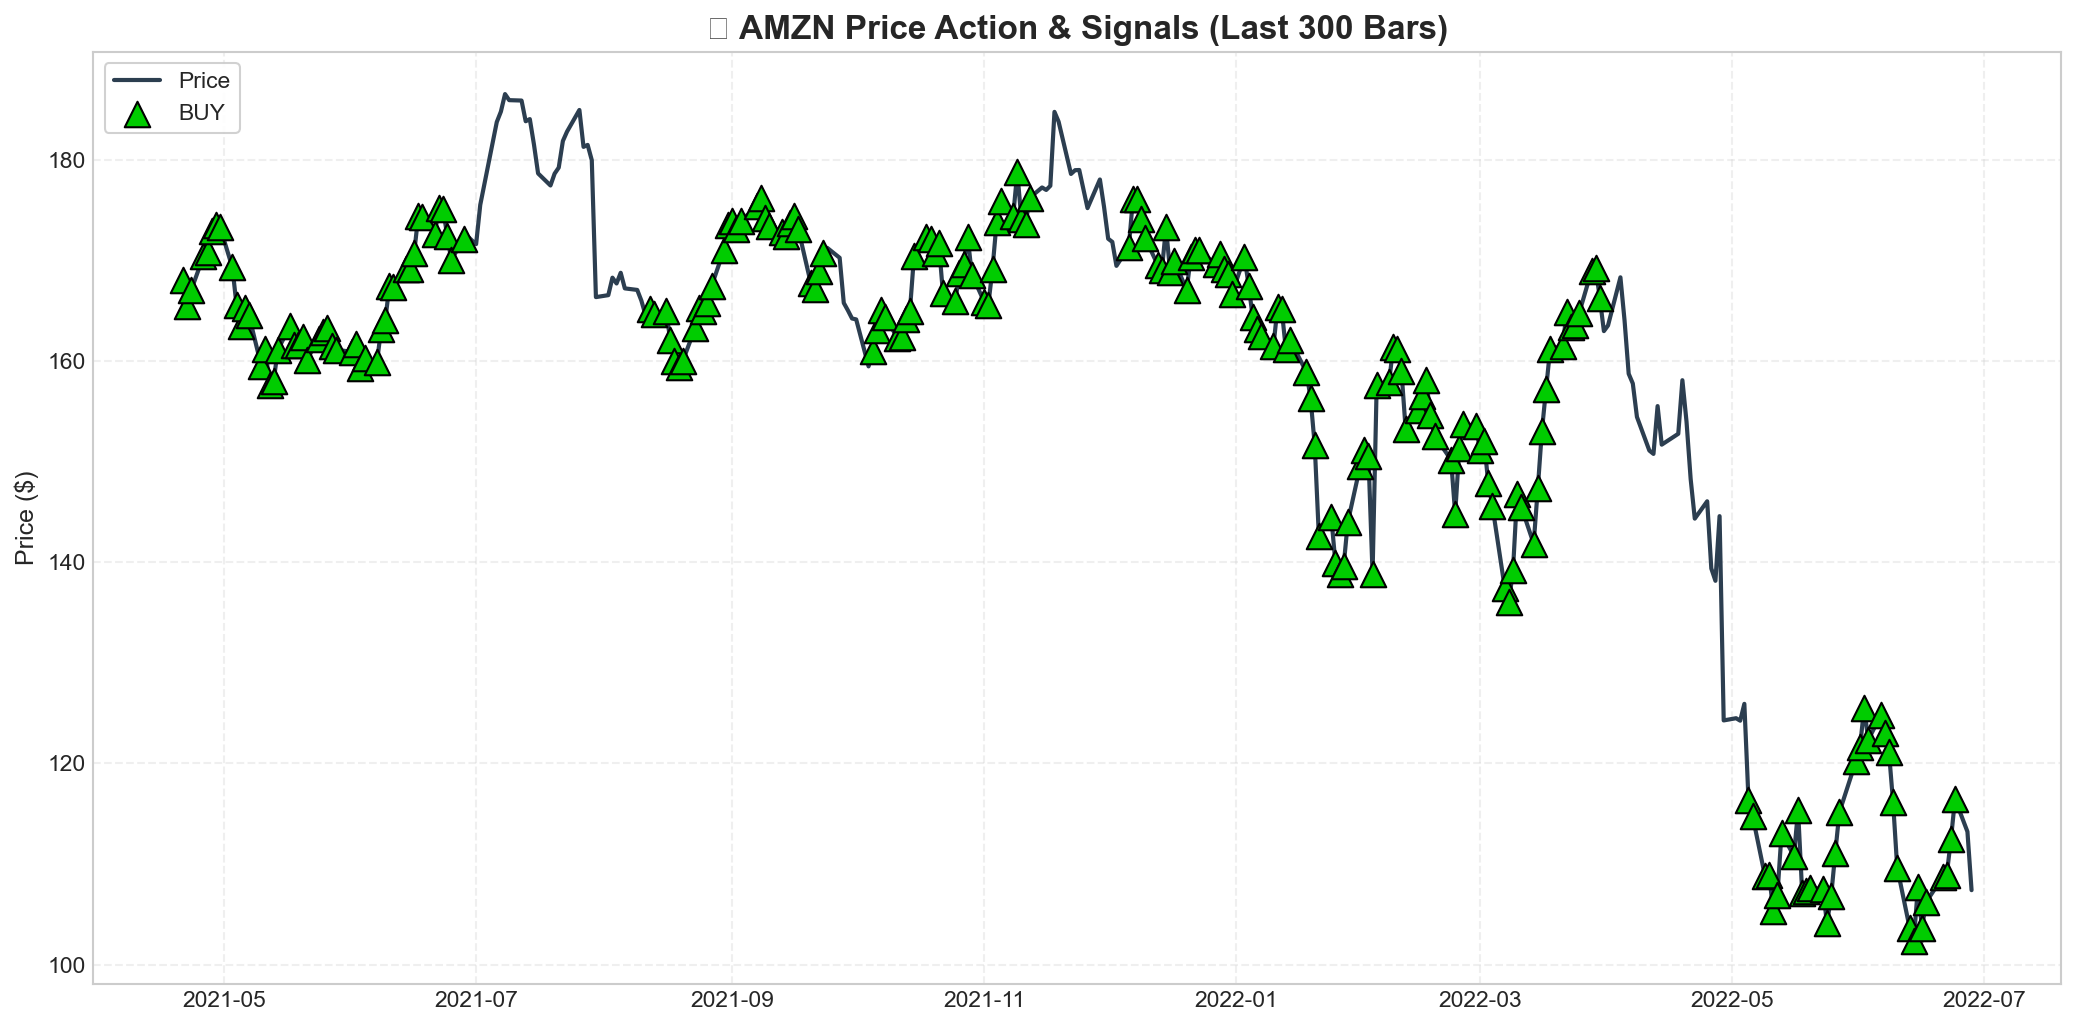

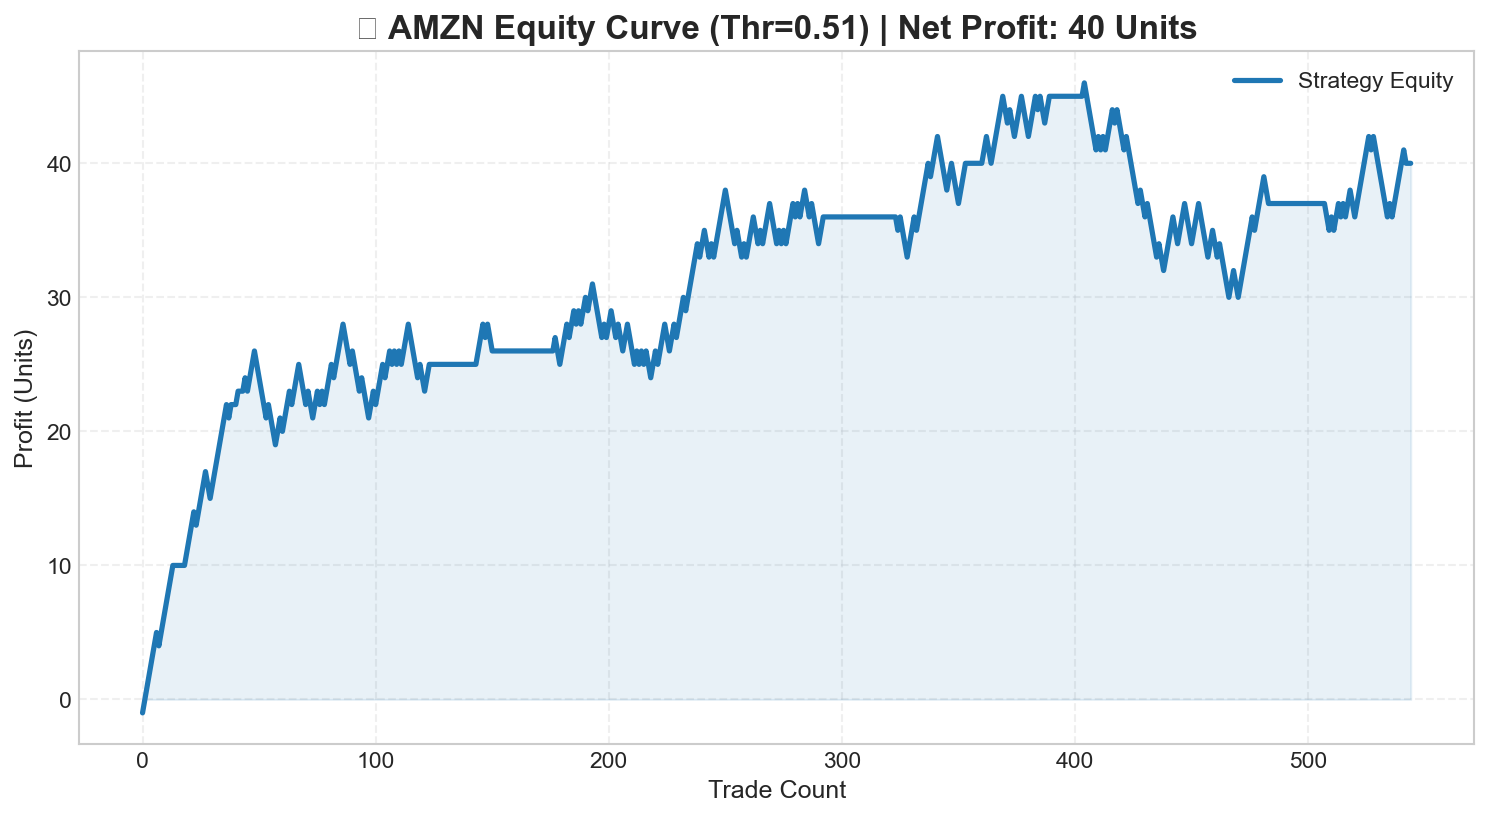

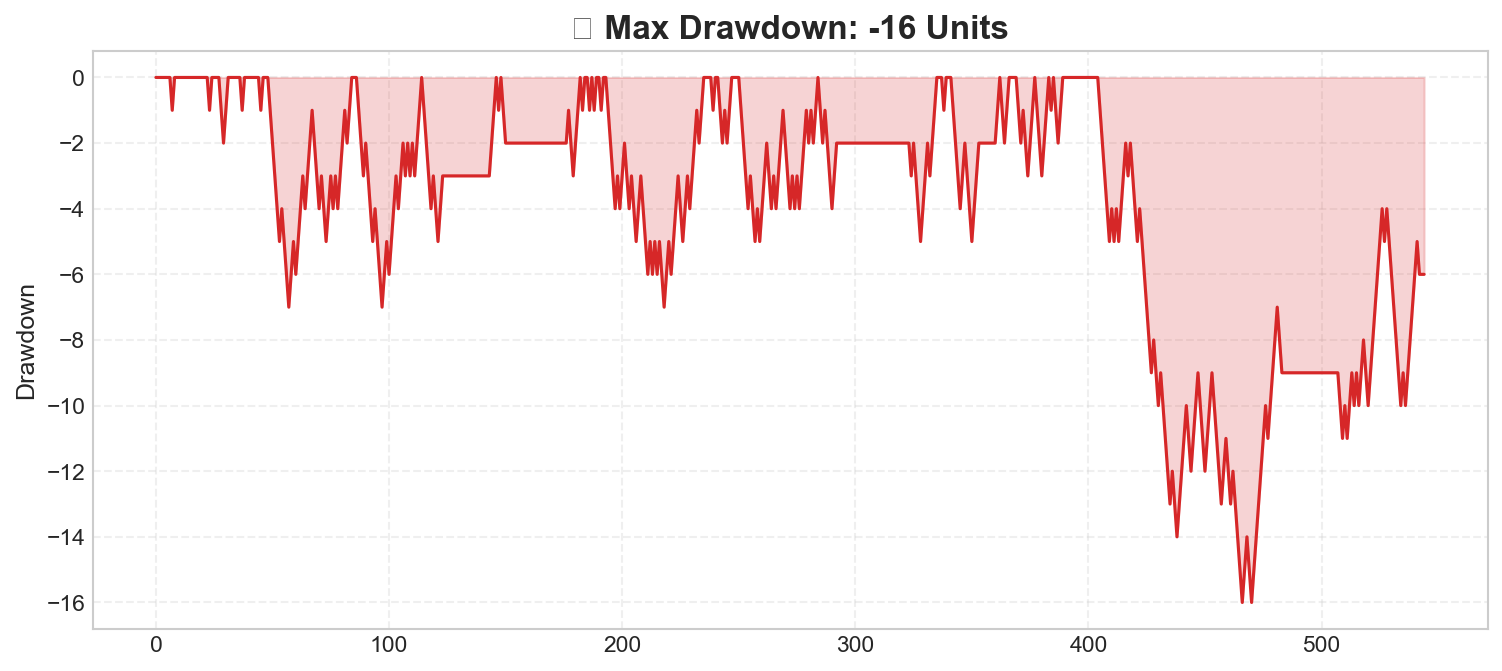


    ╔═══════════════════════════════════════════╗
    ║   📊 AMZN PERFORMANCE REPORT (Thr 0.51)   ║
    ╠═══════════════════════════════════════════╣
    ║  Total Trades:      412                   ║
    ║  Win Rate:          54.85%               ║
    ║  Net Profit:        40     units         ║
    ║  Profit Factor:     1.22                ║
    ║  Sharpe Ratio:      0.098               ║
    ║  SQN Score:         1.98                ║
    ║  Max Drawdown:      -16    units         ║
    ╚═══════════════════════════════════════════╝
    

🎨 GENERATING REPORT FOR AMZN (Thr=0.52)...



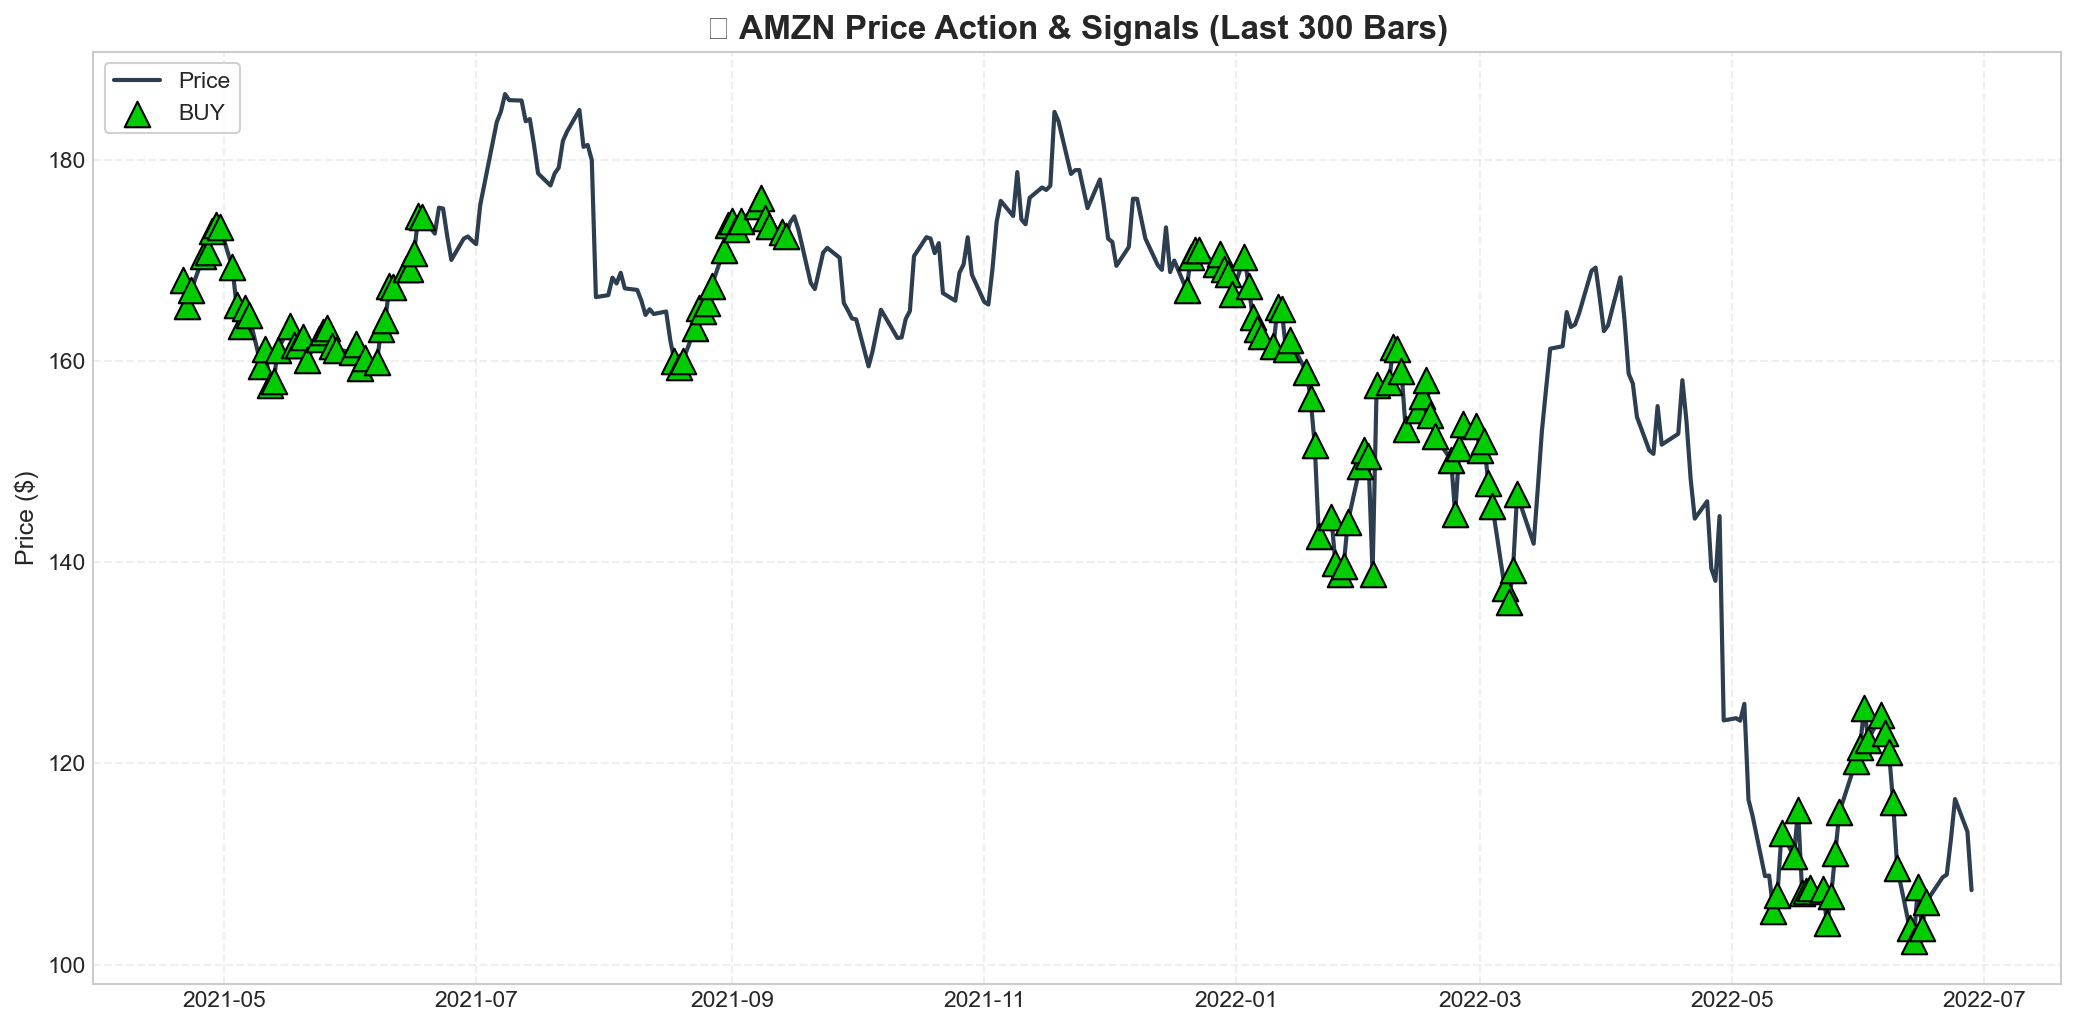

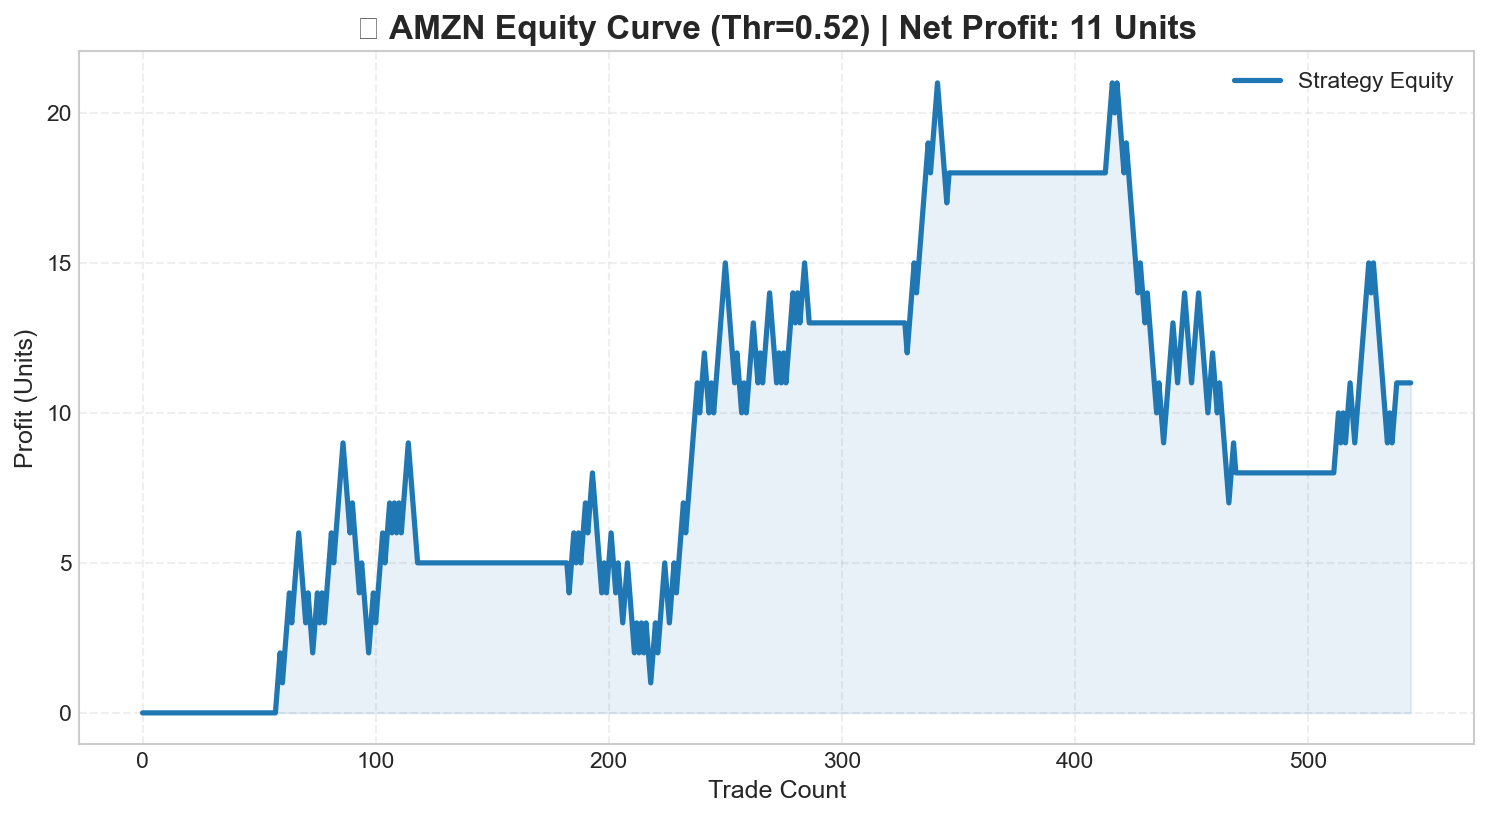

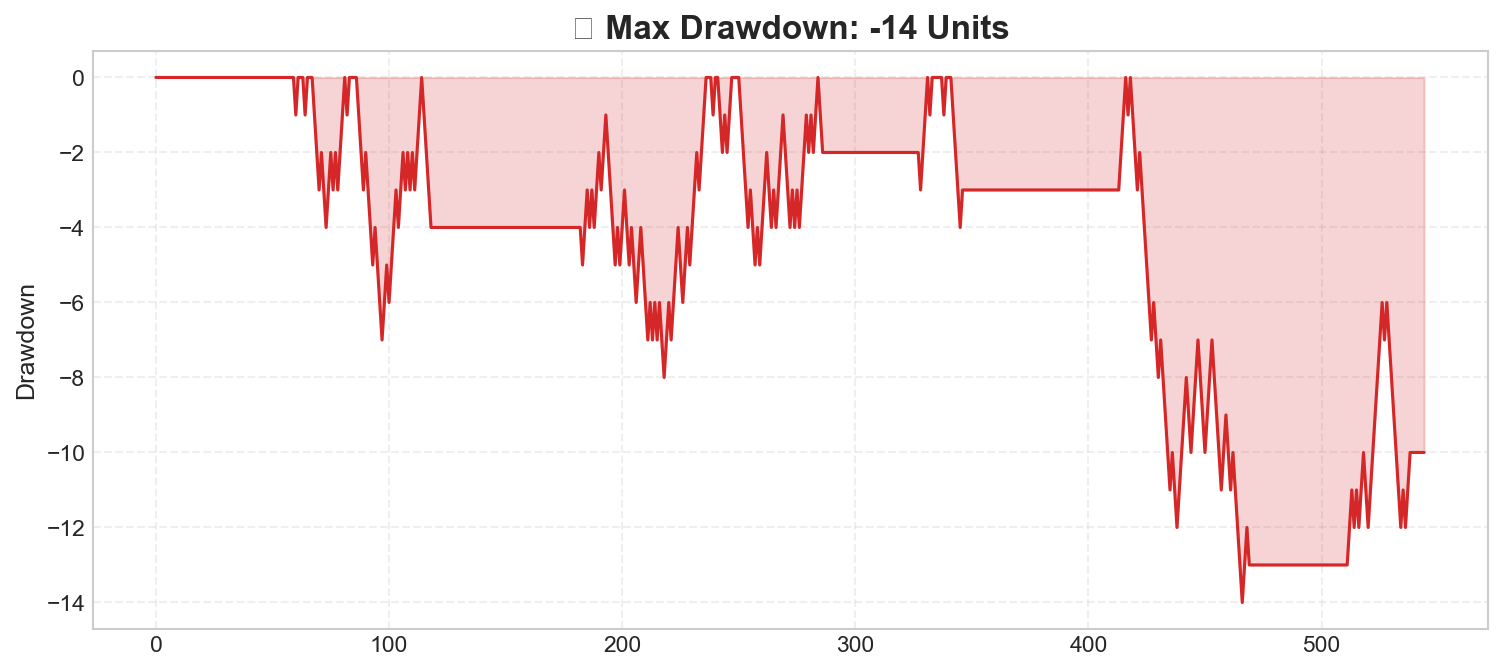


    ╔═══════════════════════════════════════════╗
    ║   📊 AMZN PERFORMANCE REPORT (Thr 0.52)   ║
    ╠═══════════════════════════════════════════╣
    ║  Total Trades:      267                   ║
    ║  Win Rate:          52.06%               ║
    ║  Net Profit:        11     units         ║
    ║  Profit Factor:     1.09                ║
    ║  Sharpe Ratio:      0.041               ║
    ║  SQN Score:         0.67                ║
    ║  Max Drawdown:      -14    units         ║
    ╚═══════════════════════════════════════════╝
    

🎨 GENERATING REPORT FOR AMZN (Thr=0.53)...



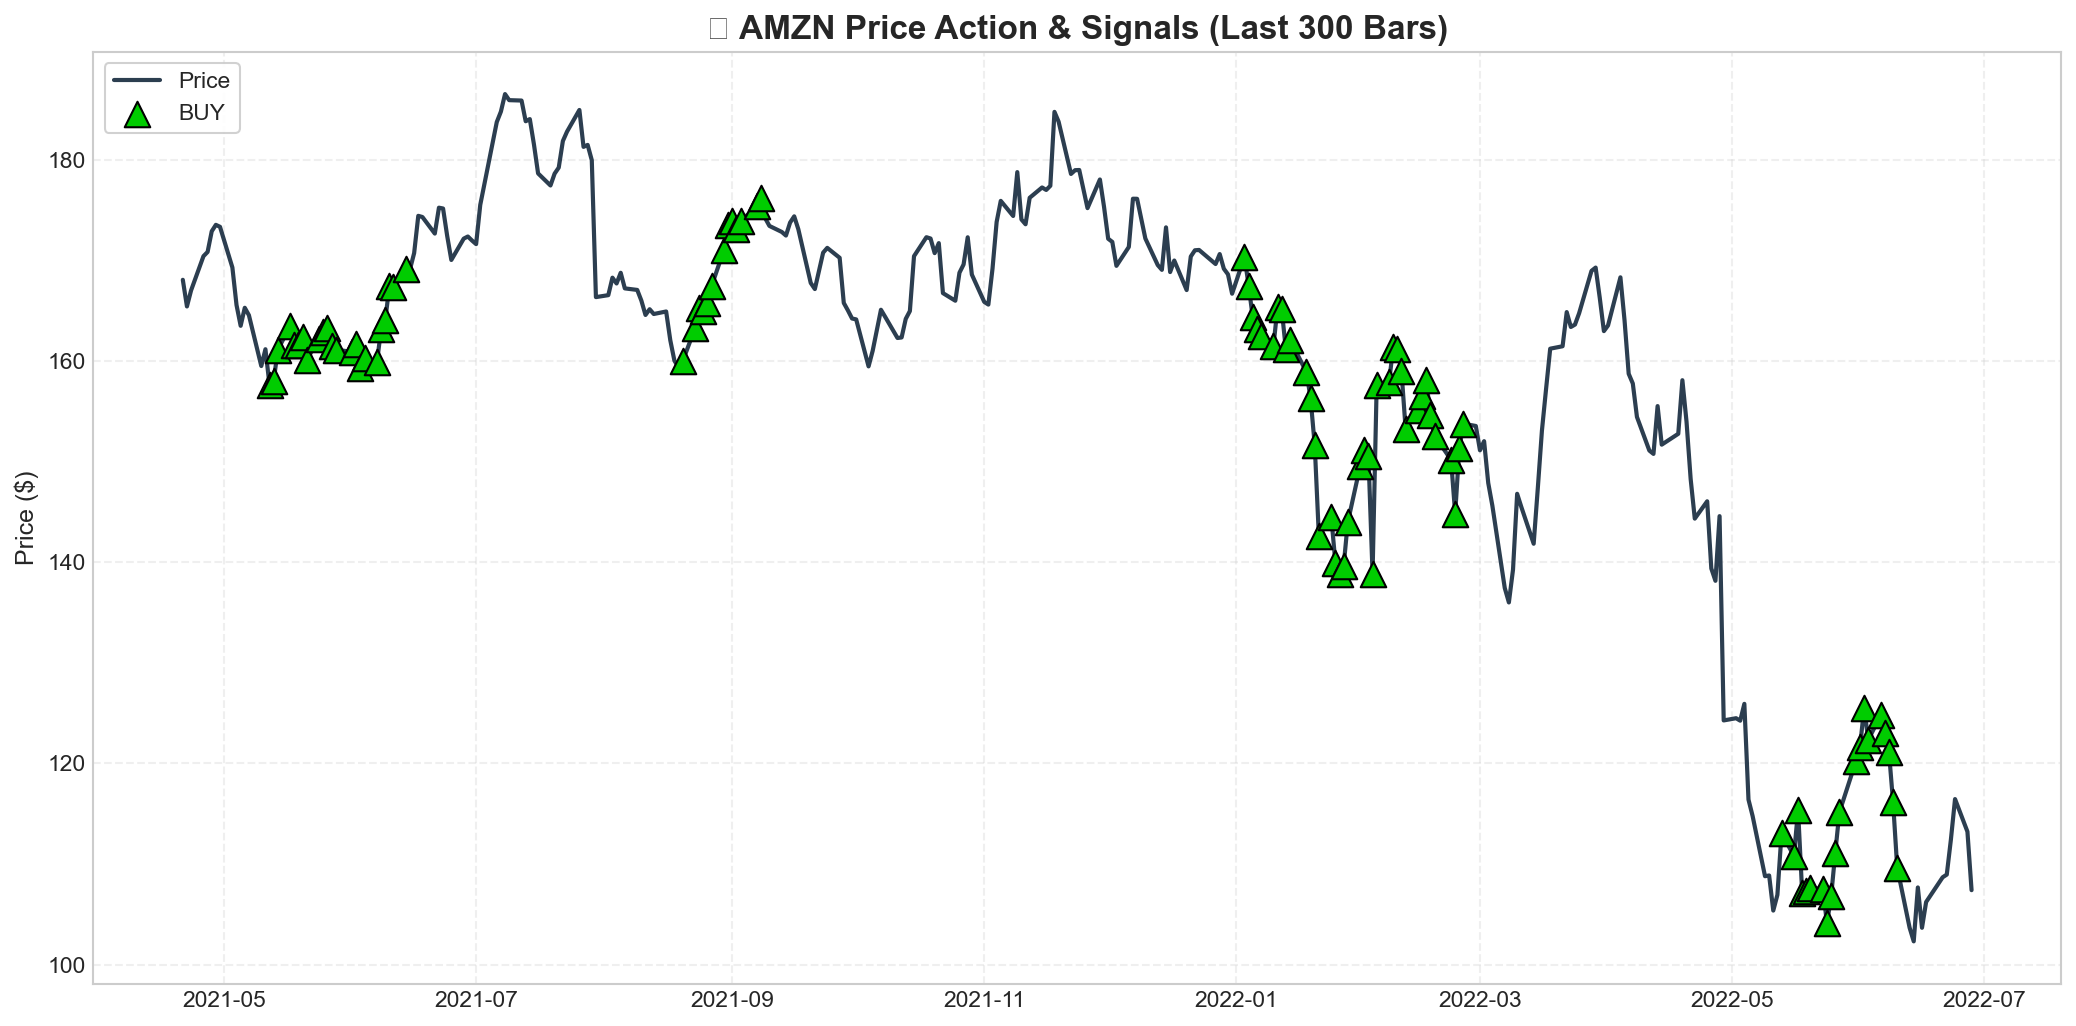

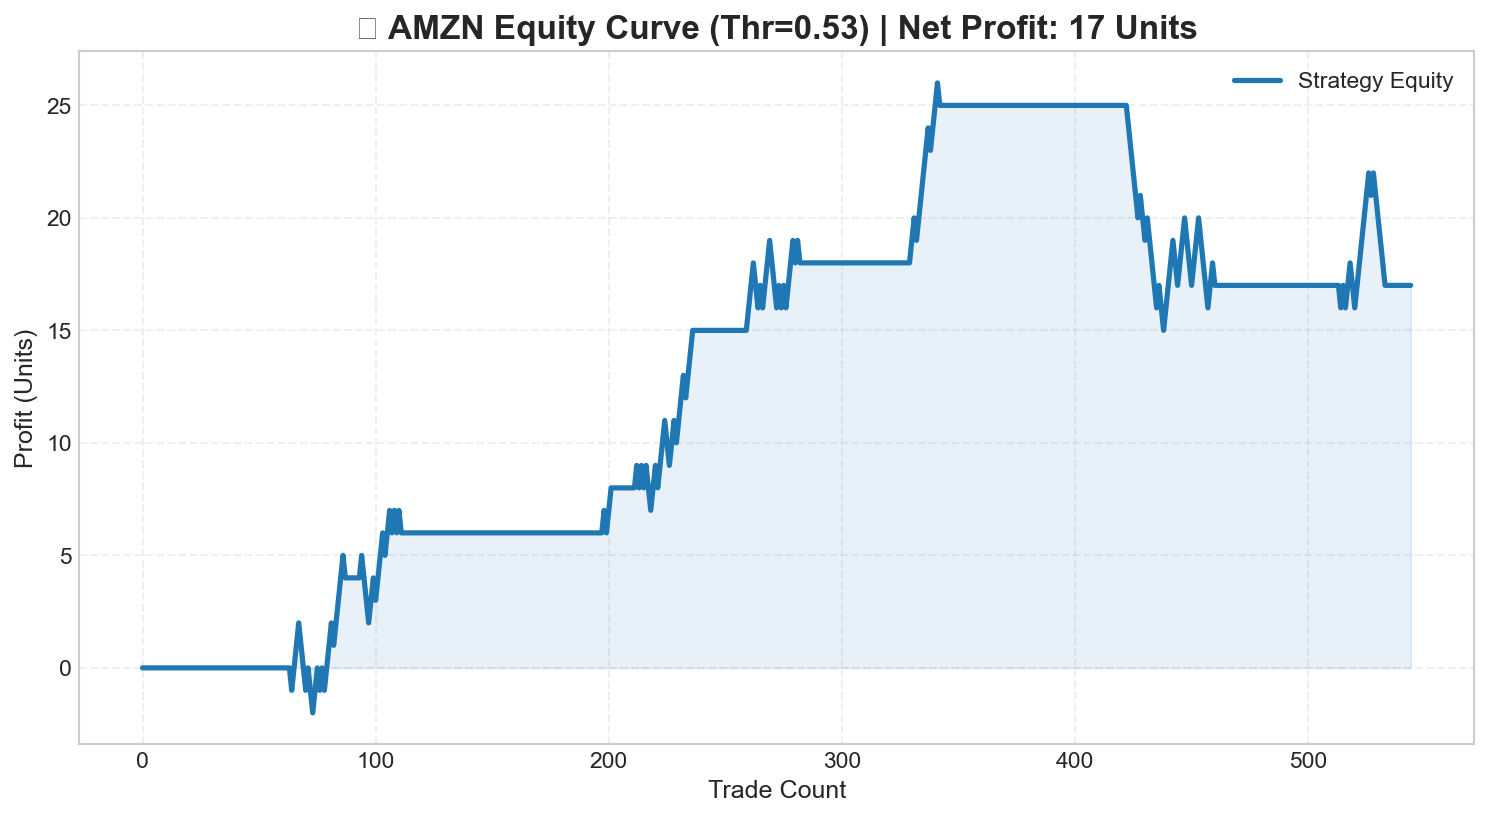

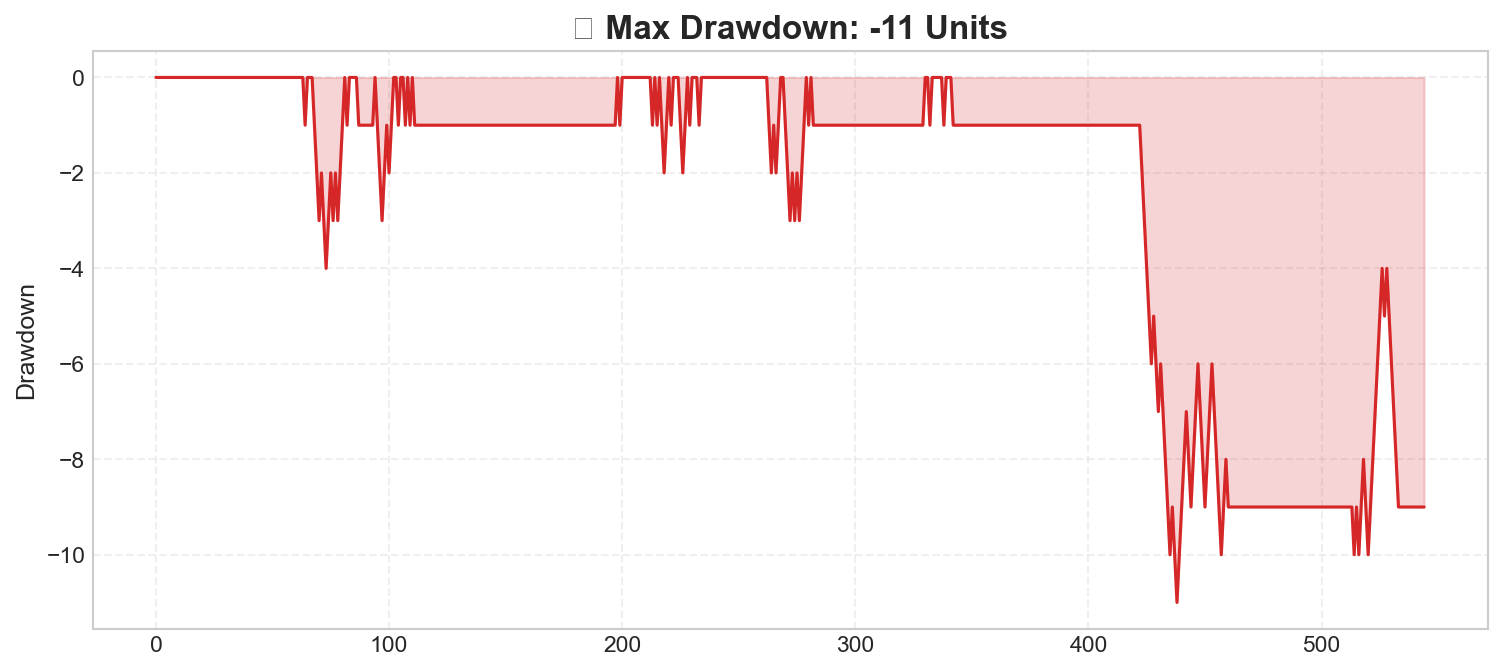


    ╔═══════════════════════════════════════════╗
    ║   📊 AMZN PERFORMANCE REPORT (Thr 0.53)   ║
    ╠═══════════════════════════════════════════╣
    ║  Total Trades:      165                   ║
    ║  Win Rate:          55.15%               ║
    ║  Net Profit:        17     units         ║
    ║  Profit Factor:     1.23                ║
    ║  Sharpe Ratio:      0.104               ║
    ║  SQN Score:         1.33                ║
    ║  Max Drawdown:      -11    units         ║
    ╚═══════════════════════════════════════════╝
    

🎨 GENERATING REPORT FOR AMZN (Thr=0.54)...



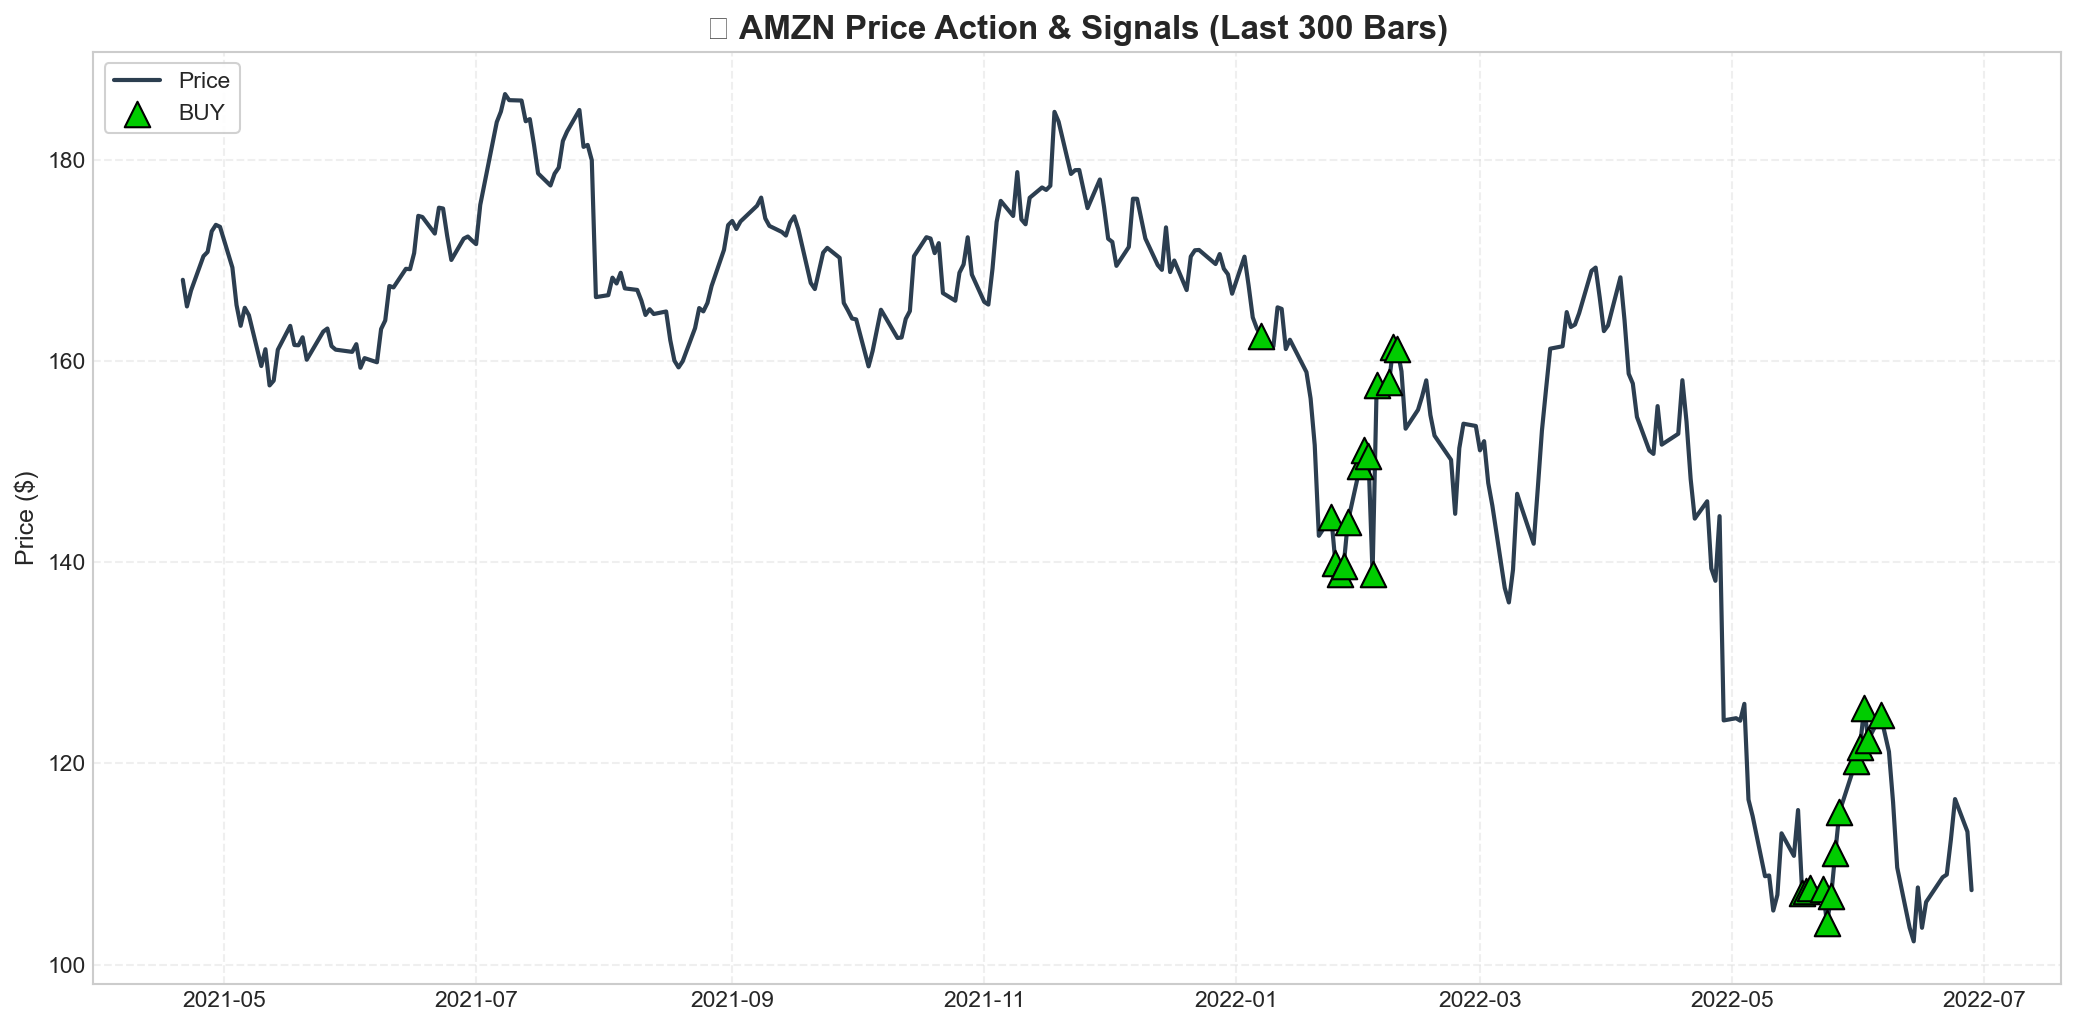

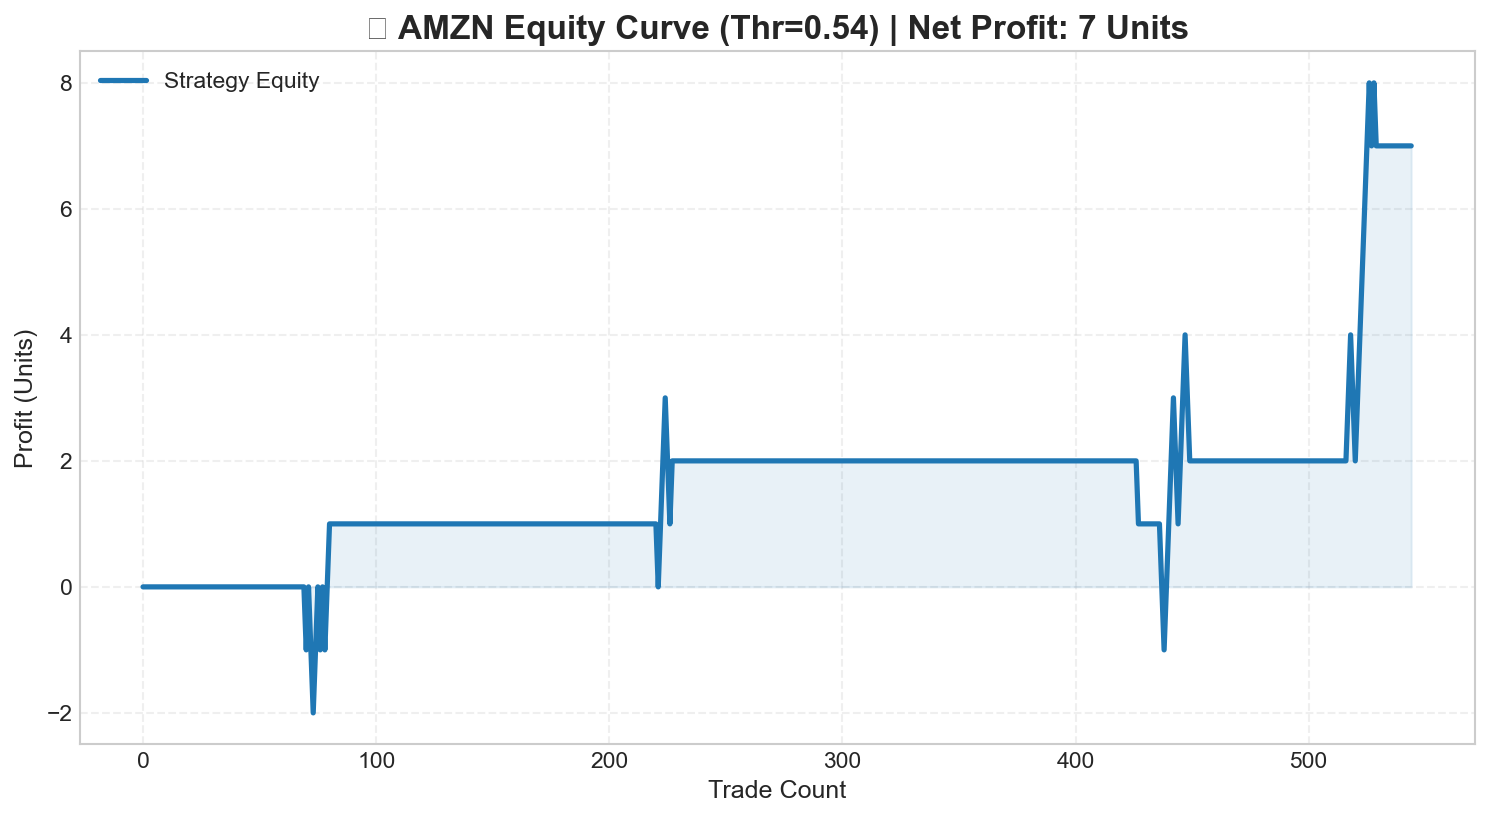

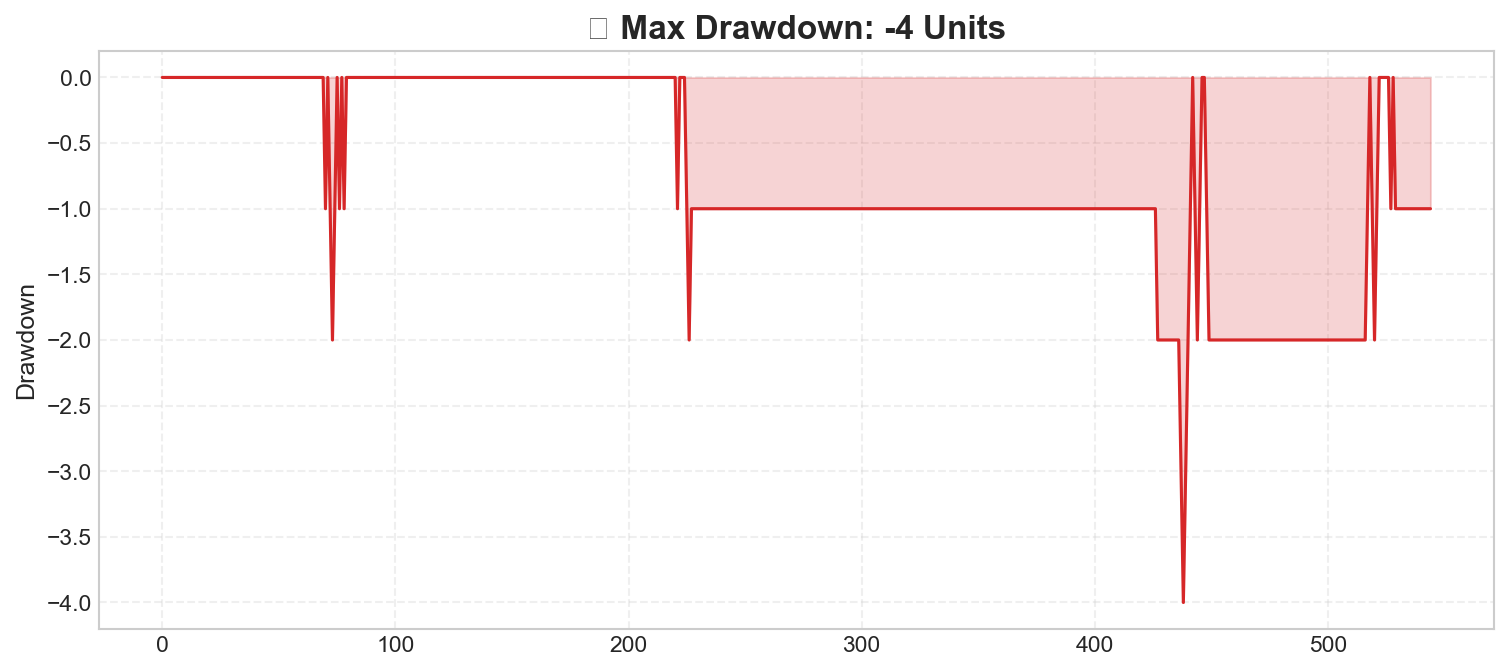


    ╔═══════════════════════════════════════════╗
    ║   📊 AMZN PERFORMANCE REPORT (Thr 0.54)   ║
    ╠═══════════════════════════════════════════╣
    ║  Total Trades:      45                    ║
    ║  Win Rate:          57.78%               ║
    ║  Net Profit:        7      units         ║
    ║  Profit Factor:     1.37                ║
    ║  Sharpe Ratio:      0.157               ║
    ║  SQN Score:         1.06                ║
    ║  Max Drawdown:      -4     units         ║
    ╚═══════════════════════════════════════════╝
    
⚠️ Skipping 0.55: Too few trades (6)
⚠️ Skipping 0.56: Too few trades (0)
⚠️ Skipping 0.57: Too few trades (0)
⚠️ Skipping 0.58: Too few trades (0)
⚠️ Skipping 0.59: Too few trades (0)
⚠️ Skipping 0.6: Too few trades (0)


In [6]:
"""
🎯 SINGLE ASSET DEEP DIVE: AAPL
===============================
Target: AAPL_fundamentals_test.csv
Model:  model_ep008_val53.05_hc56.21.pt
Output: HD Charts & Institutional Metrics
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# Set light theme for professional reporting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'figure.figsize': (14, 8),
    'axes.facecolor': '#ffffff',
    'figure.facecolor': '#ffffff',
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

# ══════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ══════════════════════════════════════════════════════════════
class Config:
    # Path to your data folder (Adjust if needed)
    DATA_DIR = "US Stock Market Data/fundamentals"
    LOAD_DIR = "cnn_patch_models_v3"
    MODEL_NAME = "model_ep008_val53.05_hc56.21.pt"

    # Target Asset
    TARGET_TICKER = "AMZN"

    # Model Params (Must match training)
    SEQ_LEN = 30; PATCH_LEN = 6; STRIDE = 3; NORM_WINDOW = 60
    D_MODEL = 24; N_HEADS = 4; N_LAYERS = 2; DROPOUT = 0.25; D_FUSE = 48
    BATCH_SIZE = 64
    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

cfg = Config()
cfg.N_PATCHES = (cfg.SEQ_LEN - cfg.PATCH_LEN) // cfg.STRIDE + 1
MODEL_PATH = os.path.join(cfg.LOAD_DIR, cfg.MODEL_NAME)

print(f"🎯 ANALYZING: {cfg.TARGET_TICKER}")
print(f"🔌 DEVICE: {cfg.DEVICE}")

# ══════════════════════════════════════════════════════════════
# 2. MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════
class LightPatchTST(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.n_ch, self.patch_len, self.stride = n_ch, patch_len, stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.d_model = d_model
        self.norm = nn.BatchNorm1d(n_ch)
        self.patch_proj = nn.Sequential(nn.Linear(patch_len, d_model), nn.GELU(), nn.LayerNorm(d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*2, dropout, 'gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers)
        self.agg = nn.Sequential(nn.Linear(n_ch * d_model, d_model), nn.GELU(), nn.Dropout(dropout))
        self.out_dim = d_model

    def forward(self, x):
        B, L, C = x.shape
        x = self.norm(x.transpose(1, 2))
        p = x.unfold(2, self.patch_len, self.stride).reshape(B * C, self.n_patches, self.patch_len)
        p = self.patch_proj(p) + self.pos_embed
        p = self.transformer(p)
        return self.agg(p.mean(dim=1).reshape(B, C * self.d_model))

class LightCNN(nn.Module):
    def __init__(self, n_ch, d_out, dropout):
        super().__init__()
        h = 24
        self.conv = nn.Sequential(nn.Conv1d(n_ch, h, 3, padding=1), nn.BatchNorm1d(h), nn.GELU(),
                                  nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(h, d_out); self.out_dim = d_out
    def forward(self, x): return self.proj(self.conv(x.transpose(1, 2)).mean(dim=2))

class LightGatedFusion(nn.Module):
    def __init__(self, d1, d2, d_out):
        super().__init__()
        self.proj, self.gate = nn.Linear(d1+d2, d_out), nn.Linear(d1+d2, d_out)
        self.norm = nn.LayerNorm(d_out)
    def forward(self, x1, x2):
        c = torch.cat([x1, x2], dim=-1)
        return self.norm(torch.sigmoid(self.gate(c)) * self.proj(c))

class HybridModelV3(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout, d_fuse):
        super().__init__()
        self.cnn = LightCNN(n_ch, d_fuse, dropout)
        self.tst = LightPatchTST(n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout)
        self.fusion = LightGatedFusion(self.cnn.out_dim, self.tst.out_dim, d_fuse)
        self.head = nn.Sequential(nn.Linear(d_fuse, d_fuse), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_fuse, 2))
        self.temperature = nn.Parameter(torch.tensor(1.5))
    def forward(self, x):
        logits = self.head(self.fusion(self.cnn(x), self.tst(x)))
        probs = F.softmax(logits / self.temperature, dim=-1)
        return logits, probs.max(dim=-1).values

# ══════════════════════════════════════════════════════════════
# 3. DATA LOADER (SINGLE ASSET)
# ══════════════════════════════════════════════════════════════
def rolling_normalize(data, window):
    res = np.zeros_like(data)
    for i in range(len(data)):
        s = max(0, i - window)
        wd = data[s:i+1]
        if len(wd)>5: res[i] = (data[i] - wd.mean(0)) / (wd.std(0) + 1e-8)
    return np.clip(res, -5, 5)

def create_features(df):
    df = df.copy()
    for w in [1, 5, 10, 20]: df[f'ret_{w}'] = df['close'].pct_change(w)
    df['vol_5'], df['vol_20'] = df['ret_1'].rolling(5).std(), df['ret_1'].rolling(20).std()
    for w in [10, 20]: df[f'trend_{w}'] = (df['close'] - df['close'].rolling(w).mean()) / (df['close'].rolling(w).mean() + 1e-10)
    delta = df['close'].diff()
    gain = delta.where(delta>0, 0).rolling(14).mean(); loss = (-delta.where(delta<0, 0)).rolling(14).mean()
    df['rsi'] = 100 - 100/(1 + gain/(loss+1e-10))
    fund_cols = ['pe_ratio', 'pb_ratio', 'ps_ratio', 'return_on_equity', 'return_on_assets', 'debt_to_equity', 'current_ratio']
    for col in fund_cols:
        if col not in df: df[col] = 0.0
        if col in ['pe_ratio', 'pb_ratio', 'ps_ratio']: df[f'{col}_z'] = (df[col]-df[col].rolling(20).mean())/(df[col].rolling(20).std()+1e-10)
        if col in ['return_on_equity', 'return_on_assets']: df[f'{col}_chg'] = df[col].diff()
    df['vol_change'] = df['volume'].pct_change()
    return df

def load_specific_asset(folder, ticker):
    # Construct filename based on your structure: Ticker_fundamentals_test.csv
    filename = f"{ticker}_fundamentals_test.csv"
    path = os.path.join(folder, "test", filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found: {path}")

    print(f"📂 Loading: {path}")
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()

    # Save Prices & Dates
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        dates = df['date'].values
    else:
        dates = np.arange(len(df))

    raw_prices = df['close'].values

    # Process
    df = create_features(df)
    exclude = ['date', 'close', 'target', 'open', 'high', 'low', 'volume']
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64', 'float32']]

    df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # Pad to 45 features
    raw_feats = df[cols].values
    if raw_feats.shape[1] < 45:
        padding = np.zeros((raw_feats.shape[0], 45 - raw_feats.shape[1]))
        raw_feats = np.hstack([raw_feats, padding])
    elif raw_feats.shape[1] > 45: raw_feats = raw_feats[:, :45]

    norm_feats = rolling_normalize(raw_feats, cfg.NORM_WINDOW)
    targets = df['target'].values

    # Sequence Gen
    X, y, p, d = [], [], [], []
    valid_indices = df.index

    for i in range(cfg.NORM_WINDOW, len(norm_feats) - cfg.SEQ_LEN):
        X.append(norm_feats[i:i+cfg.SEQ_LEN])
        y.append(targets[i+cfg.SEQ_LEN-1])
        idx = valid_indices[i+cfg.SEQ_LEN-1]
        p.append(raw_prices[idx])
        d.append(dates[idx])

    return np.array(X, dtype=np.float32), np.array(y), np.array(p), np.array(d)

# ══════════════════════════════════════════════════════════════
# 4. HD PLOTTING & METRICS
# ══════════════════════════════════════════════════════════════
def generate_asset_report(res, prices, dates, ticker, thr):
    print(f"\n🎨 GENERATING REPORT FOR {ticker} (Thr={thr})...\n")

    # --- 1. PRICE CHART (ZOOMED) ---
    plt.figure(figsize=(14, 7))
    trade_idxs = np.where(res['signals'] != 0)[0]

    if len(trade_idxs) > 0:
        # Find active window (last 300 bars with trades)
        end_idx = len(prices)
        start_idx = max(0, end_idx - 300)

        sub_price = prices[start_idx:end_idx]
        sub_dates = dates[start_idx:end_idx]
        sub_signals = res['signals'][start_idx:end_idx]

        # Plot Line
        plt.plot(sub_dates, sub_price, color='#2c3e50', linewidth=2, label='Price')

        # Markers
        buys = np.where(sub_signals == 1)[0]
        sells = np.where(sub_signals == -1)[0]

        if len(buys) > 0:
            plt.scatter(sub_dates[buys], sub_price[buys], marker='^', color='#00cc00', s=150,
                        edgecolors='black', linewidth=1, label='BUY', zorder=5)
        if len(sells) > 0:
            plt.scatter(sub_dates[sells], sub_price[sells], marker='v', color='#ff0000', s=150,
                        edgecolors='black', linewidth=1, label='SELL', zorder=5)

        plt.title(f"🔍 {ticker} Price Action & Signals (Last 300 Bars)", fontsize=16)
        plt.ylabel("Price ($)", fontsize=12)
        plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    else:
        plt.text(0.5, 0.5, "No Trades", ha='center', fontsize=20)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 2. EQUITY CURVE ---
    plt.figure(figsize=(12, 6))
    plt.plot(res['cum_pnl'], color='#1f77b4', linewidth=2.5, label='Strategy Equity')
    plt.fill_between(range(len(res['cum_pnl'])), 0, res['cum_pnl'], color='#1f77b4', alpha=0.1)
    plt.title(f"💰 {ticker} Equity Curve (Thr={thr}) | Net Profit: {int(res['final_pnl'])} Units", fontsize=16)
    plt.ylabel("Profit (Units)", fontsize=12)
    plt.xlabel("Trade Count", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 3. DRAWDOWN ---
    plt.figure(figsize=(12, 5))
    plt.plot(res['drawdown'], color='#d62728', linewidth=1.5)
    plt.fill_between(range(len(res['drawdown'])), res['drawdown'], 0, color='#d62728', alpha=0.2)
    plt.title(f"📉 Max Drawdown: {res['max_dd']:.0f} Units", fontsize=16)
    plt.ylabel("Drawdown", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 4. TEAR SHEET ---
    print(f"""
    ╔═══════════════════════════════════════════╗
    ║   📊 {ticker} PERFORMANCE REPORT (Thr {thr})   ║
    ╠═══════════════════════════════════════════╣
    ║  Total Trades:      {res['n_trades']:<6}                ║
    ║  Win Rate:          {res['win_rate']:.2f}%               ║
    ║  Net Profit:        {int(res['final_pnl']):<6} units         ║
    ║  Profit Factor:     {res['profit_factor']:.2f}                ║
    ║  Sharpe Ratio:      {res['sharpe']:.3f}               ║
    ║  SQN Score:         {res['sqn']:.2f}                ║
    ║  Max Drawdown:      {int(res['max_dd']):<6} units         ║
    ╚═══════════════════════════════════════════╝
    """)

# ══════════════════════════════════════════════════════════════
# 5. EXECUTION
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    # 1. Load Data
    try:
        X, y, prices, dates = load_specific_asset(cfg.DATA_DIR, cfg.TARGET_TICKER)
        print(f"✅ Loaded {len(X)} samples for {cfg.TARGET_TICKER}")
    except FileNotFoundError as e:
        print(e)
        exit()

    # 2. Load Model
    model = HybridModelV3(45, cfg.SEQ_LEN, cfg.PATCH_LEN, cfg.STRIDE, cfg.D_MODEL, cfg.N_HEADS, cfg.N_LAYERS, cfg.DROPOUT, cfg.D_FUSE).to(cfg.DEVICE)
    ckpt = torch.load(MODEL_PATH, map_location=cfg.DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # 3. Inference
    dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
    P, T, C = [], [], []
    with torch.no_grad():
        for bx, by in loader:
            logits, conf = model(bx.to(cfg.DEVICE))
            P.extend(logits.argmax(1).cpu().numpy())
            T.extend(by.numpy())
            C.extend(conf.cpu().numpy())
    P, T, C = np.array(P), np.array(T), np.array(C)

    # 4. Analyze Thresholds > 0.51
    thresholds = [0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.60]

    for thr in thresholds:
        mask = C > thr
        n_trades = mask.sum()

        if n_trades < 10:
            print(f"⚠️ Skipping {thr}: Too few trades ({n_trades})")
            continue

        signals = np.zeros(len(P))
        signals[mask] = np.where(P[mask]==1, 1, -1)
        pnl = signals * np.where(T==1, 1, -1)
        cum_pnl = np.cumsum(pnl)

        wins = (pnl > 0).sum()
        win_rate = wins / n_trades * 100

        # Metrics
        avg_pnl = pnl[pnl!=0].mean()
        std_pnl = pnl[pnl!=0].std() + 1e-9
        sqn = np.sqrt(n_trades) * (avg_pnl / std_pnl)
        sharpe = avg_pnl / std_pnl
        drawdown = cum_pnl - np.maximum.accumulate(cum_pnl)
        gross_win = pnl[pnl>0].sum()
        gross_loss = abs(pnl[pnl<0].sum())
        pf = gross_win / gross_loss if gross_loss > 0 else 0

        res = {
            'n_trades': n_trades, 'win_rate': win_rate, 'final_pnl': cum_pnl[-1],
            'cum_pnl': cum_pnl, 'max_dd': drawdown.min(), 'sharpe': sharpe, 'sqn': sqn,
            'drawdown': drawdown, 'pnl_stream': pnl, 'signals': signals, 'profit_factor': pf
        }

        generate_asset_report(res, prices, dates, cfg.TARGET_TICKER, thr)

🚀 Starting Analysis for AMZN...
✅ Data Loaded: 545 samples
✅ Model Loaded Successfully

📊 RESULT THR: 0.51 | Trades: 410 | WR: 53.9% | Sharpe: 0.08


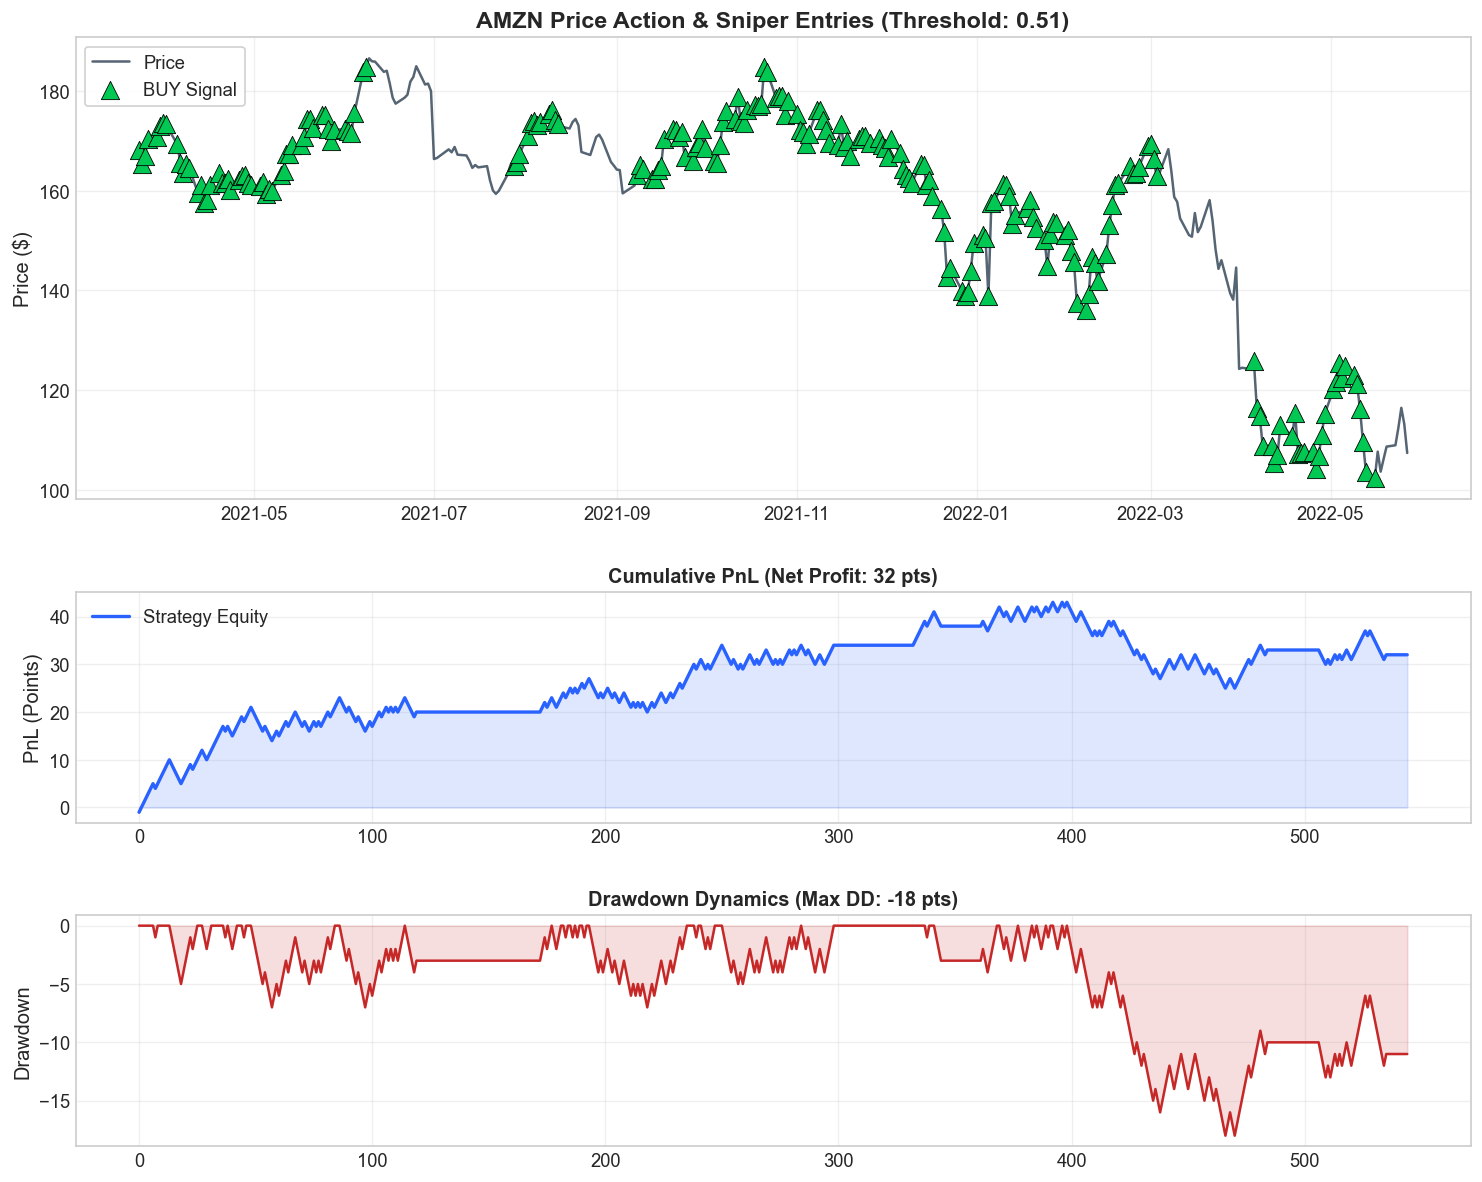


📊 RESULT THR: 0.52 | Trades: 205 | WR: 50.7% | Sharpe: 0.01


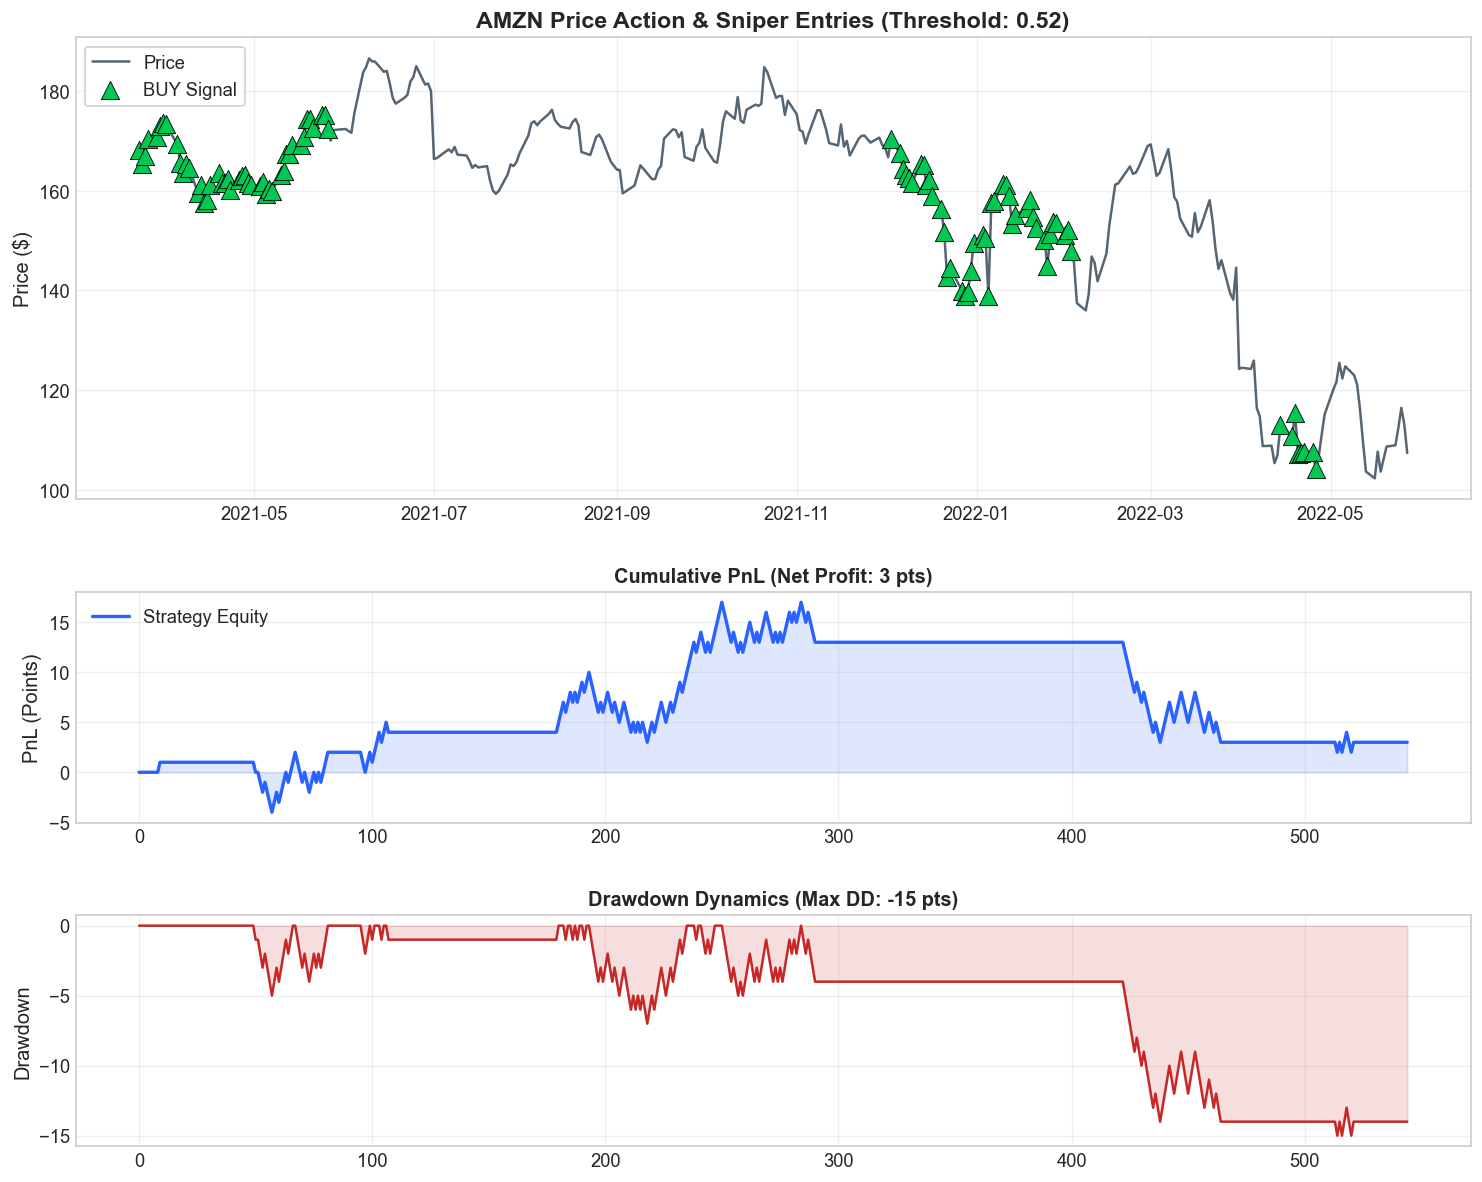


📊 RESULT THR: 0.53 | Trades: 79 | WR: 54.4% | Sharpe: 0.09


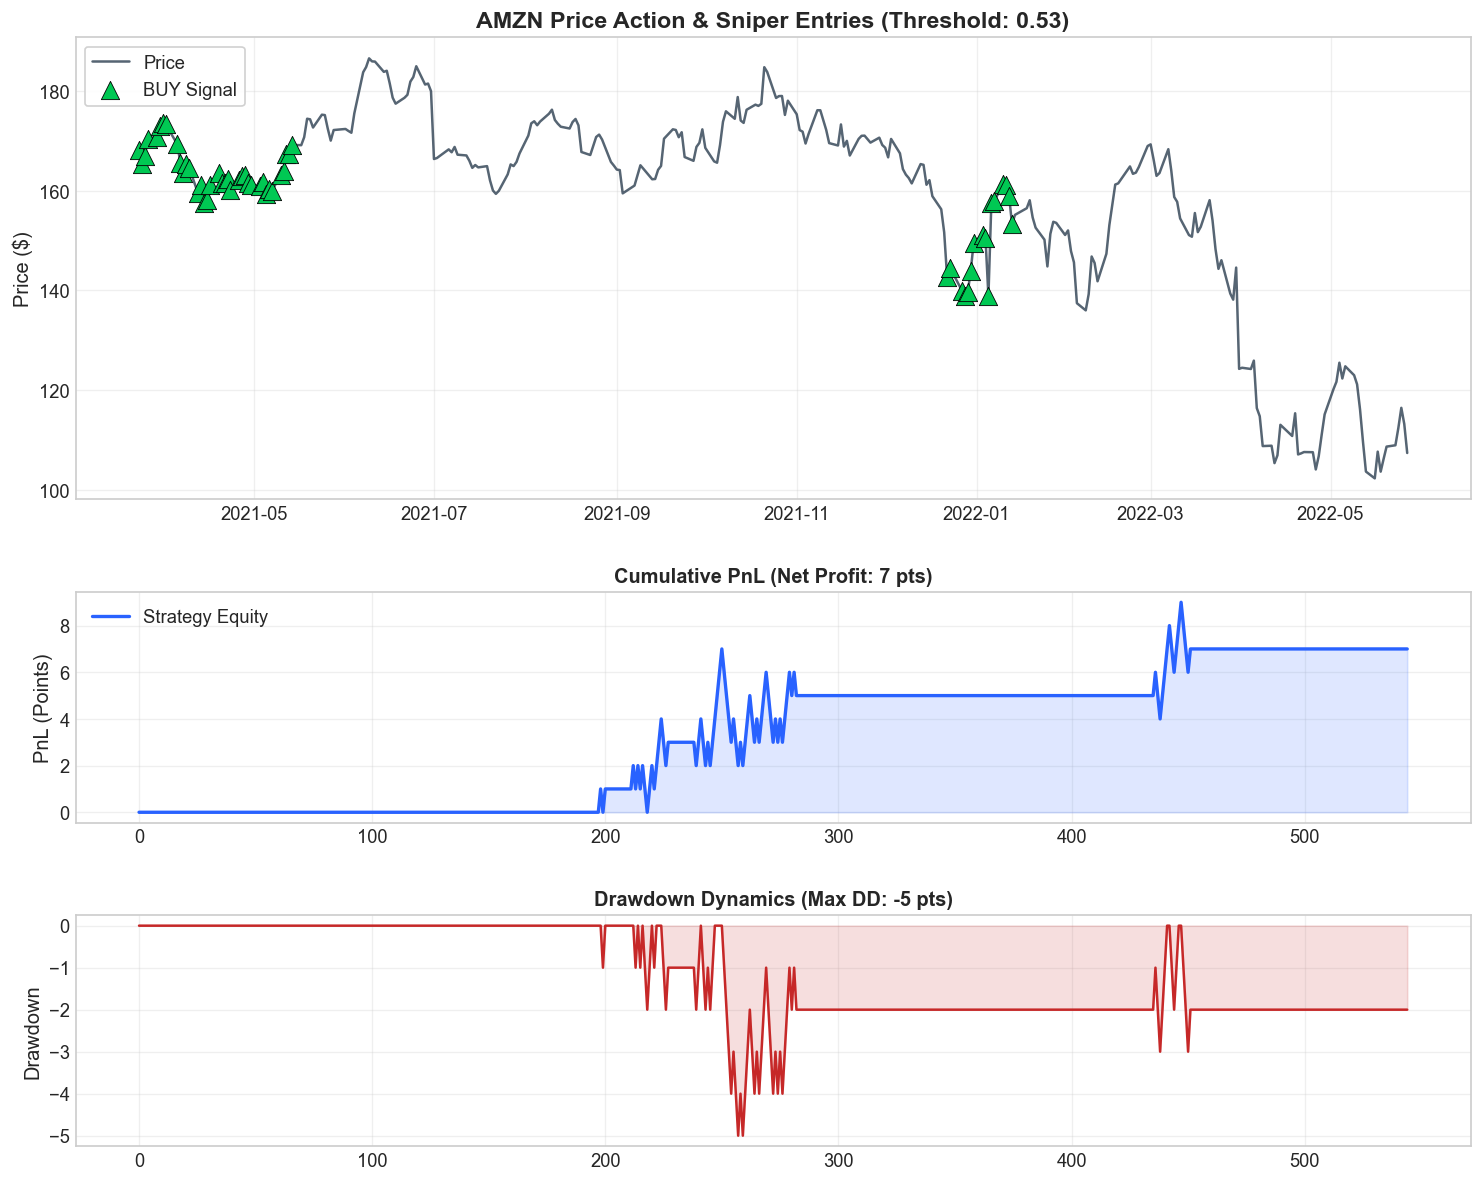

⚠️ Thr 0.54: Not enough trades (4.0)
⚠️ Thr 0.55: Not enough trades (0.0)
⚠️ Thr 0.56: Not enough trades (0.0)
⚠️ Thr 0.57: Not enough trades (0.0)
⚠️ Thr 0.58: Not enough trades (0.0)
⚠️ Thr 0.59: Not enough trades (0.0)
⚠️ Thr 0.6: Not enough trades (0.0)


In [6]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import warnings

# ══════════════════════════════════════════════════════════════
# 0. VISUALIZATION SETTINGS (Pro Style)
# ══════════════════════════════════════════════════════════════
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.weight': 'normal',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5
})

# Colors
COL_PRICE = '#2C3E50'  # Dark Blue Grey
COL_BUY   = '#00C853'  # Bright Green
COL_SELL  = '#D50000'  # Bright Red
COL_EQ    = '#2962FF'  # Royal Blue
COL_DD    = '#C62828'  # Dark Red

# ══════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ══════════════════════════════════════════════════════════════
class Config:
    DATA_DIR = "US Stock Market Data/fundamentals"
    LOAD_DIR = "cnn_patch_models_v3"
    MODEL_NAME = "model_ep008_val53.05_hc56.21.pt"
    TARGET_TICKER = "AMZN" # <--- TARGET ASSET

    # Model Hyperparams
    SEQ_LEN = 30; PATCH_LEN = 6; STRIDE = 3; NORM_WINDOW = 60
    D_MODEL = 24; N_HEADS = 4; N_LAYERS = 2; DROPOUT = 0.25; D_FUSE = 48
    BATCH_SIZE = 64
    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

cfg = Config()
cfg.N_PATCHES = (cfg.SEQ_LEN - cfg.PATCH_LEN) // cfg.STRIDE + 1
MODEL_PATH = os.path.join(cfg.LOAD_DIR, cfg.MODEL_NAME)

# ══════════════════════════════════════════════════════════════
# 2. MODEL DEFINITIONS (Must match training)
# ══════════════════════════════════════════════════════════════
class LightPatchTST(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.n_ch, self.patch_len, self.stride = n_ch, patch_len, stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.d_model = d_model
        self.norm = nn.BatchNorm1d(n_ch)
        self.patch_proj = nn.Sequential(nn.Linear(patch_len, d_model), nn.GELU(), nn.LayerNorm(d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*2, dropout, 'gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers)
        self.agg = nn.Sequential(nn.Linear(n_ch * d_model, d_model), nn.GELU(), nn.Dropout(dropout))
        self.out_dim = d_model

    def forward(self, x):
        B, L, C = x.shape
        x = self.norm(x.transpose(1, 2))
        p = x.unfold(2, self.patch_len, self.stride).reshape(B * C, self.n_patches, self.patch_len)
        p = self.patch_proj(p) + self.pos_embed
        p = self.transformer(p)
        return self.agg(p.mean(dim=1).reshape(B, C * self.d_model))

class LightCNN(nn.Module):
    def __init__(self, n_ch, d_out, dropout):
        super().__init__()
        h = 24
        self.conv = nn.Sequential(nn.Conv1d(n_ch, h, 3, padding=1), nn.BatchNorm1d(h), nn.GELU(),
                                  nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(h, d_out); self.out_dim = d_out
    def forward(self, x): return self.proj(self.conv(x.transpose(1, 2)).mean(dim=2))

class LightGatedFusion(nn.Module):
    def __init__(self, d1, d2, d_out):
        super().__init__()
        self.proj, self.gate = nn.Linear(d1+d2, d_out), nn.Linear(d1+d2, d_out)
        self.norm = nn.LayerNorm(d_out)
    def forward(self, x1, x2):
        c = torch.cat([x1, x2], dim=-1)
        return self.norm(torch.sigmoid(self.gate(c)) * self.proj(c))

class HybridModelV3(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout, d_fuse):
        super().__init__()
        self.cnn = LightCNN(n_ch, d_fuse, dropout)
        self.tst = LightPatchTST(n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout)
        self.fusion = LightGatedFusion(self.cnn.out_dim, self.tst.out_dim, d_fuse)
        self.head = nn.Sequential(nn.Linear(d_fuse, d_fuse), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_fuse, 2))
        self.temperature = nn.Parameter(torch.tensor(1.5))
    def forward(self, x):
        logits = self.head(self.fusion(self.cnn(x), self.tst(x)))
        probs = F.softmax(logits / self.temperature, dim=-1)
        return logits, probs.max(dim=-1).values

# ══════════════════════════════════════════════════════════════
# 3. HELPERS & LOADING
# ══════════════════════════════════════════════════════════════
def rolling_normalize(data, window):
    res = np.zeros_like(data)
    for i in range(len(data)):
        s = max(0, i - window)
        wd = data[s:i+1]
        if len(wd)>5: res[i] = (data[i] - wd.mean(0)) / (wd.std(0) + 1e-8)
    return np.clip(res, -5, 5)

def load_data(ticker):
    path = os.path.join(cfg.DATA_DIR, "test", f"{ticker}_fundamentals_test.csv")
    if not os.path.exists(path): raise FileNotFoundError(f"Missing: {path}")

    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        dates = df['date'].values
    else:
        dates = np.arange(len(df))

    # Feature Engineering (Compact)
    for w in [1, 5, 10, 20]: df[f'ret_{w}'] = df['close'].pct_change(w)
    df['vol_5'] = df['ret_1'].rolling(5).std()
    df = df.dropna().reset_index(drop=True)

    # Select Features
    exclude = ['date', 'close', 'target', 'open', 'high', 'low', 'volume']
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in [float, int, np.float64]]

    raw_feats = df[cols].values
    # Pad to 45
    if raw_feats.shape[1] < 45:
        raw_feats = np.hstack([raw_feats, np.zeros((len(raw_feats), 45-raw_feats.shape[1]))])
    raw_feats = raw_feats[:, :45]

    norm_feats = rolling_normalize(raw_feats, cfg.NORM_WINDOW)

    # Create Sequences
    X, y, p, d = [], [], [], []
    prices = df['close'].values
    targets = (df['close'].shift(-1) > df['close']).astype(int).values # 1=Up, 0=Down

    for i in range(cfg.NORM_WINDOW, len(norm_feats) - cfg.SEQ_LEN):
        X.append(norm_feats[i:i+cfg.SEQ_LEN])
        y.append(targets[i+cfg.SEQ_LEN-1])
        p.append(prices[i+cfg.SEQ_LEN-1])
        d.append(dates[i+cfg.SEQ_LEN-1])

    return np.array(X, dtype=np.float32), np.array(y), np.array(p), np.array(d)

# ══════════════════════════════════════════════════════════════
# 4. PLOTTING FUNCTION
# ══════════════════════════════════════════════════════════════
def plot_results(res, prices, dates, ticker, thr):
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1], hspace=0.3)

    # 1. PRICE ACTION & SIGNALS
    ax1 = fig.add_subplot(gs[0])

    # Plot last 300 points for clarity, or full if short
    zoom = 300
    if len(prices) > zoom:
        s_idx = len(prices) - zoom
        p_view = prices[s_idx:]
        d_view = dates[s_idx:]
        sig_view = res['signals'][s_idx:]
    else:
        p_view, d_view, sig_view = prices, dates, res['signals']

    ax1.plot(d_view, p_view, color=COL_PRICE, lw=1.5, label='Price', alpha=0.8)

    # Extract Buy/Sell indices relative to the view
    buy_mask = sig_view == 1
    sell_mask = sig_view == -1

    # PLOT BUYS (Green Up Triangle)
    if buy_mask.sum() > 0:
        ax1.scatter(d_view[buy_mask], p_view[buy_mask],
                   marker='^', color=COL_BUY, s=120, edgecolors='k', lw=0.5,
                   label='BUY Signal', zorder=5)

    # PLOT SELLS (Red Down Triangle)
    if sell_mask.sum() > 0:
        ax1.scatter(d_view[sell_mask], p_view[sell_mask],
                   marker='v', color=COL_SELL, s=120, edgecolors='k', lw=0.5,
                   label='SELL Signal', zorder=5)

    ax1.set_title(f"{ticker} Price Action & Sniper Entries (Threshold: {thr})", fontsize=14)
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.set_ylabel("Price ($)")

    # 2. EQUITY CURVE
    ax2 = fig.add_subplot(gs[1])
    pnl = res['cum_pnl']
    ax2.plot(pnl, color=COL_EQ, lw=2, label='Strategy Equity')
    ax2.fill_between(range(len(pnl)), 0, pnl, color=COL_EQ, alpha=0.15)
    ax2.set_title(f"Cumulative PnL (Net Profit: {pnl[-1]:.0f} pts)", fontsize=12)
    ax2.set_ylabel("PnL (Points)")
    ax2.legend(loc='upper left')

    # 3. DRAWDOWN
    ax3 = fig.add_subplot(gs[2])
    dd = res['drawdown']
    ax3.plot(dd, color=COL_DD, lw=1.5, label='Drawdown')
    ax3.fill_between(range(len(dd)), dd, 0, color=COL_DD, alpha=0.15)
    ax3.set_title(f"Drawdown Dynamics (Max DD: {res['max_dd']:.0f} pts)", fontsize=12)
    ax3.set_ylabel("Drawdown")

    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════════
# 5. MAIN EXECUTION
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print(f"🚀 Starting Analysis for {cfg.TARGET_TICKER}...")

    # Load
    X, y, prices, dates = load_data(cfg.TARGET_TICKER)
    print(f"✅ Data Loaded: {len(X)} samples")

    # Model
    model = HybridModelV3(45, cfg.SEQ_LEN, cfg.PATCH_LEN, cfg.STRIDE, cfg.D_MODEL, cfg.N_HEADS, cfg.N_LAYERS, cfg.DROPOUT, cfg.D_FUSE).to(cfg.DEVICE)
    try:
        ckpt = torch.load(MODEL_PATH, map_location=cfg.DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        print("✅ Model Loaded Successfully")
    except Exception as e:
        print(f"❌ Model Load Failed: {e}")
        exit()

    # Inference
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    dl = DataLoader(ds, batch_size=cfg.BATCH_SIZE)

    preds, targets_all, confs = [], [], []

    with torch.no_grad():
        for bx, by in dl:
            logits, c = model(bx.to(cfg.DEVICE))
            preds.extend(logits.argmax(1).cpu().numpy())
            targets_all.extend(by.numpy())
            confs.extend(c.cpu().numpy())

    P = np.array(preds)
    T = np.array(targets_all)
    C = np.array(confs)

    # Mapping:
    # Model Output 1 -> Buy (Target 1)
    # Model Output 0 -> Sell (Target 0)

    # Iterate Thresholds
    thresholds = [0.51,0.52,0.53,0.54,0.55,0.56,0.57,0.58,0.59,0.60]

    for thr in thresholds:
        # Filter Logic
        mask = C > thr

        # If model predicts 1 -> Signal 1 (Buy)
        # If model predicts 0 -> Signal -1 (Sell)
        # Else 0
        signals = np.zeros(len(P))

        # Vectorized assignment
        signals[mask] = np.where(P[mask] == 1, 1, -1)

        n_trades = np.abs(signals).sum()

        if n_trades < 5:
            print(f"⚠️ Thr {thr}: Not enough trades ({n_trades})")
            continue

        # PnL Calculation
        # If Signal 1 and Target 1 (Up) -> Win (+1)
        # If Signal 1 and Target 0 (Down) -> Loss (-1)
        # If Signal -1 and Target 0 (Down) -> Win (+1)
        # If Signal -1 and Target 1 (Up) -> Loss (-1)

        # Convert Target 0 to -1 for math
        T_mapped = np.where(T == 1, 1, -1)
        pnl_stream = signals * T_mapped

        cum_pnl = np.cumsum(pnl_stream)
        drawdown = cum_pnl - np.maximum.accumulate(cum_pnl)

        # Stats
        wins = (pnl_stream > 0).sum()
        win_rate = wins / n_trades * 100
        sharpe = pnl_stream[pnl_stream!=0].mean() / (pnl_stream[pnl_stream!=0].std() + 1e-6)

        res = {
            'signals': signals,
            'cum_pnl': cum_pnl,
            'drawdown': drawdown,
            'max_dd': drawdown.min()
        }

        print(f"\n📊 RESULT THR: {thr} | Trades: {int(n_trades)} | WR: {win_rate:.1f}% | Sharpe: {sharpe:.2f}")

        # Plot only for specific thresholds to avoid spamming
        if True:
            plot_results(res, prices, dates, cfg.TARGET_TICKER, thr)

🚀 Starting Analysis for ABBV...
✅ Data Loaded: 351 samples
✅ Model Loaded Successfully

📊 RESULT THR: 0.51 | Trades: 257 | WR: 58.8% | Sharpe: 0.18


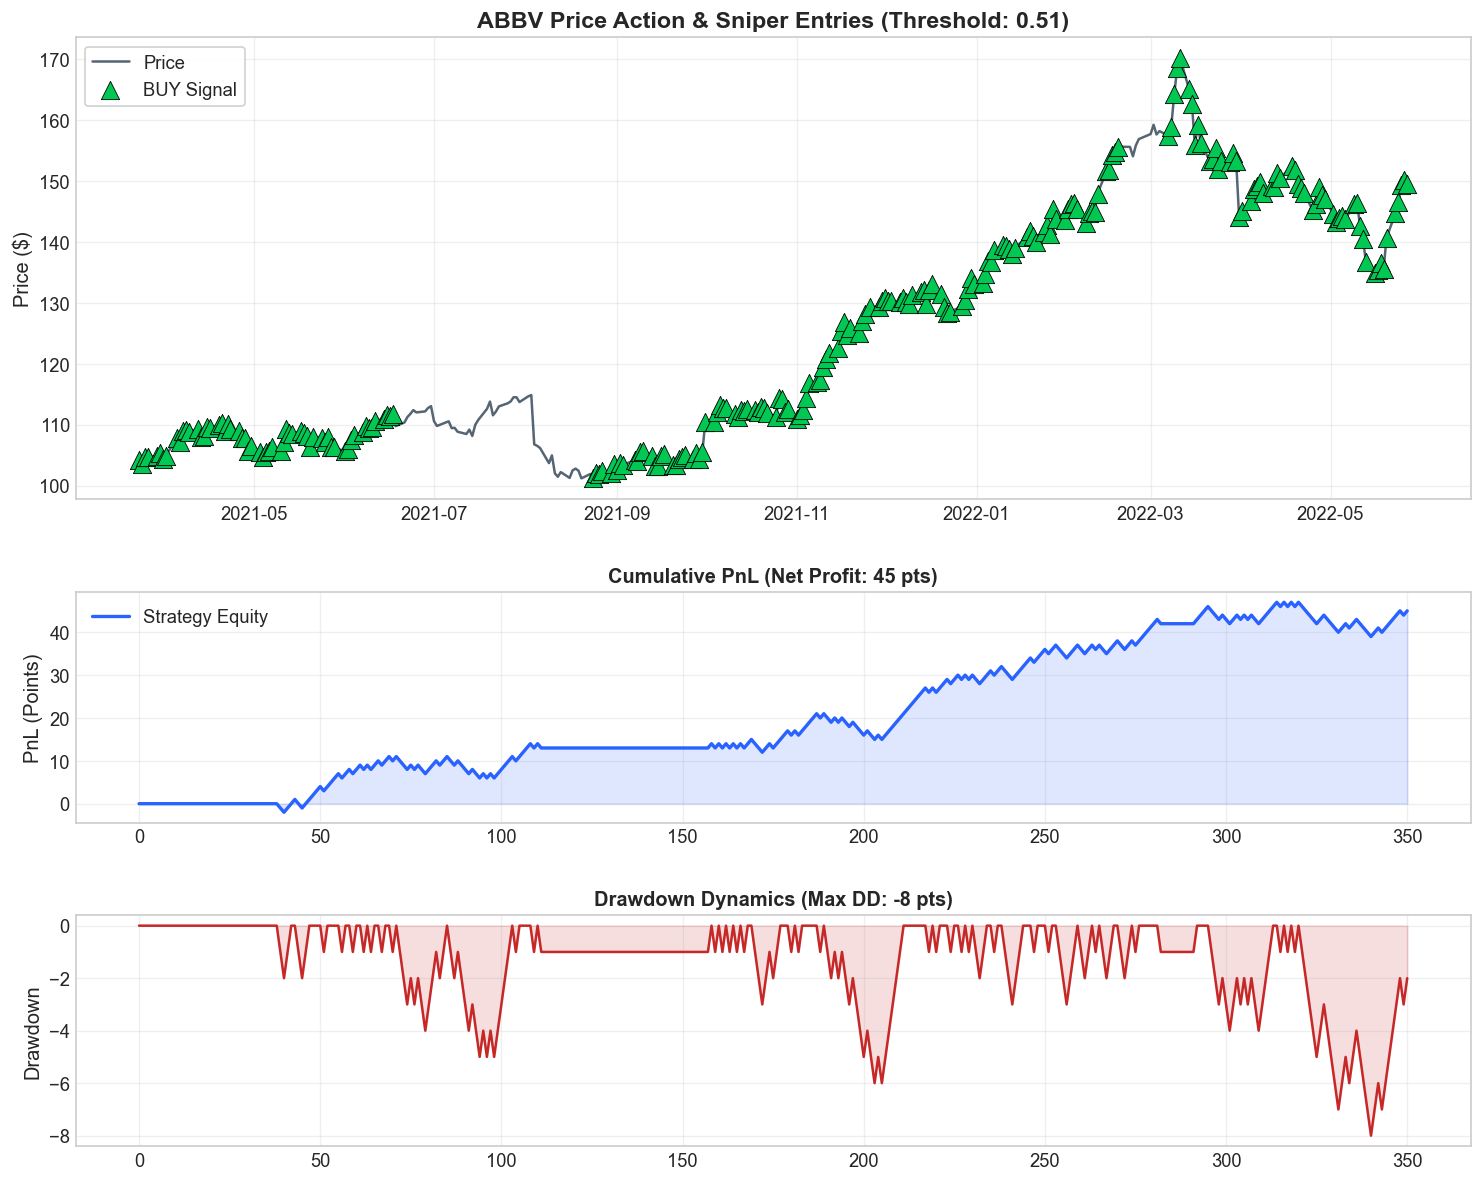


📊 RESULT THR: 0.52 | Trades: 200 | WR: 58.5% | Sharpe: 0.17


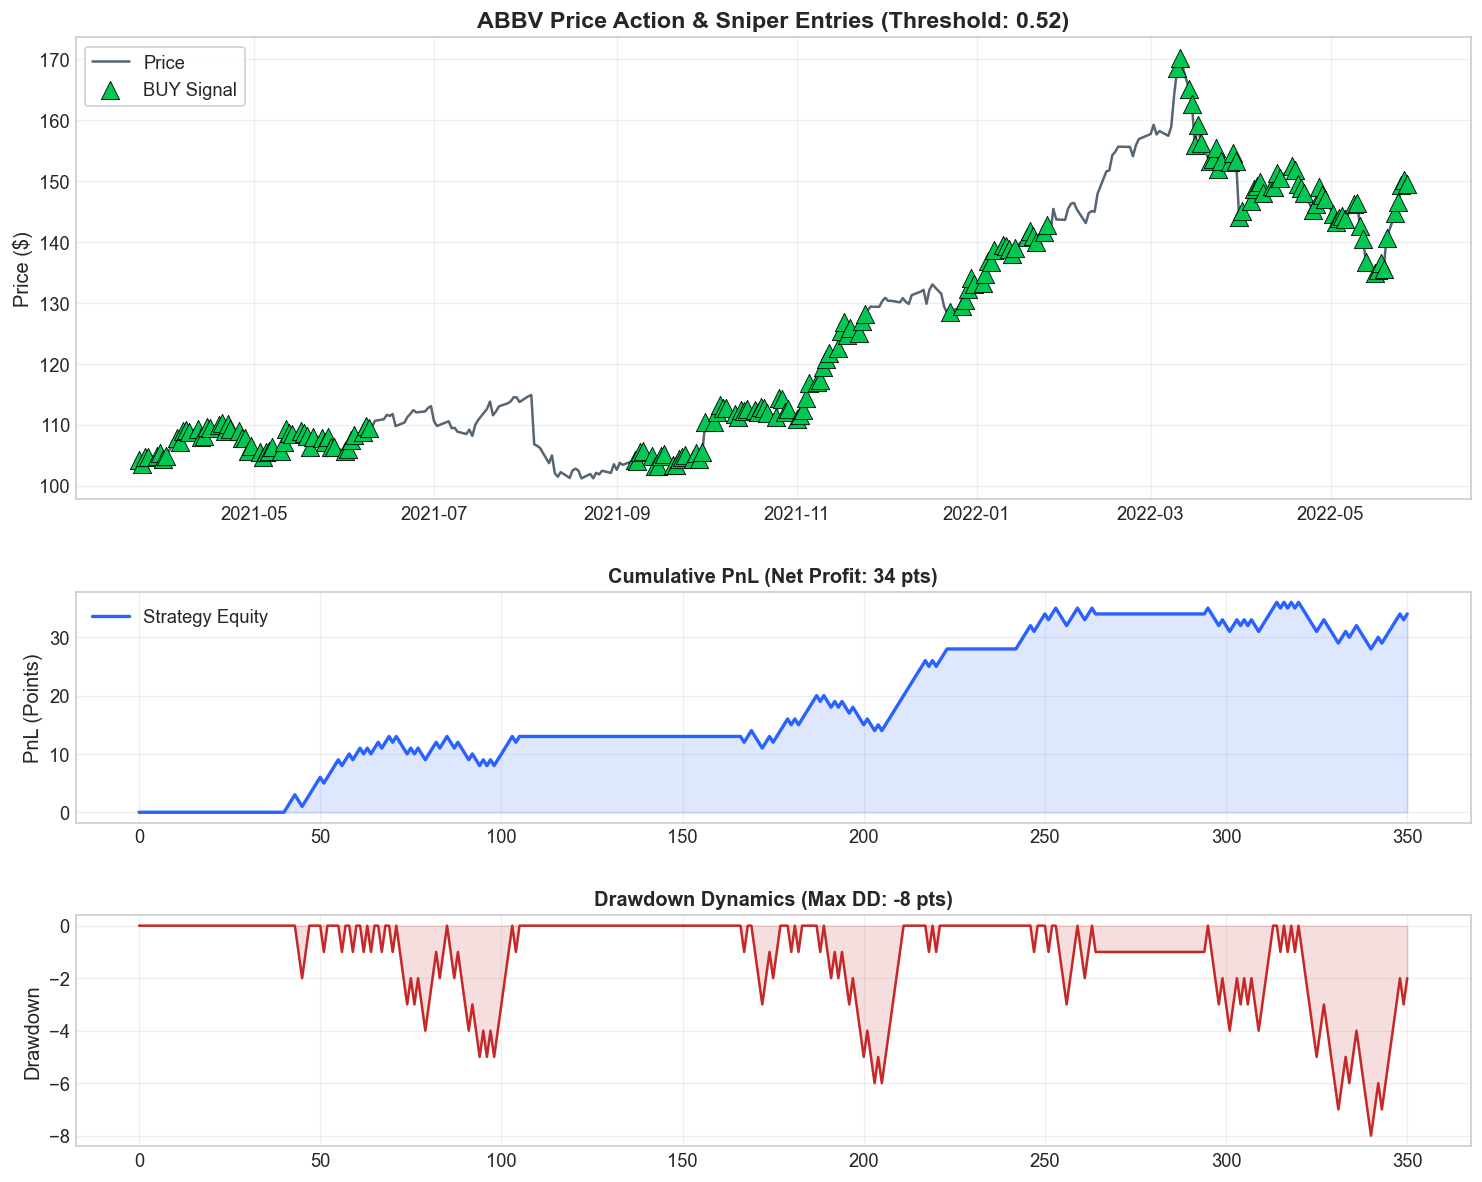


📊 RESULT THR: 0.53 | Trades: 158 | WR: 56.3% | Sharpe: 0.13


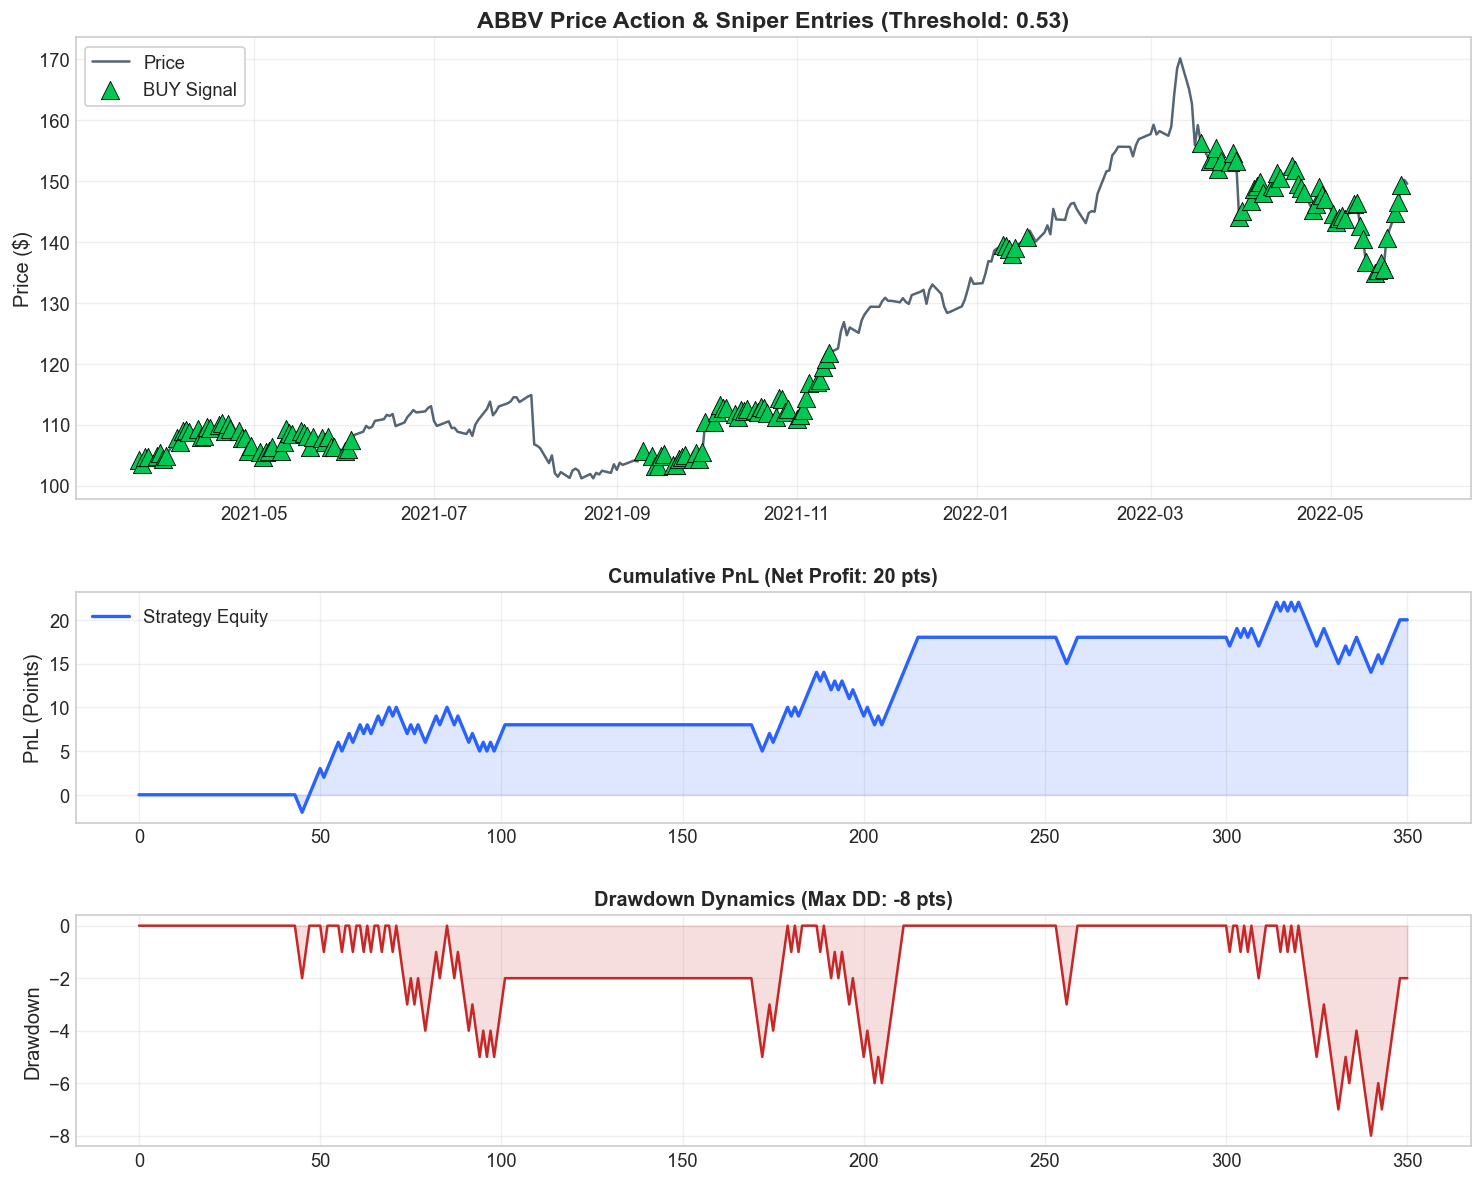


📊 RESULT THR: 0.54 | Trades: 122 | WR: 52.5% | Sharpe: 0.05


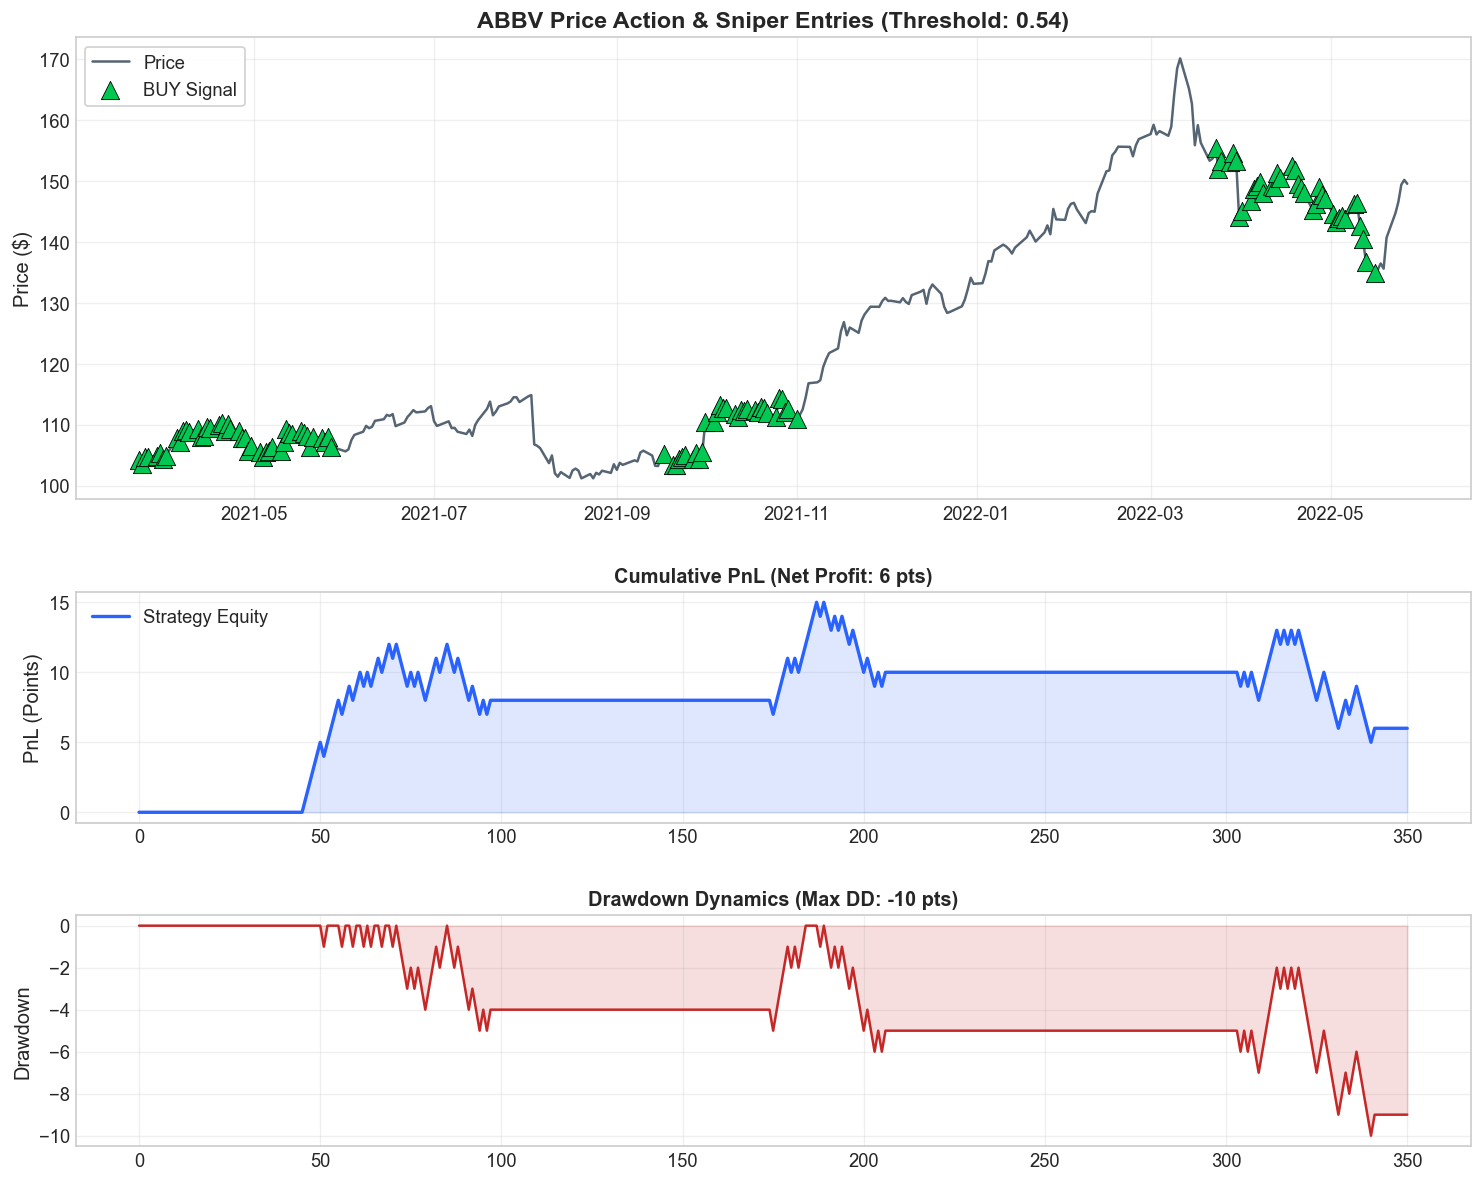


📊 RESULT THR: 0.55 | Trades: 79 | WR: 54.4% | Sharpe: 0.09


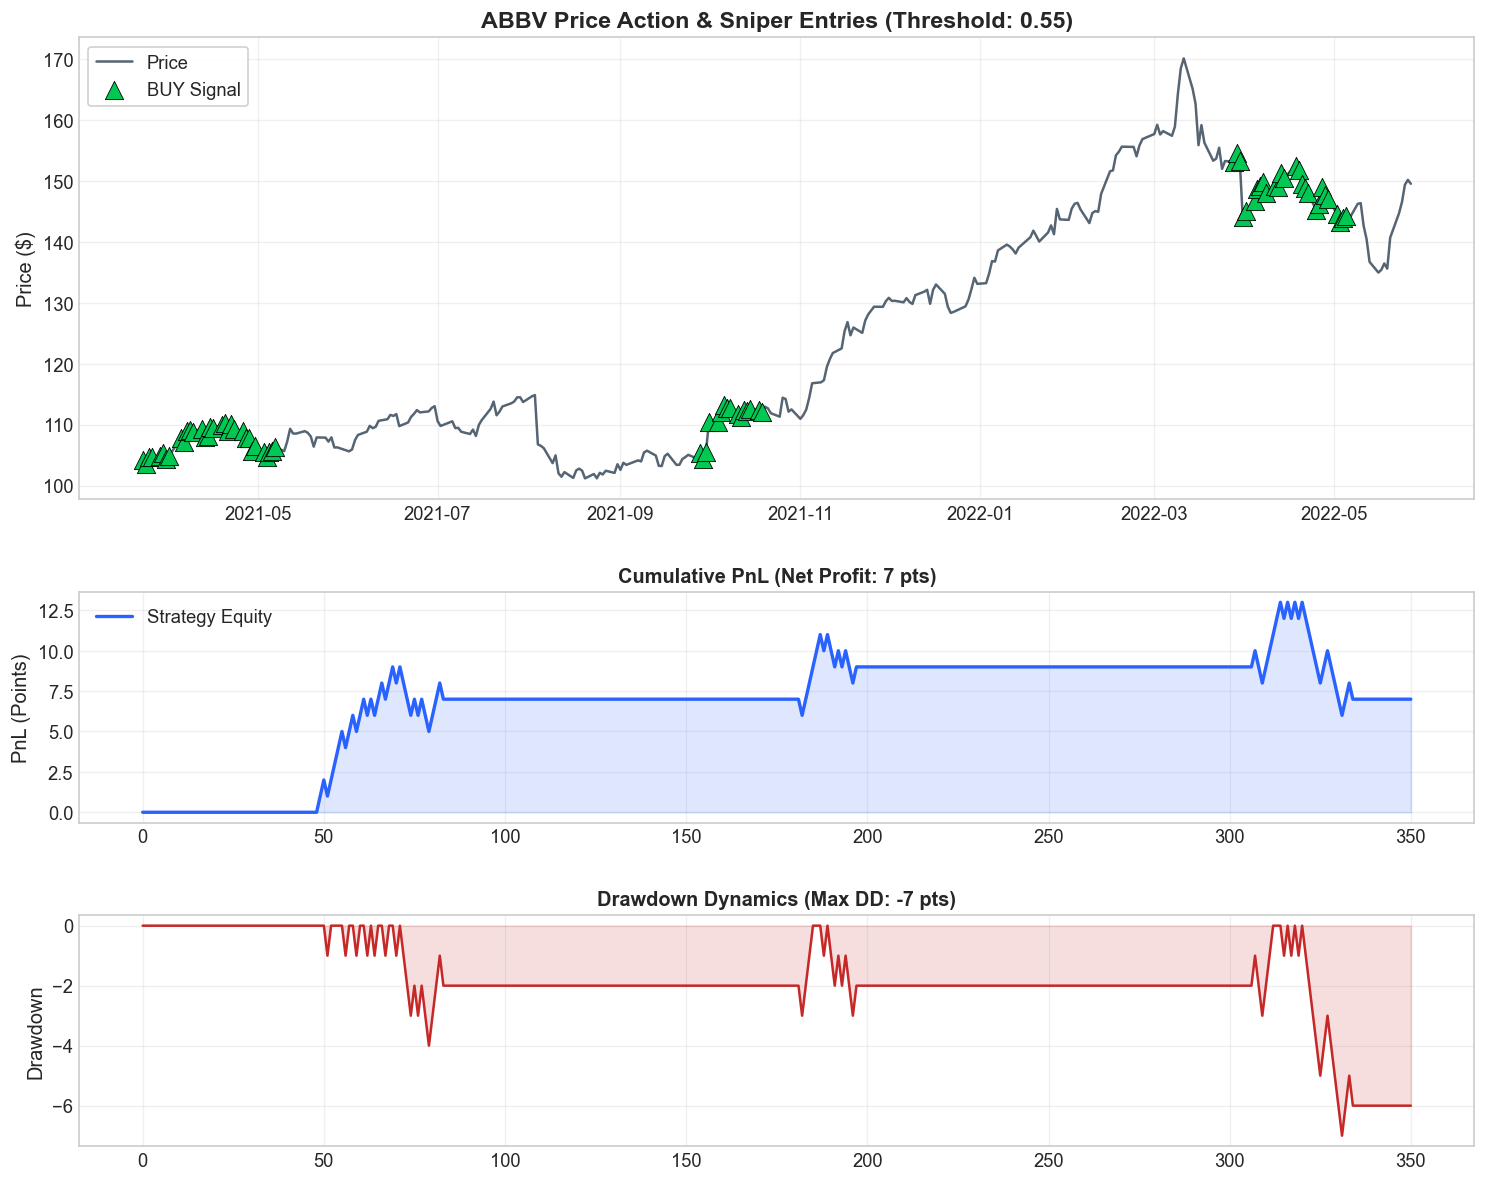


📊 RESULT THR: 0.56 | Trades: 43 | WR: 53.5% | Sharpe: 0.07


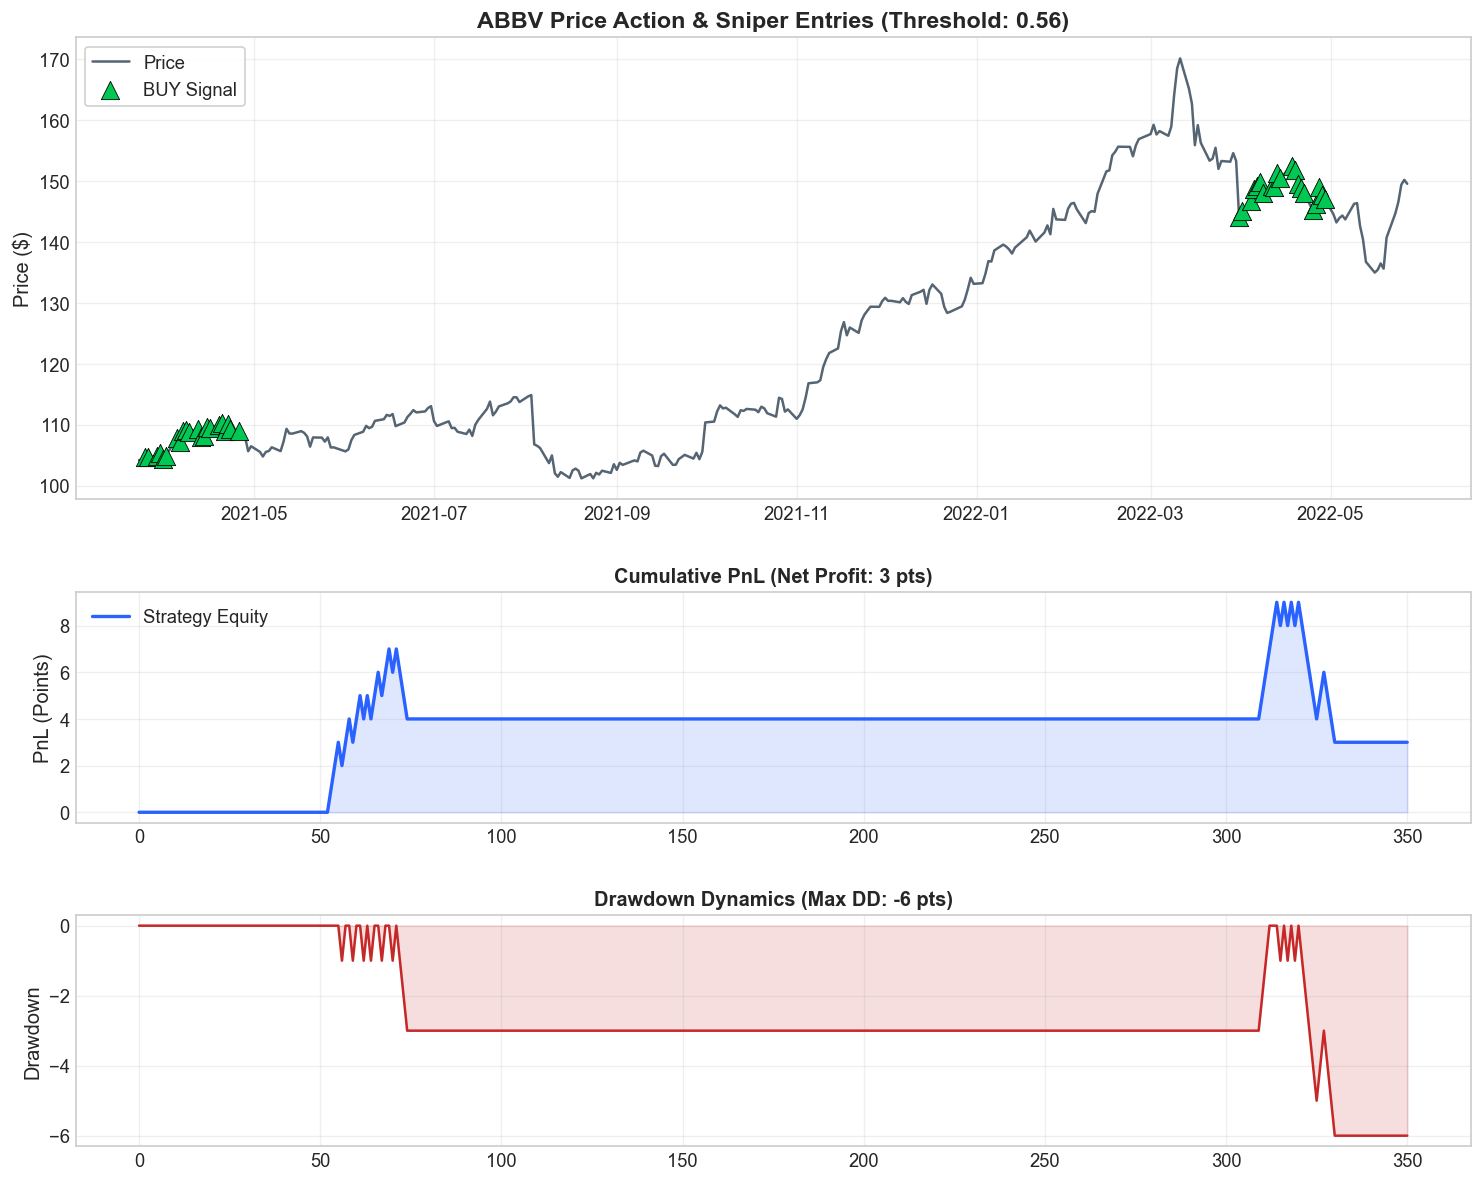


📊 RESULT THR: 0.57 | Trades: 28 | WR: 50.0% | Sharpe: 0.00


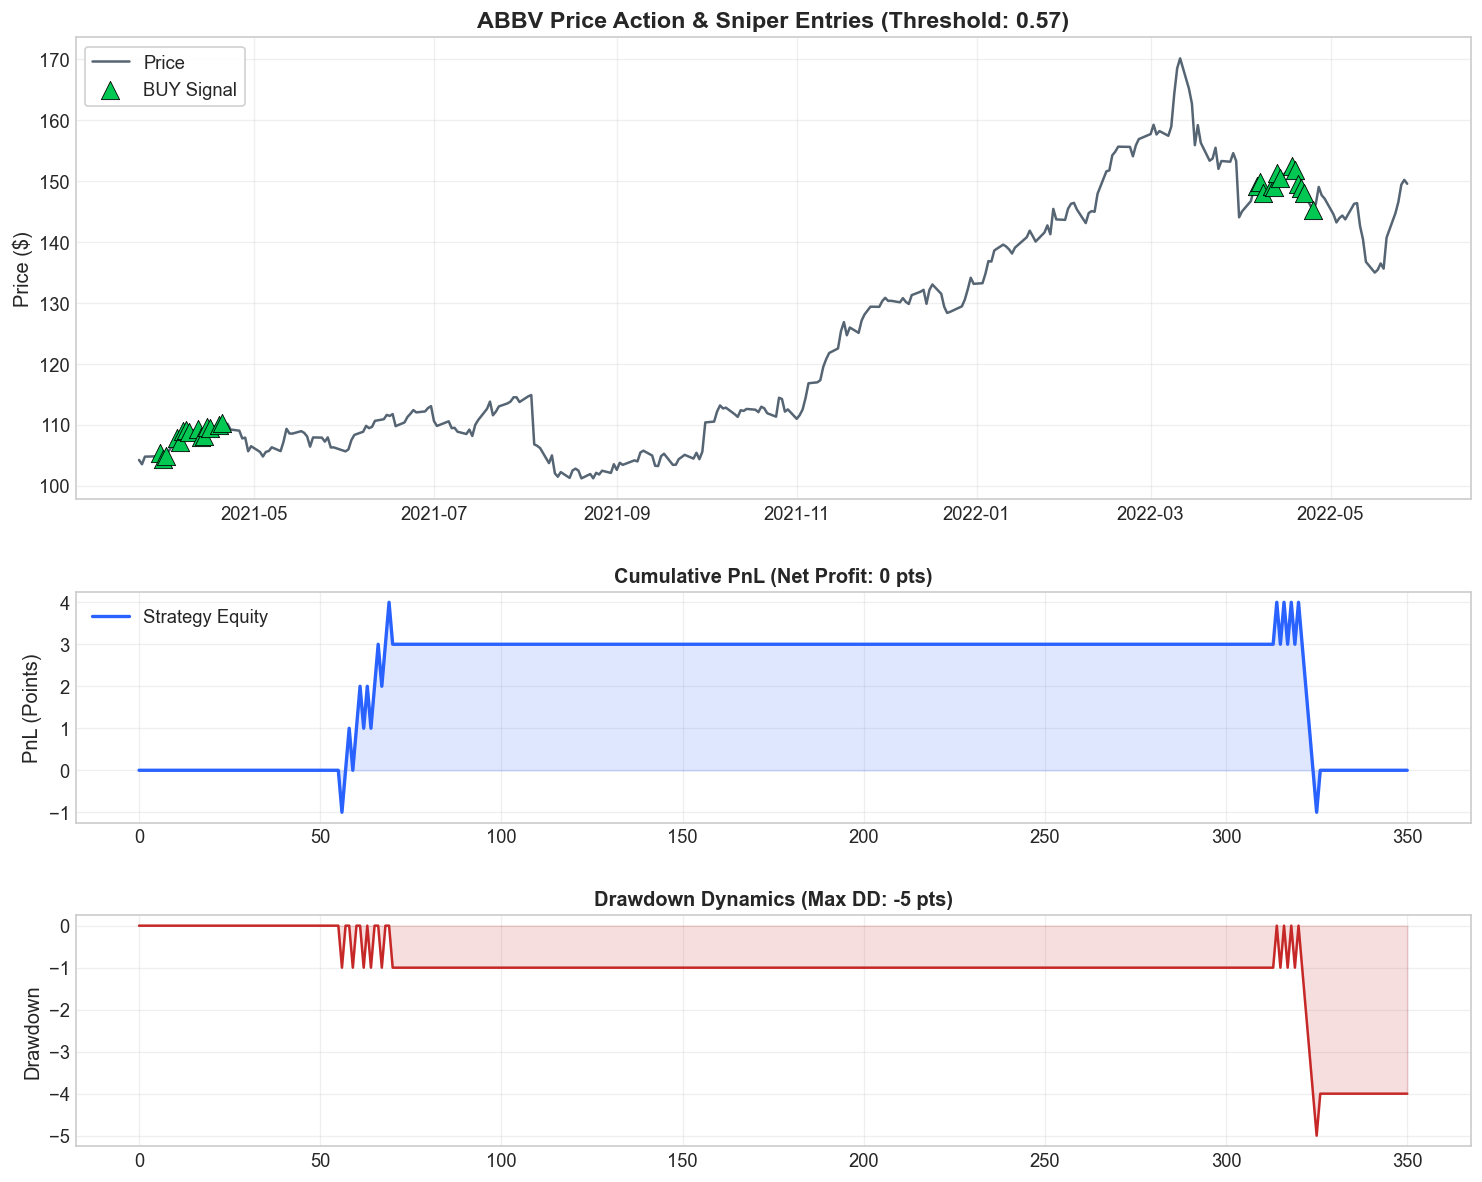


📊 RESULT THR: 0.58 | Trades: 8 | WR: 50.0% | Sharpe: 0.00


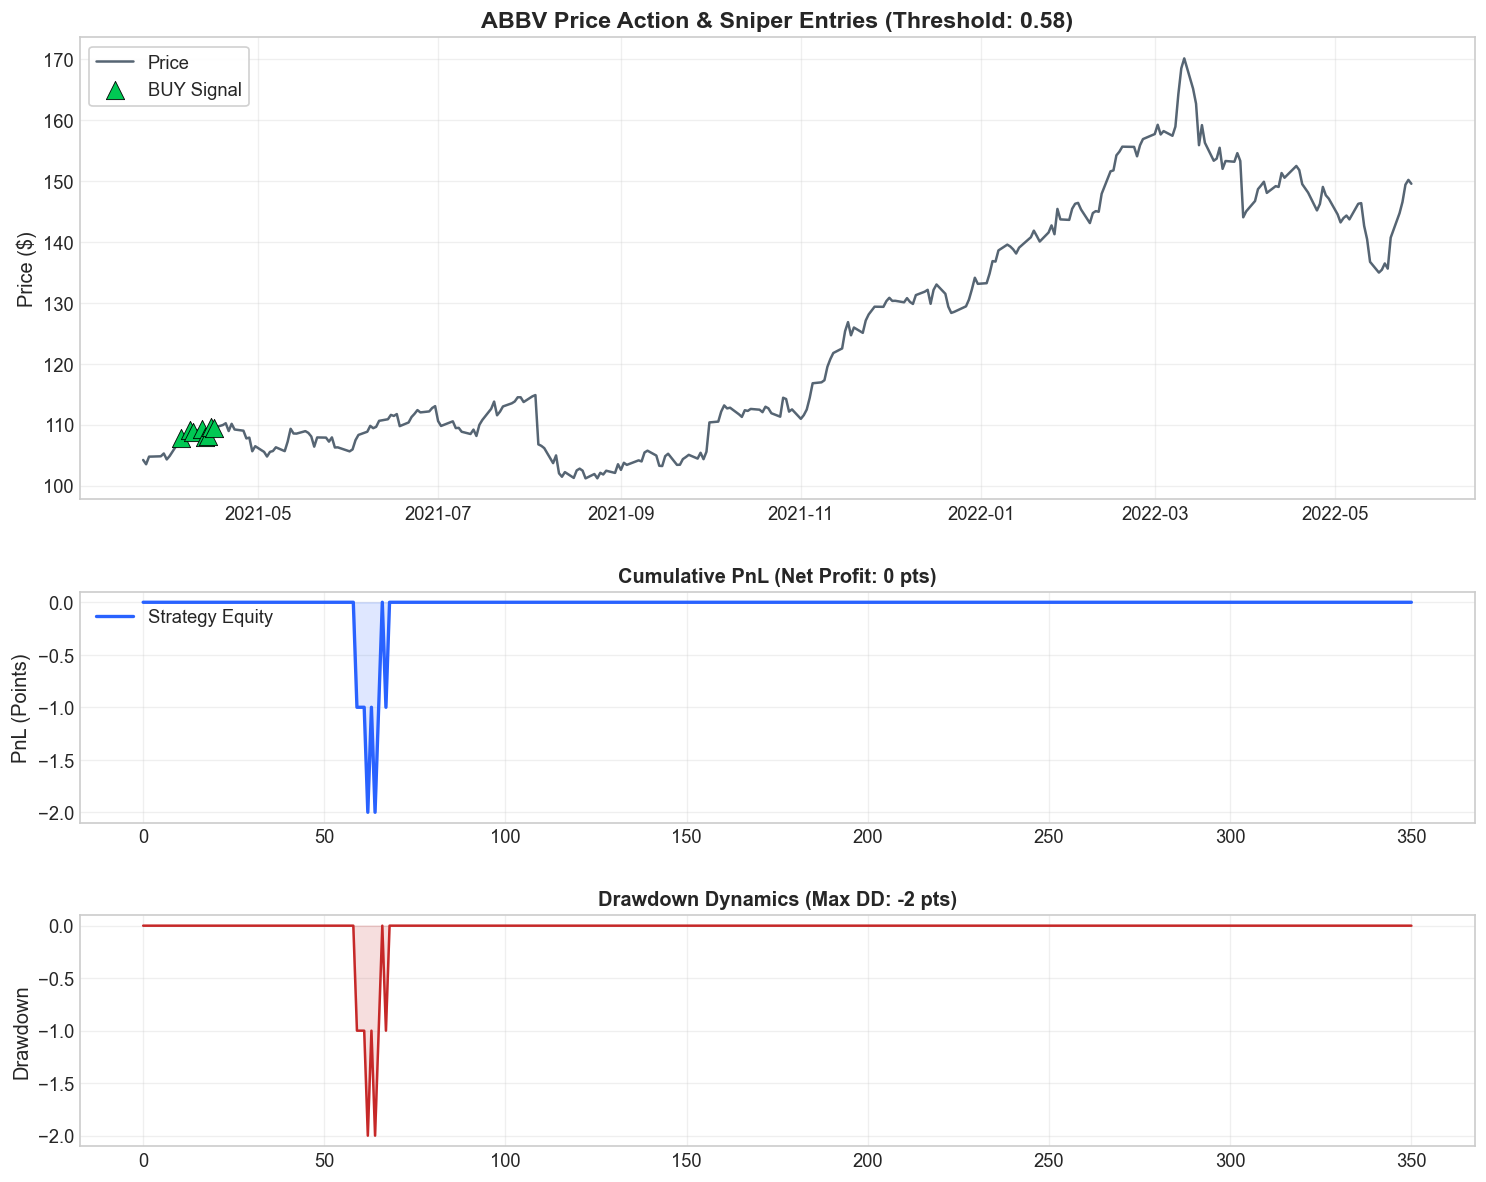

⚠️ Thr 0.59: Not enough trades (0.0)
⚠️ Thr 0.6: Not enough trades (0.0)


In [7]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import warnings

# ══════════════════════════════════════════════════════════════
# 0. VISUALIZATION SETTINGS (Pro Style)
# ══════════════════════════════════════════════════════════════
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.weight': 'normal',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5
})

# Colors
COL_PRICE = '#2C3E50'  # Dark Blue Grey
COL_BUY   = '#00C853'  # Bright Green
COL_SELL  = '#D50000'  # Bright Red
COL_EQ    = '#2962FF'  # Royal Blue
COL_DD    = '#C62828'  # Dark Red

# ══════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ══════════════════════════════════════════════════════════════
class Config:
    DATA_DIR = "US Stock Market Data/fundamentals"
    LOAD_DIR = "cnn_patch_models_v3"
    MODEL_NAME = "model_ep008_val53.05_hc56.21.pt"
    TARGET_TICKER = "ABBV" # <--- TARGET ASSET

    # Model Hyperparams
    SEQ_LEN = 30; PATCH_LEN = 6; STRIDE = 3; NORM_WINDOW = 60
    D_MODEL = 24; N_HEADS = 4; N_LAYERS = 2; DROPOUT = 0.25; D_FUSE = 48
    BATCH_SIZE = 64
    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

cfg = Config()
cfg.N_PATCHES = (cfg.SEQ_LEN - cfg.PATCH_LEN) // cfg.STRIDE + 1
MODEL_PATH = os.path.join(cfg.LOAD_DIR, cfg.MODEL_NAME)

# ══════════════════════════════════════════════════════════════
# 2. MODEL DEFINITIONS (Must match training)
# ══════════════════════════════════════════════════════════════
class LightPatchTST(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.n_ch, self.patch_len, self.stride = n_ch, patch_len, stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.d_model = d_model
        self.norm = nn.BatchNorm1d(n_ch)
        self.patch_proj = nn.Sequential(nn.Linear(patch_len, d_model), nn.GELU(), nn.LayerNorm(d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*2, dropout, 'gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers)
        self.agg = nn.Sequential(nn.Linear(n_ch * d_model, d_model), nn.GELU(), nn.Dropout(dropout))
        self.out_dim = d_model

    def forward(self, x):
        B, L, C = x.shape
        x = self.norm(x.transpose(1, 2))
        p = x.unfold(2, self.patch_len, self.stride).reshape(B * C, self.n_patches, self.patch_len)
        p = self.patch_proj(p) + self.pos_embed
        p = self.transformer(p)
        return self.agg(p.mean(dim=1).reshape(B, C * self.d_model))

class LightCNN(nn.Module):
    def __init__(self, n_ch, d_out, dropout):
        super().__init__()
        h = 24
        self.conv = nn.Sequential(nn.Conv1d(n_ch, h, 3, padding=1), nn.BatchNorm1d(h), nn.GELU(),
                                  nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(h, d_out); self.out_dim = d_out
    def forward(self, x): return self.proj(self.conv(x.transpose(1, 2)).mean(dim=2))

class LightGatedFusion(nn.Module):
    def __init__(self, d1, d2, d_out):
        super().__init__()
        self.proj, self.gate = nn.Linear(d1+d2, d_out), nn.Linear(d1+d2, d_out)
        self.norm = nn.LayerNorm(d_out)
    def forward(self, x1, x2):
        c = torch.cat([x1, x2], dim=-1)
        return self.norm(torch.sigmoid(self.gate(c)) * self.proj(c))

class HybridModelV3(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout, d_fuse):
        super().__init__()
        self.cnn = LightCNN(n_ch, d_fuse, dropout)
        self.tst = LightPatchTST(n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout)
        self.fusion = LightGatedFusion(self.cnn.out_dim, self.tst.out_dim, d_fuse)
        self.head = nn.Sequential(nn.Linear(d_fuse, d_fuse), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_fuse, 2))
        self.temperature = nn.Parameter(torch.tensor(1.5))
    def forward(self, x):
        logits = self.head(self.fusion(self.cnn(x), self.tst(x)))
        probs = F.softmax(logits / self.temperature, dim=-1)
        return logits, probs.max(dim=-1).values

# ══════════════════════════════════════════════════════════════
# 3. HELPERS & LOADING
# ══════════════════════════════════════════════════════════════
def rolling_normalize(data, window):
    res = np.zeros_like(data)
    for i in range(len(data)):
        s = max(0, i - window)
        wd = data[s:i+1]
        if len(wd)>5: res[i] = (data[i] - wd.mean(0)) / (wd.std(0) + 1e-8)
    return np.clip(res, -5, 5)

def load_data(ticker):
    path = os.path.join(cfg.DATA_DIR, "test", f"{ticker}_fundamentals_test.csv")
    if not os.path.exists(path): raise FileNotFoundError(f"Missing: {path}")

    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        dates = df['date'].values
    else:
        dates = np.arange(len(df))

    # Feature Engineering (Compact)
    for w in [1, 5, 10, 20]: df[f'ret_{w}'] = df['close'].pct_change(w)
    df['vol_5'] = df['ret_1'].rolling(5).std()
    df = df.dropna().reset_index(drop=True)

    # Select Features
    exclude = ['date', 'close', 'target', 'open', 'high', 'low', 'volume']
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in [float, int, np.float64]]

    raw_feats = df[cols].values
    # Pad to 45
    if raw_feats.shape[1] < 45:
        raw_feats = np.hstack([raw_feats, np.zeros((len(raw_feats), 45-raw_feats.shape[1]))])
    raw_feats = raw_feats[:, :45]

    norm_feats = rolling_normalize(raw_feats, cfg.NORM_WINDOW)

    # Create Sequences
    X, y, p, d = [], [], [], []
    prices = df['close'].values
    targets = (df['close'].shift(-1) > df['close']).astype(int).values # 1=Up, 0=Down

    for i in range(cfg.NORM_WINDOW, len(norm_feats) - cfg.SEQ_LEN):
        X.append(norm_feats[i:i+cfg.SEQ_LEN])
        y.append(targets[i+cfg.SEQ_LEN-1])
        p.append(prices[i+cfg.SEQ_LEN-1])
        d.append(dates[i+cfg.SEQ_LEN-1])

    return np.array(X, dtype=np.float32), np.array(y), np.array(p), np.array(d)

# ══════════════════════════════════════════════════════════════
# 4. PLOTTING FUNCTION
# ══════════════════════════════════════════════════════════════
def plot_results(res, prices, dates, ticker, thr):
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1], hspace=0.3)

    # 1. PRICE ACTION & SIGNALS
    ax1 = fig.add_subplot(gs[0])

    # Plot last 300 points for clarity, or full if short
    zoom = 300
    if len(prices) > zoom:
        s_idx = len(prices) - zoom
        p_view = prices[s_idx:]
        d_view = dates[s_idx:]
        sig_view = res['signals'][s_idx:]
    else:
        p_view, d_view, sig_view = prices, dates, res['signals']

    ax1.plot(d_view, p_view, color=COL_PRICE, lw=1.5, label='Price', alpha=0.8)

    # Extract Buy/Sell indices relative to the view
    buy_mask = sig_view == 1
    sell_mask = sig_view == -1

    # PLOT BUYS (Green Up Triangle)
    if buy_mask.sum() > 0:
        ax1.scatter(d_view[buy_mask], p_view[buy_mask],
                   marker='^', color=COL_BUY, s=120, edgecolors='k', lw=0.5,
                   label='BUY Signal', zorder=5)

    # PLOT SELLS (Red Down Triangle)
    if sell_mask.sum() > 0:
        ax1.scatter(d_view[sell_mask], p_view[sell_mask],
                   marker='v', color=COL_SELL, s=120, edgecolors='k', lw=0.5,
                   label='SELL Signal', zorder=5)

    ax1.set_title(f"{ticker} Price Action & Sniper Entries (Threshold: {thr})", fontsize=14)
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.set_ylabel("Price ($)")

    # 2. EQUITY CURVE
    ax2 = fig.add_subplot(gs[1])
    pnl = res['cum_pnl']
    ax2.plot(pnl, color=COL_EQ, lw=2, label='Strategy Equity')
    ax2.fill_between(range(len(pnl)), 0, pnl, color=COL_EQ, alpha=0.15)
    ax2.set_title(f"Cumulative PnL (Net Profit: {pnl[-1]:.0f} pts)", fontsize=12)
    ax2.set_ylabel("PnL (Points)")
    ax2.legend(loc='upper left')

    # 3. DRAWDOWN
    ax3 = fig.add_subplot(gs[2])
    dd = res['drawdown']
    ax3.plot(dd, color=COL_DD, lw=1.5, label='Drawdown')
    ax3.fill_between(range(len(dd)), dd, 0, color=COL_DD, alpha=0.15)
    ax3.set_title(f"Drawdown Dynamics (Max DD: {res['max_dd']:.0f} pts)", fontsize=12)
    ax3.set_ylabel("Drawdown")

    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════════
# 5. MAIN EXECUTION
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print(f"🚀 Starting Analysis for {cfg.TARGET_TICKER}...")

    # Load
    X, y, prices, dates = load_data(cfg.TARGET_TICKER)
    print(f"✅ Data Loaded: {len(X)} samples")

    # Model
    model = HybridModelV3(45, cfg.SEQ_LEN, cfg.PATCH_LEN, cfg.STRIDE, cfg.D_MODEL, cfg.N_HEADS, cfg.N_LAYERS, cfg.DROPOUT, cfg.D_FUSE).to(cfg.DEVICE)
    try:
        ckpt = torch.load(MODEL_PATH, map_location=cfg.DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        print("✅ Model Loaded Successfully")
    except Exception as e:
        print(f"❌ Model Load Failed: {e}")
        exit()

    # Inference
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    dl = DataLoader(ds, batch_size=cfg.BATCH_SIZE)

    preds, targets_all, confs = [], [], []

    with torch.no_grad():
        for bx, by in dl:
            logits, c = model(bx.to(cfg.DEVICE))
            preds.extend(logits.argmax(1).cpu().numpy())
            targets_all.extend(by.numpy())
            confs.extend(c.cpu().numpy())

    P = np.array(preds)
    T = np.array(targets_all)
    C = np.array(confs)

    # Mapping:
    # Model Output 1 -> Buy (Target 1)
    # Model Output 0 -> Sell (Target 0)

    # Iterate Thresholds
    thresholds = [0.51,0.52,0.53,0.54,0.55,0.56,0.57,0.58,0.59,0.60]

    for thr in thresholds:
        # Filter Logic
        mask = C > thr

        # If model predicts 1 -> Signal 1 (Buy)
        # If model predicts 0 -> Signal -1 (Sell)
        # Else 0
        signals = np.zeros(len(P))

        # Vectorized assignment
        signals[mask] = np.where(P[mask] == 1, 1, -1)

        n_trades = np.abs(signals).sum()

        if n_trades < 5:
            print(f"⚠️ Thr {thr}: Not enough trades ({n_trades})")
            continue

        # PnL Calculation
        # If Signal 1 and Target 1 (Up) -> Win (+1)
        # If Signal 1 and Target 0 (Down) -> Loss (-1)
        # If Signal -1 and Target 0 (Down) -> Win (+1)
        # If Signal -1 and Target 1 (Up) -> Loss (-1)

        # Convert Target 0 to -1 for math
        T_mapped = np.where(T == 1, 1, -1)
        pnl_stream = signals * T_mapped

        cum_pnl = np.cumsum(pnl_stream)
        drawdown = cum_pnl - np.maximum.accumulate(cum_pnl)

        # Stats
        wins = (pnl_stream > 0).sum()
        win_rate = wins / n_trades * 100
        sharpe = pnl_stream[pnl_stream!=0].mean() / (pnl_stream[pnl_stream!=0].std() + 1e-6)

        res = {
            'signals': signals,
            'cum_pnl': cum_pnl,
            'drawdown': drawdown,
            'max_dd': drawdown.min()
        }

        print(f"\n📊 RESULT THR: {thr} | Trades: {int(n_trades)} | WR: {win_rate:.1f}% | Sharpe: {sharpe:.2f}")

        # Plot only for specific thresholds to avoid spamming
        if True:
            plot_results(res, prices, dates, cfg.TARGET_TICKER, thr)

🧠 Loading Model: model_ep008_val53.05_hc56.21.pt...
📂 Scanning 42 tickers...






  0%|          | 0/42 [00:00<?, ?it/s]



  2%|▏         | 1/42 [00:00<00:05,  7.77it/s]



  7%|▋         | 3/42 [00:00<00:03, 12.30it/s]



 12%|█▏        | 5/42 [00:00<00:02, 13.50it/s]



 17%|█▋        | 7/42 [00:00<00:02, 13.85it/s]



 21%|██▏       | 9/42 [00:00<00:02, 14.03it/s]



 26%|██▌       | 11/42 [00:00<00:02, 14.16it/s]



 31%|███       | 13/42 [00:00<00:01, 14.90it/s]



 36%|███▌      | 15/42 [00:01<00:01, 14.84it/s]



 40%|████      | 17/42 [00:01<00:01, 14.97it/s]



 45%|████▌     | 19/42 [00:01<00:01, 14.74it/s]



 50%|█████     | 21/42 [00:01<00:01, 14.81it/s]



 55%|█████▍    | 23/42 [00:01<00:01, 14.93it/s]



 60%|█████▉    | 25/42 [00:01<00:01, 14.76it/s]



 64%|██████▍   | 27/42 [00:01<00:01, 14.84it/s]



 69%|██████▉   | 29/42 [00:02<00:00, 14.95it/s]



 74%|███████▍  | 31/42 [00:02<00:00, 14.88it/s]



 79%|███████▊  | 33/42 [00:02<00:00, 14.82it/s]



 83%|████████▎ | 35/42 [00:02<00:00, 14.72it/s]



 88%|████████▊ | 37/42 [00:02<00:00, 14.6


🏆 OPTIMAL THRESHOLD: 0.51 (Avg Market Sharpe: 0.64)
   Threshold    Sharpe    WinRate  ProfitFactor     MaxDD
0       0.51  0.641112  52.409267      1.151696 -0.245285
1       0.52  0.482996  52.397590      1.149121 -0.201606
2       0.53  0.410955  53.124381      1.183002 -0.162415
3       0.54  0.277209  52.212089      1.181710 -0.136100
4       0.55  0.268986  50.988579      1.384410 -0.097037
5       0.56  0.248556  53.336462      1.581847 -0.071954
6       0.57  0.110808  51.236327      1.188129 -0.068136
7       0.58 -0.158978  48.949561      1.006391 -0.072975
8       0.59 -0.311159  47.653643      0.867301 -0.068753

💎 TOP 3 PERFORMERS (TEAR SHEET):
Ticker   Sharpe  TotalReturn     MaxDD   WinRate  ProfitFactor
  ABBV 2.052364     0.598915 -0.206735 58.301158      1.489192
   WMT 1.489103     0.747336 -0.164483 51.174935      1.411588
   PEP 1.340012     0.491032 -0.114333 58.438287      1.315037


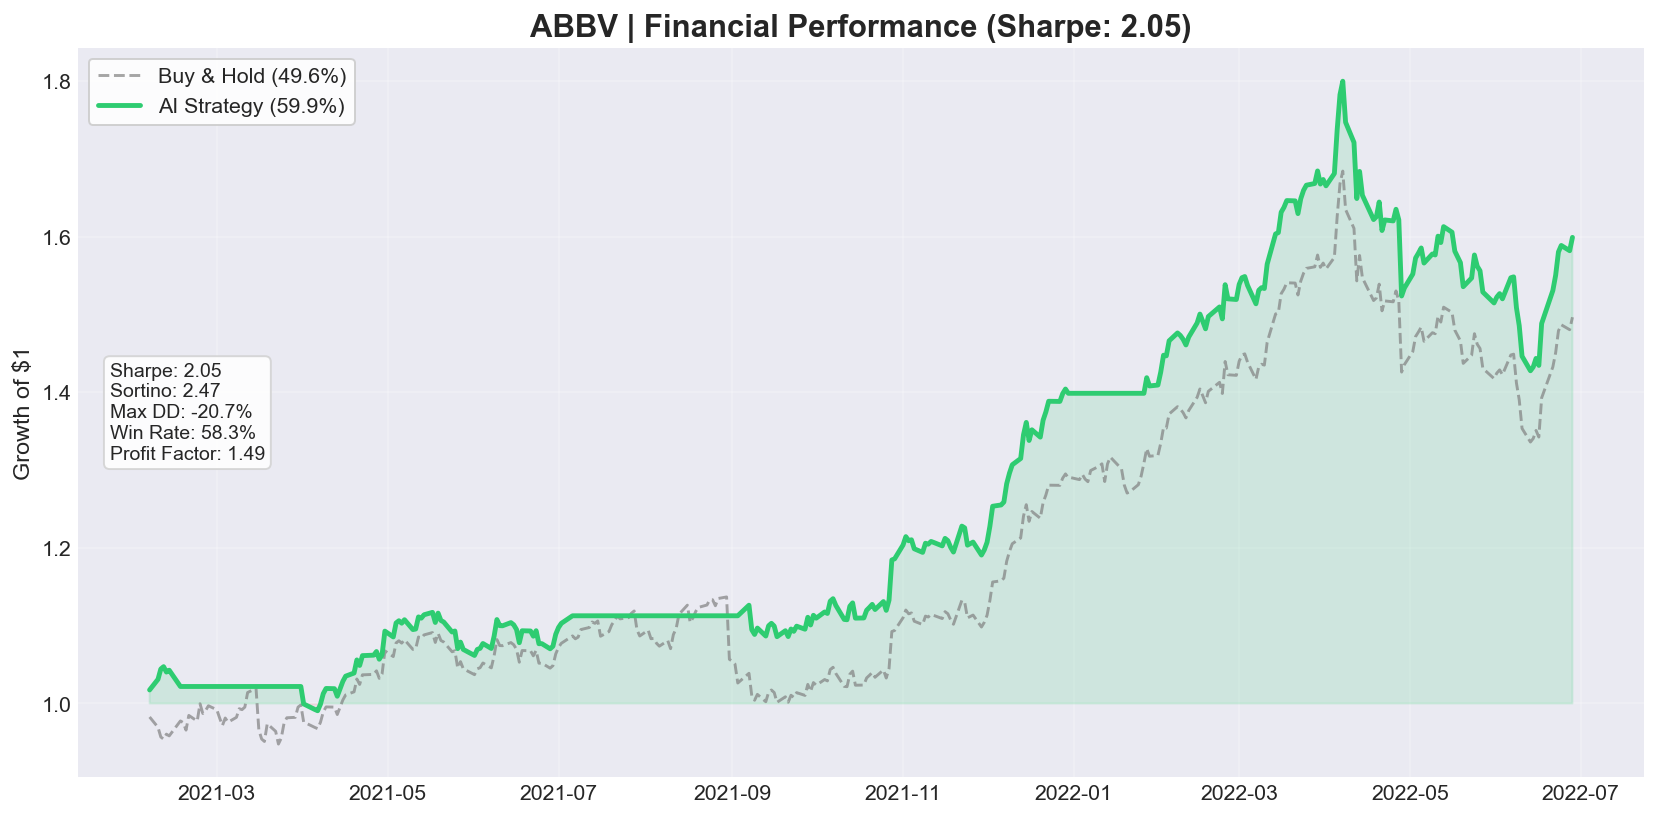

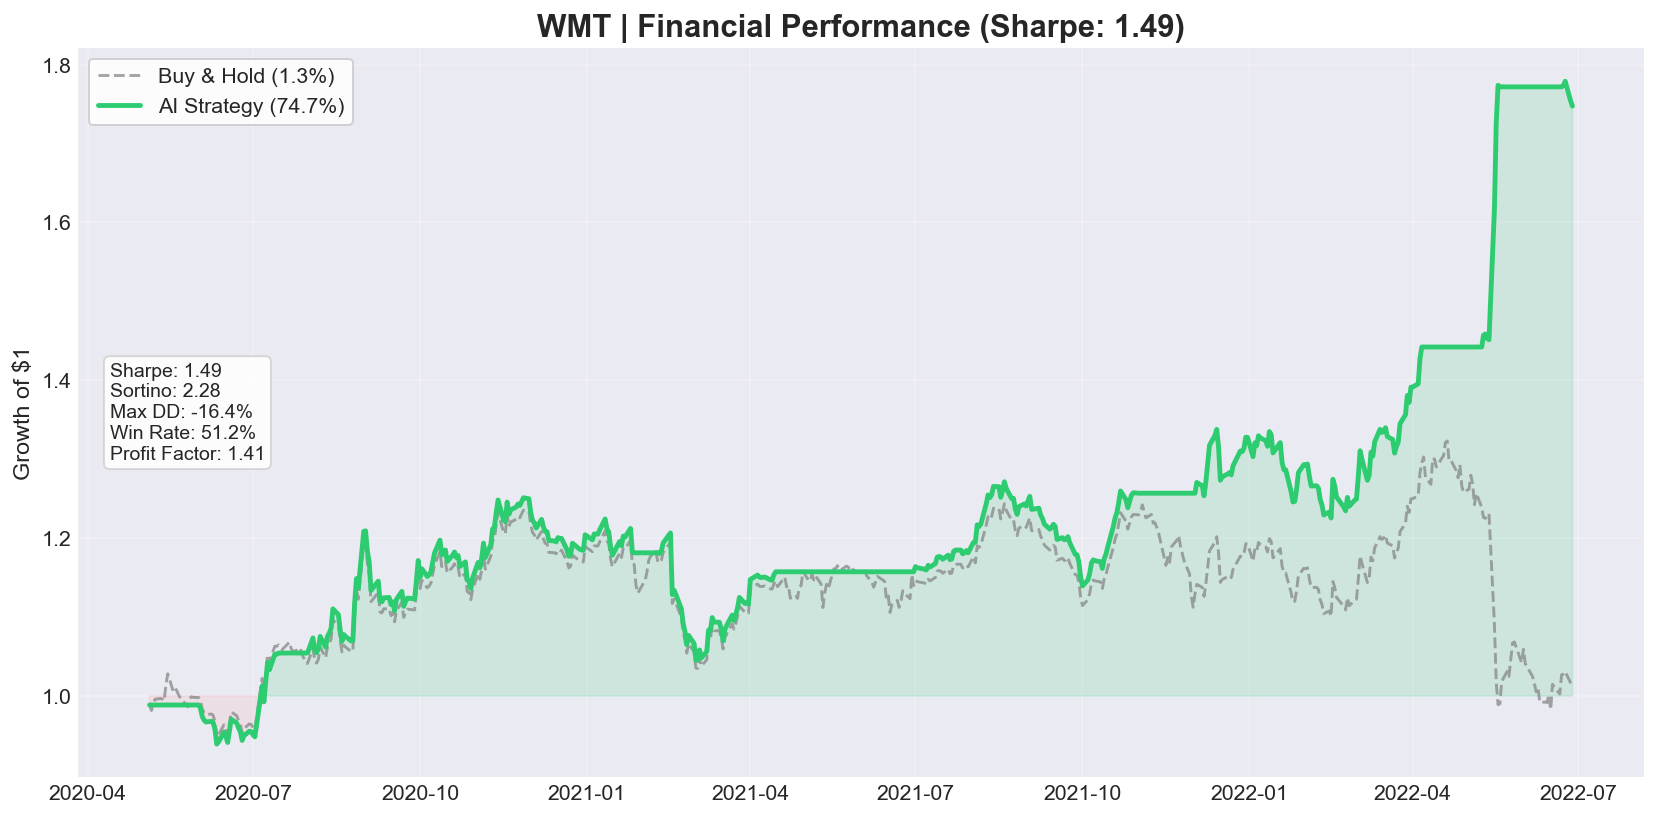

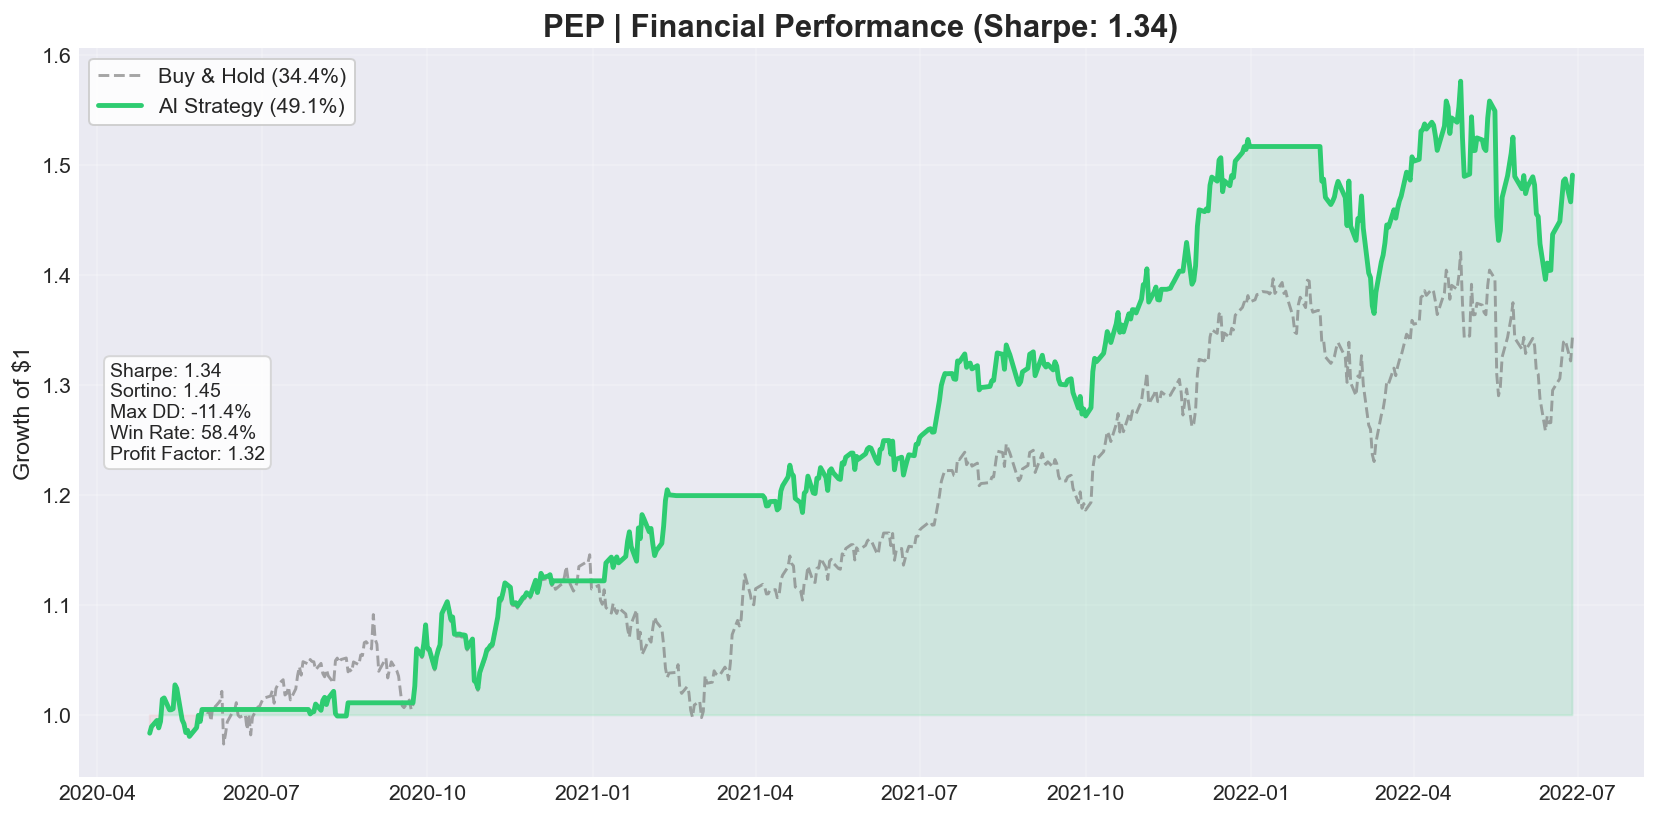

In [18]:
"""
🚀 MARKET-WIDE BENCHMARK PRO: HYBRID V3
=======================================
Scope: All tickers in data folder
Levels: Confidence Thresholds 0.51 -> 0.60
Output: Professional Tearsheets & 'Growth of $1' Charts
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
# Professional Style Setup
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'figure.dpi': 140
})

# ══════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ══════════════════════════════════════════════════════════════
class Config:
    DATA_DIR = "US Stock Market Data/fundamentals/test"
    LOAD_DIR = "cnn_patch_models_v3"
    MODEL_NAME = "model_ep008_val53.05_hc56.21.pt"

    # Model Params (Must match training)
    SEQ_LEN = 30; PATCH_LEN = 6; STRIDE = 3; NORM_WINDOW = 60
    D_MODEL = 24; N_HEADS = 4; N_LAYERS = 2; DROPOUT = 0.25; D_FUSE = 48
    BATCH_SIZE = 512
    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

    # Analysis Levels (Sensitivity Check)
    THRESHOLDS = np.arange(0.51, 0.61, 0.01)

cfg = Config()
MODEL_PATH = os.path.join(cfg.LOAD_DIR, cfg.MODEL_NAME)

# ══════════════════════════════════════════════════════════════
# 2. MODEL DEFINITION (Immutable)
# ══════════════════════════════════════════════════════════════
class LightPatchTST(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.n_ch, self.patch_len, self.stride = n_ch, patch_len, stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.d_model = d_model
        self.norm = nn.BatchNorm1d(n_ch)
        self.patch_proj = nn.Sequential(nn.Linear(patch_len, d_model), nn.GELU(), nn.LayerNorm(d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*2, dropout, 'gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers)
        self.agg = nn.Sequential(nn.Linear(n_ch * d_model, d_model), nn.GELU(), nn.Dropout(dropout))
        self.out_dim = d_model
    def forward(self, x):
        B, L, C = x.shape
        x = self.norm(x.transpose(1, 2))
        p = x.unfold(2, self.patch_len, self.stride).reshape(B * C, self.n_patches, self.patch_len)
        p = self.patch_proj(p) + self.pos_embed
        p = self.transformer(p)
        return self.agg(p.mean(dim=1).reshape(B, C * self.d_model))

class LightCNN(nn.Module):
    def __init__(self, n_ch, d_out, dropout):
        super().__init__()
        h = 24
        self.conv = nn.Sequential(nn.Conv1d(n_ch, h, 3, padding=1), nn.BatchNorm1d(h), nn.GELU(),
                                  nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(h, d_out); self.out_dim = d_out
    def forward(self, x): return self.proj(self.conv(x.transpose(1, 2)).mean(dim=2))

class LightGatedFusion(nn.Module):
    def __init__(self, d1, d2, d_out):
        super().__init__()
        self.proj, self.gate = nn.Linear(d1+d2, d_out), nn.Linear(d1+d2, d_out)
        self.norm = nn.LayerNorm(d_out)
    def forward(self, x1, x2):
        c = torch.cat([x1, x2], dim=-1)
        return self.norm(torch.sigmoid(self.gate(c)) * self.proj(c))

class HybridModelV3(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout, d_fuse):
        super().__init__()
        self.cnn = LightCNN(n_ch, d_fuse, dropout)
        self.tst = LightPatchTST(n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout)
        self.fusion = LightGatedFusion(self.cnn.out_dim, self.tst.out_dim, d_fuse)
        self.head = nn.Sequential(nn.Linear(d_fuse, d_fuse), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_fuse, 2))
        self.temperature = nn.Parameter(torch.tensor(1.5))
    def forward(self, x):
        logits = self.head(self.fusion(self.cnn(x), self.tst(x)))
        probs = F.softmax(logits / self.temperature, dim=-1)
        return logits, probs.max(dim=-1).values

# ══════════════════════════════════════════════════════════════
# 3. ADVANCED METRICS LOGIC
# ══════════════════════════════════════════════════════════════
def calculate_pro_metrics(returns):
    """
    Calculates institutional-grade metrics from a series of returns.
    returns: pd.Series or np.array of daily percentage returns (e.g., 0.01 for 1%)
    """
    if len(returns) < 2: return {}

    # 1. Cumulative Return
    cum_ret = (1 + returns).cumprod()
    total_return = cum_ret.iloc[-1] - 1

    # 2. Sharpe Ratio (Annualized, assuming risk_free=0)
    mean_ret = returns.mean()
    std_ret = returns.std() + 1e-9
    sharpe = (mean_ret / std_ret) * np.sqrt(252)

    # 3. Sortino Ratio (Downside Deviation only)
    downside = returns[returns < 0]
    downside_std = downside.std() + 1e-9
    sortino = (mean_ret / downside_std) * np.sqrt(252)

    # 4. Max Drawdown
    cum_max = cum_ret.cummax()
    drawdown = (cum_ret - cum_max) / cum_max
    max_dd = drawdown.min()

    # 5. Profit Factor
    wins = returns[returns > 0].sum()
    losses = abs(returns[returns < 0].sum())
    profit_factor = wins / losses if losses > 0 else np.inf

    return {
        'Total Return': total_return,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'MaxDD': max_dd,
        'Profit Factor': profit_factor,
        'Equity Curve': cum_ret,
        'Drawdown Curve': drawdown
    }

# ══════════════════════════════════════════════════════════════
# 4. DATA PROCESSING
# ══════════════════════════════════════════════════════════════
def create_features(df):
    df = df.copy()
    for w in [1, 5, 10, 20]: df[f'ret_{w}'] = df['close'].pct_change(w)
    df['vol_5'], df['vol_20'] = df['ret_1'].rolling(5).std(), df['ret_1'].rolling(20).std()
    fund_cols = ['pe_ratio', 'pb_ratio', 'ps_ratio', 'return_on_equity', 'debt_to_equity']
    for col in fund_cols:
        if col not in df: df[col] = 0.0
        else: df[f'{col}_z'] = (df[col]-df[col].rolling(20).mean())/(df[col].rolling(20).std()+1e-10)
    return df

def process_file(filepath):
    try:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.lower().str.strip()
        if len(df) < 200: return None

        # Save raw data for backtesting
        raw_prices = df['close'].values
        dates = pd.to_datetime(df['date']).values if 'date' in df.columns else np.arange(len(df))

        # Calculate Asset Daily Returns (for equity curve)
        # Shift -1 because we predict t+1. Return at t+1 is (Price_t+1 / Price_t) - 1
        asset_returns = df['close'].pct_change().shift(-1).fillna(0).values

        # Feats
        df = create_features(df)
        df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

        exclude = ['date', 'close', 'target', 'open', 'high', 'low', 'volume']
        cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64', 'float32']]

        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        feats = df[cols].values
        if feats.shape[1] < 45: feats = np.hstack([feats, np.zeros((len(feats), 45-feats.shape[1]))])
        else: feats = feats[:, :45]

        norm_feats = np.zeros_like(feats)
        for i in range(len(feats)):
            s = max(0, i - cfg.NORM_WINDOW)
            wd = feats[s:i+1]
            if len(wd)>5: norm_feats[i] = (feats[i] - wd.mean(0)) / (wd.std(0) + 1e-8)
        norm_feats = np.clip(norm_feats, -5, 5)

        X, y, r, d = [], [], [], []
        start_idx = cfg.NORM_WINDOW

        # Mapping: Model sees X[t], predicts y[t] (direction).
        # Result of action is asset_returns[t+SEQ_LEN-1] (the return of the next day)

        for i in range(start_idx, len(norm_feats) - cfg.SEQ_LEN):
            X.append(norm_feats[i:i+cfg.SEQ_LEN])
            y.append(df['target'].iloc[i+cfg.SEQ_LEN-1])
            idx = df.index[i+cfg.SEQ_LEN-1]
            r.append(asset_returns[idx])
            d.append(dates[idx])

        return np.array(X, dtype=np.float32), np.array(y), np.array(r), np.array(d)

    except Exception: return None

# ══════════════════════════════════════════════════════════════
# 5. MARKET SCANNER & BACKTEST ENGINE
# ══════════════════════════════════════════════════════════════
def run_market_scan():
    print(f"🧠 Loading Model: {cfg.MODEL_NAME}...")
    model = HybridModelV3(45, cfg.SEQ_LEN, cfg.PATCH_LEN, cfg.STRIDE, cfg.D_MODEL, cfg.N_HEADS, cfg.N_LAYERS, cfg.DROPOUT, cfg.D_FUSE).to(cfg.DEVICE)
    ckpt = torch.load(MODEL_PATH, map_location=cfg.DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    files = [f for f in os.listdir(cfg.DATA_DIR) if f.endswith('fundamentals_test.csv')]
    print(f"📂 Scanning {len(files)} tickers...")

    results_db = []

    for filename in tqdm(files):
        ticker = filename.replace('_fundamentals_test.csv', '')
        filepath = os.path.join(cfg.DATA_DIR, filename)
        data = process_file(filepath)
        if data is None: continue

        X, y_true, returns_daily, dates = data
        if len(X) < 50: continue

        # Inference
        dataset = TensorDataset(torch.FloatTensor(X))
        loader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
        preds_all, conf_all = [], []
        with torch.no_grad():
            for bx in loader:
                logits, conf = model(bx[0].to(cfg.DEVICE))
                preds_all.extend(logits.argmax(1).cpu().numpy())
                conf_all.extend(conf.cpu().numpy())

        preds_all = np.array(preds_all)
        conf_all = np.array(conf_all)

        # Iterate Thresholds
        for thr in cfg.THRESHOLDS:
            # Logic: If Conf > Thr: Trade (Long/Short). Else: Cash (Return=0)
            # Signal: 1 (Long), 0 (Short in this model context? No, prediction is 0 or 1)
            # Let's assume prediction 1 = Long, 0 = Short (or Cash if you prefer)
            # Standard: 1 = Long, 0 = Sell/Short.
            # Strategy Return = Signal_Direction * Market_Return

            mask = conf_all > thr
            n_trades = mask.sum()
            if n_trades < 10: continue

            # Convert 0/1 preds to -1/1 position
            # If pred is 1 -> Position 1. If pred is 0 -> Position -1.
            position = np.where(preds_all == 1, 1, -1)

            # Apply Mask: Only trade when confident. Else 0 position (Cash)
            # (Or keep old position? Simplifying to 'In/Out' for benchmark)
            active_position = position * mask.astype(int)

            # Strategy Returns
            strat_ret = active_position * returns_daily
            strat_series = pd.Series(strat_ret)

            # Benchmark Returns (Buy & Hold)
            bench_ret = pd.Series(returns_daily)

            # Calc Metrics
            metrics = calculate_pro_metrics(strat_series)
            bench_metrics = calculate_pro_metrics(bench_ret)

            if not metrics: continue

            results_db.append({
                'Ticker': ticker,
                'Threshold': float(thr),
                'Trades': n_trades,
                'WinRate': (strat_ret[mask] > 0).mean() * 100,

                # Pro Metrics
                'Sharpe': metrics['Sharpe'],
                'Sortino': metrics['Sortino'],
                'MaxDD': metrics['MaxDD'],
                'TotalReturn': metrics['Total Return'],
                'ProfitFactor': metrics['Profit Factor'],

                # Curves (Store for plotting)
                'EquityCurve': metrics['Equity Curve'].values,
                'BenchCurve': bench_metrics['Equity Curve'].values,
                'Dates': dates
            })

    return pd.DataFrame(results_db)

# ══════════════════════════════════════════════════════════════
# 6. VISUALIZATION (THE "GROWTH OF $1" CHART)
# ══════════════════════════════════════════════════════════════
def visualize_pro_results(df):
    if df.empty: return print("❌ No valid trades found.")

    # A. Global Heatmap of Sharpe Ratio
    stats = df.groupby('Threshold')[['Sharpe', 'WinRate', 'ProfitFactor', 'MaxDD']].mean().reset_index()
    best_thr_idx = stats['Sharpe'].idxmax()
    best_thr = stats.iloc[best_thr_idx]['Threshold']

    print(f"\n🏆 OPTIMAL THRESHOLD: {best_thr:.2f} (Avg Market Sharpe: {stats.iloc[best_thr_idx]['Sharpe']:.2f})")
    print(stats)

    # B. Select Top 3 Tickers at Best Threshold
    subset = df[df['Threshold'] == np.round(best_thr, 2)]
    if subset.empty: subset = df[df['Threshold'] == df['Threshold'].unique()[0]] # Fallback

    # Sort by Sharpe + Total Return
    top_3 = subset.sort_values('Sharpe', ascending=False).head(3)

    print("\n💎 TOP 3 PERFORMERS (TEAR SHEET):")
    print(top_3[['Ticker', 'Sharpe', 'TotalReturn', 'MaxDD', 'WinRate', 'ProfitFactor']].to_string(index=False))

    # C. Plot "Growth of $1" for Top 3
    for i, row in top_3.iterrows():
        ticker = row['Ticker']
        eq_curve = row['EquityCurve']
        bench_curve = row['BenchCurve']
        dates = row['Dates']

        # Normalize to start at $1.00
        # Curves from calc_metrics are cumprod (1.02, 1.05...).
        # Just ensure they align.

        plt.figure(figsize=(12, 6))

        # Benchmark (Dashed Gray)
        plt.plot(dates, bench_curve, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
                 label=f'Buy & Hold ({bench_curve[-1]-1:.1%})')

        # AI Strategy (Solid Green/Blue)
        color = '#2ecc71' if row['TotalReturn'] > 0 else '#e74c3c'
        plt.plot(dates, eq_curve, color=color, linewidth=2.5,
                 label=f'AI Strategy ({row["TotalReturn"]:.1%})')

        # Fill Area (Like the screenshot)
        plt.fill_between(dates, eq_curve, 1.0, where=(eq_curve >= 1.0),
                         color=color, alpha=0.15, interpolate=True)
        plt.fill_between(dates, eq_curve, 1.0, where=(eq_curve < 1.0),
                         color='red', alpha=0.05, interpolate=True)

        # Annotations
        plt.title(f"{ticker} | Financial Performance (Sharpe: {row['Sharpe']:.2f})", fontsize=16)
        plt.ylabel("Growth of $1", fontsize=12)
        plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

        # Add Metrics Text Box
        textstr = '\n'.join((
            f"Sharpe: {row['Sharpe']:.2f}",
            f"Sortino: {row['Sortino']:.2f}",
            f"Max DD: {row['MaxDD']:.1%}",
            f"Win Rate: {row['WinRate']:.1f}%",
            f"Profit Factor: {row['ProfitFactor']:.2f}"
        ))
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
        plt.gca().text(0.02, 0.50, textstr, transform=plt.gca().transAxes, fontsize=10,
                       verticalalignment='center', bbox=props)

        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()


    return None


# ══════════════════════════════════════════════════════════════
# 7. EXECUTION
# ══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    results_df = run_market_scan()
    visualize_pro_results(results_df)

Exception ignored in: <function tqdm.__del__ at 0x16895dcf0>
Traceback (most recent call last):
  File "/Users/vladimirmamonov/projects/OLD/SVETA/.venv1/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
  File "/Users/vladimirmamonov/projects/OLD/SVETA/.venv1/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x16895dcf0>
Traceback (most recent call last):
  File "/Users/vladimirmamonov/projects/OLD/SVETA/.venv1/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
  File "/Users/vladimirmamonov/projects/OLD/SVETA/.venv1/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x16895dcf0>
Traceback (most recent call last):
  File "/Users/vladimirmamonov/projects/OLD/SVETA/.venv1/lib/python3.10/site-packages/tqdm/std

🧠 Loading Model: model_ep008_val53.05_hc56.21.pt...
📂 Scanning 42 tickers...

🏆 GLOBAL OPTIMAL THRESHOLD: 0.51

💎 TOP 3 PERFORMERS (TEAR SHEET):
Ticker   Sharpe  TotalReturn   WinRate
  ABBV 2.208398     0.643303 58.754864
   TMO 1.568216     1.013479 57.766990
    HD 1.492507     0.647569 58.878505


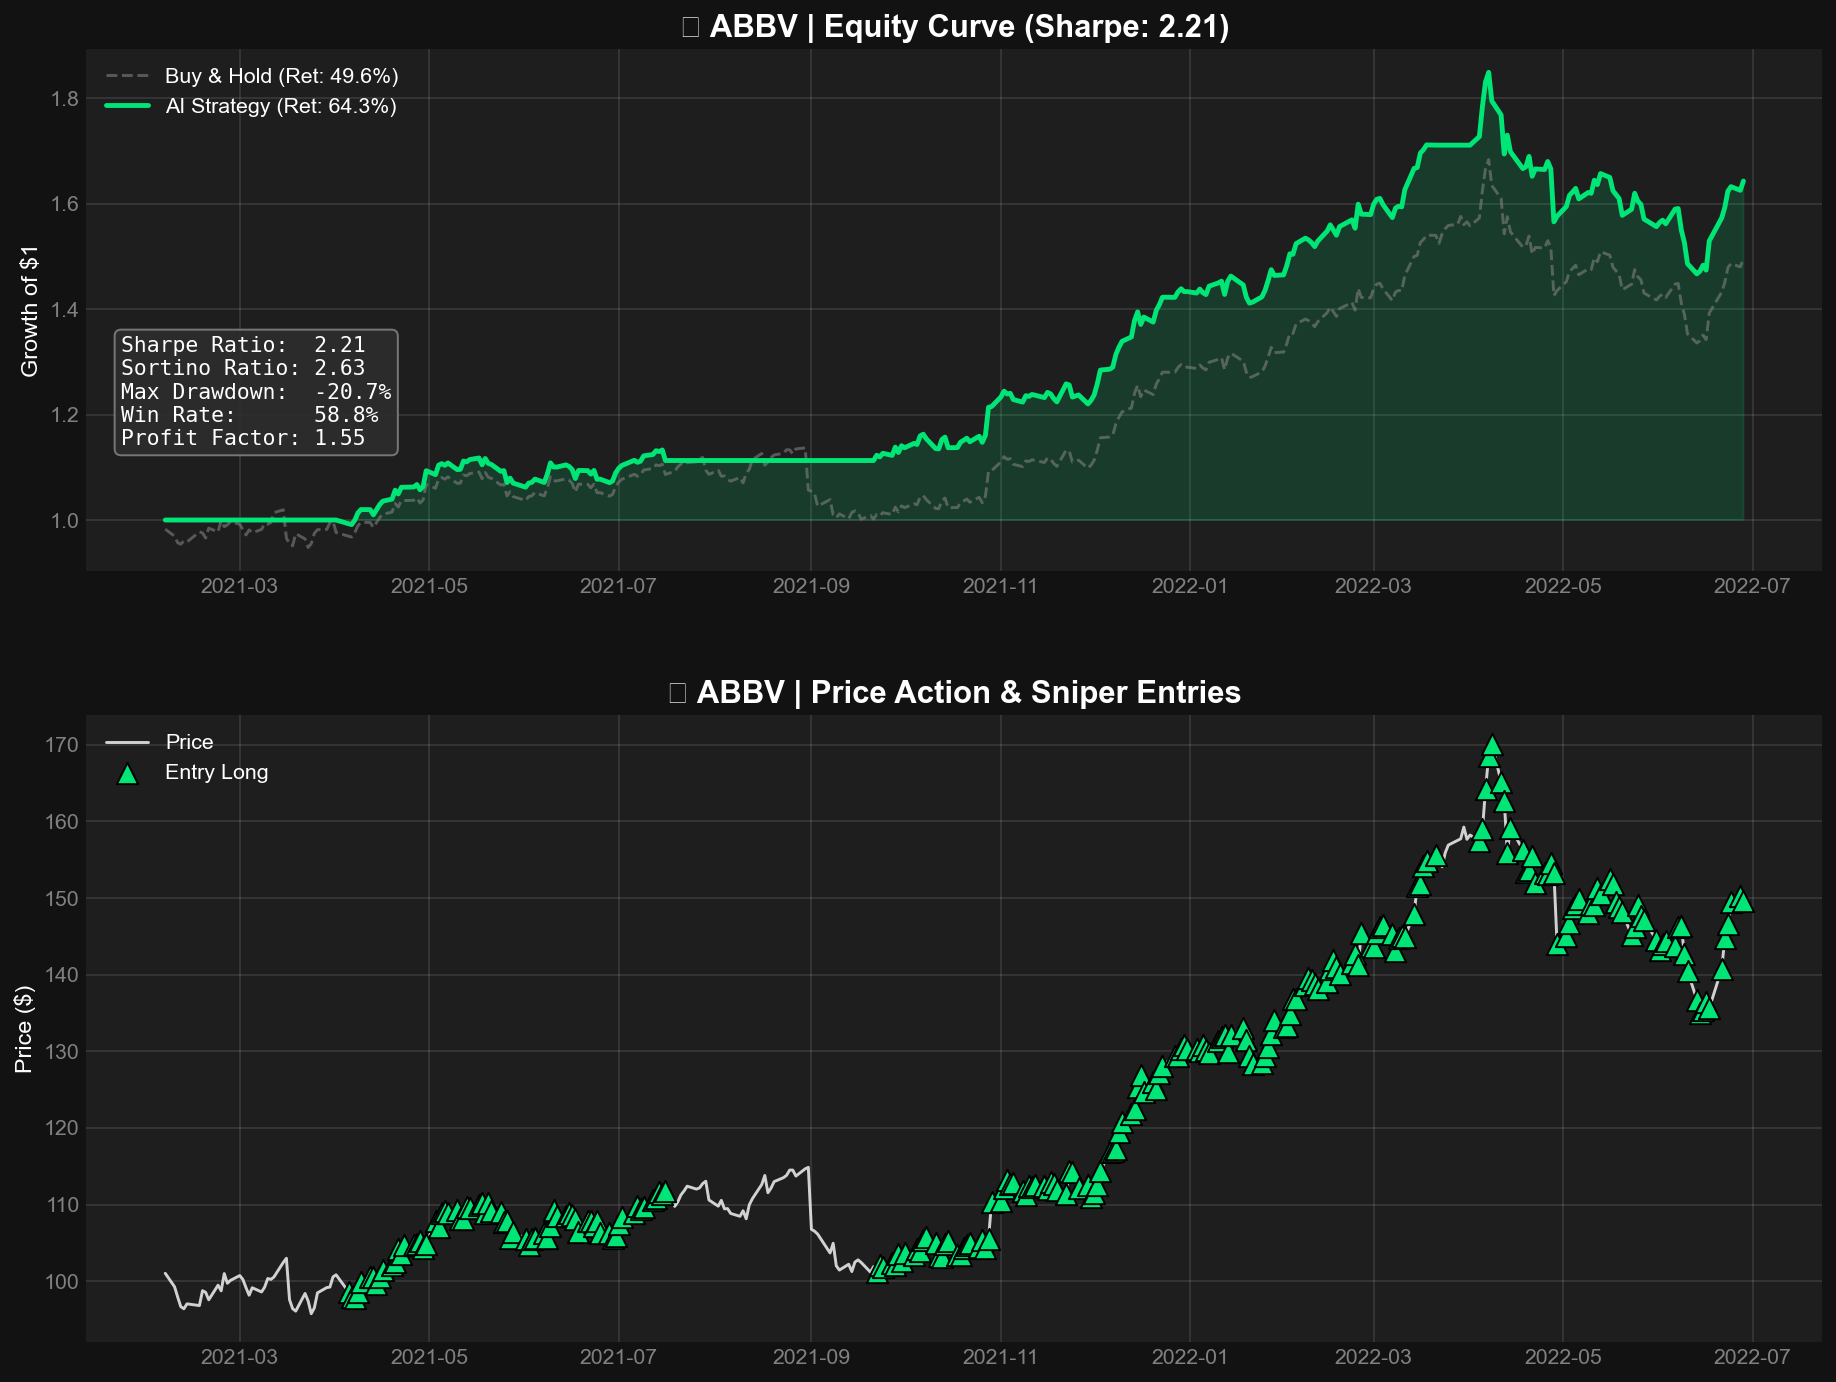

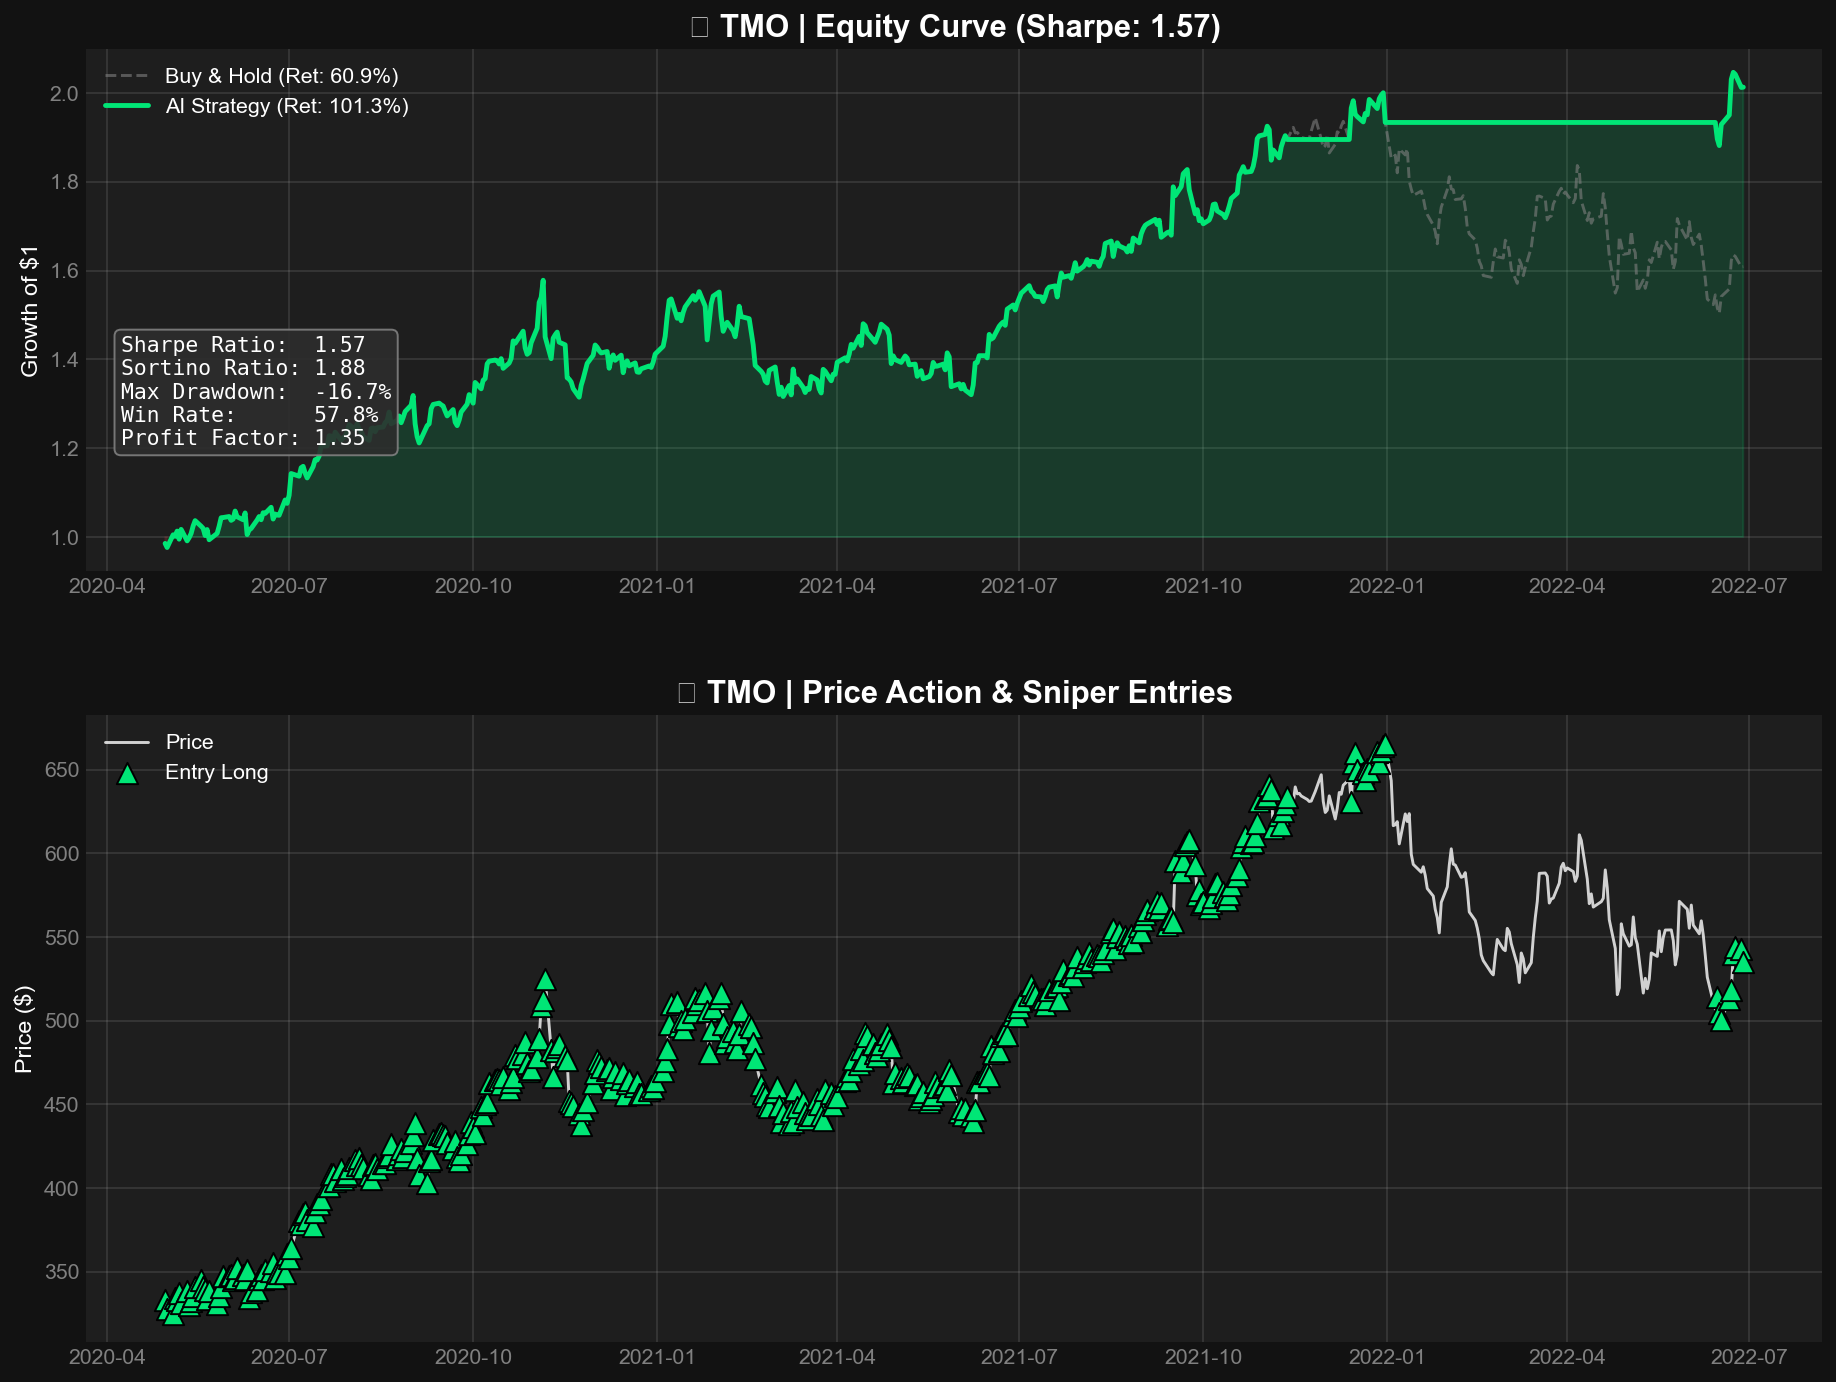

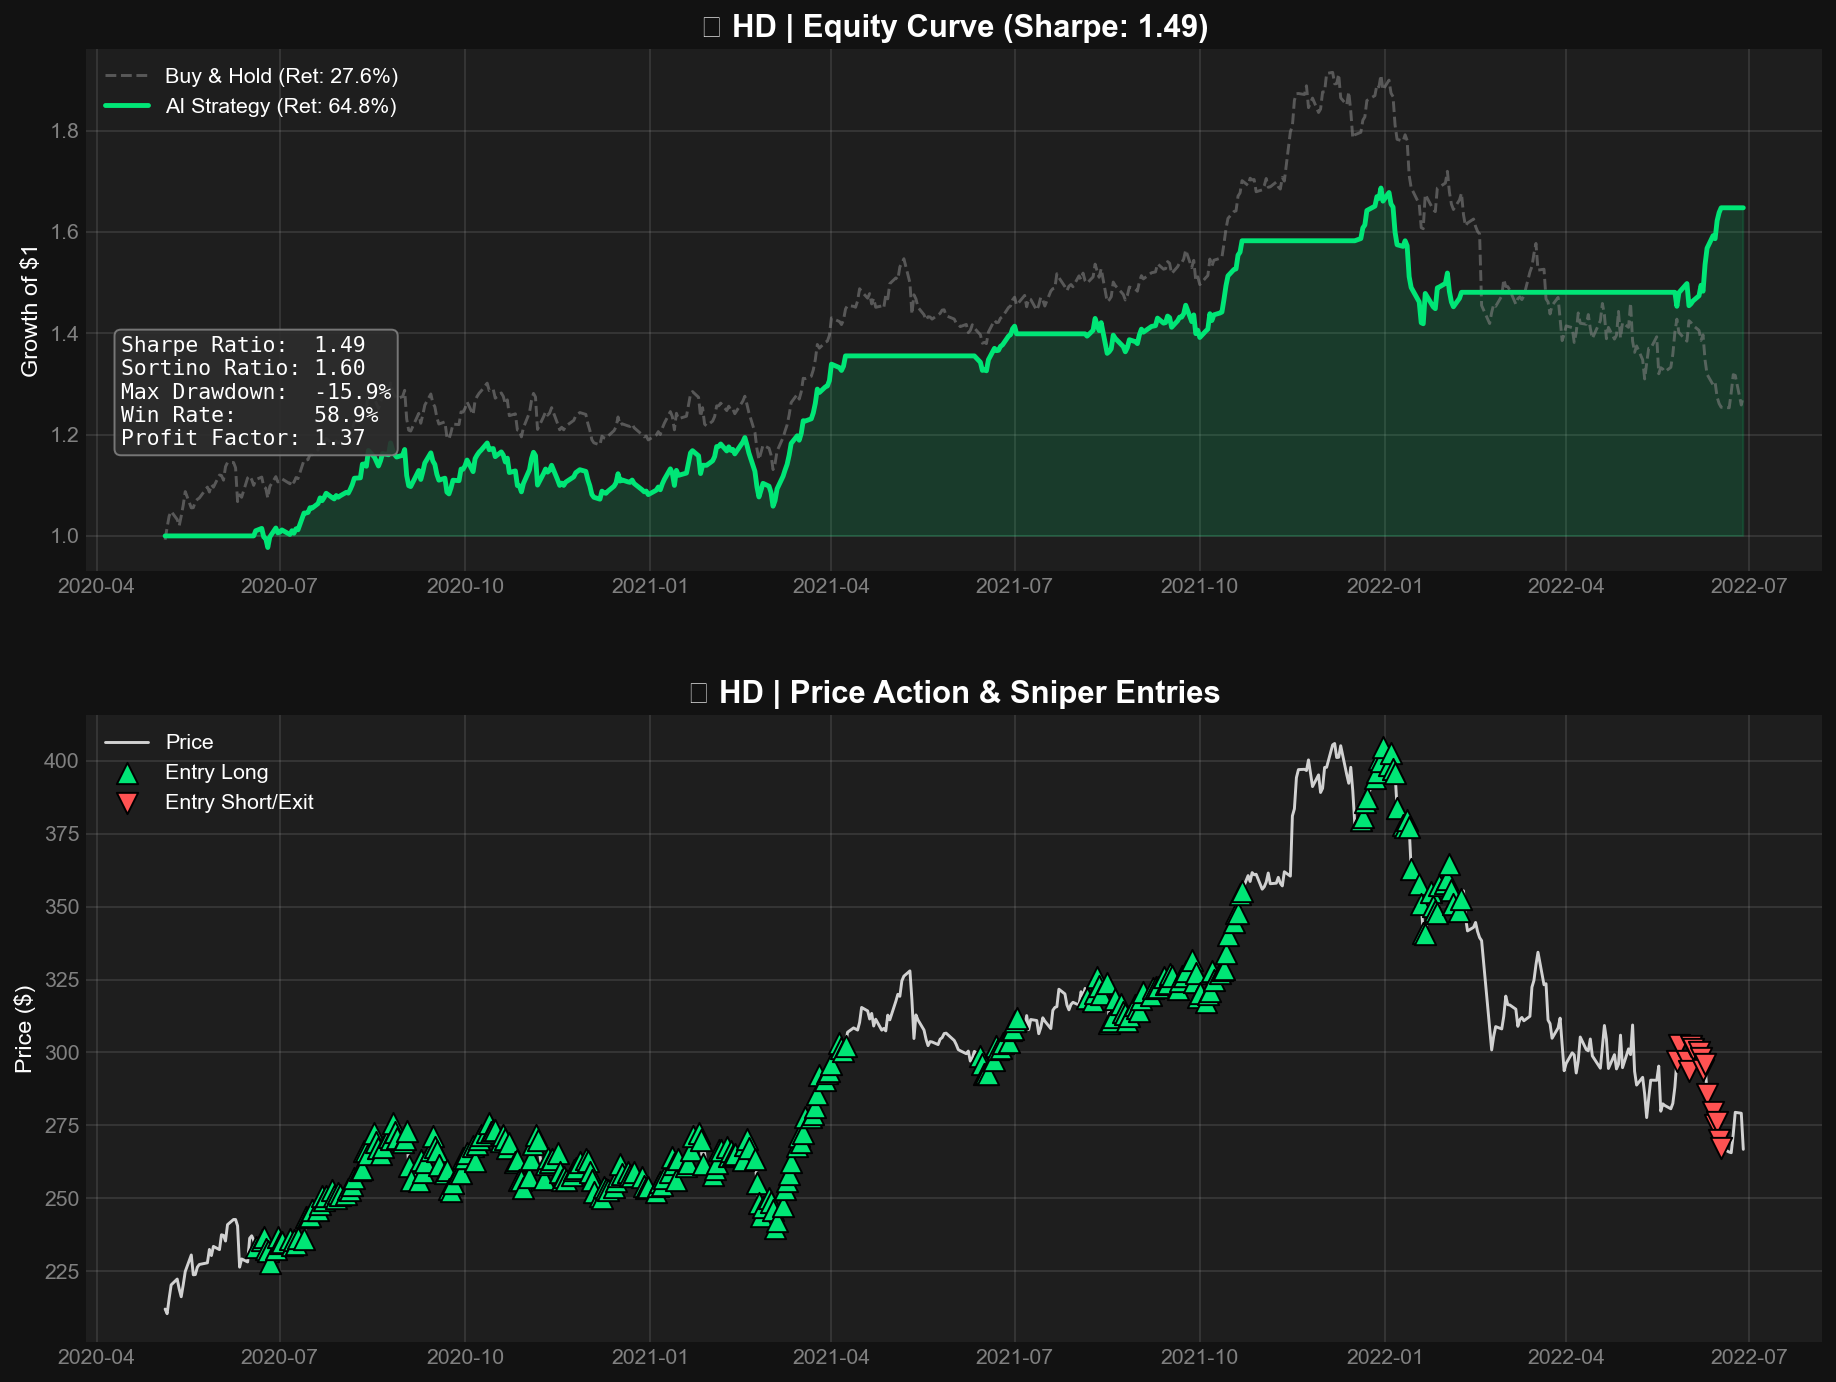

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# 🎯 MASTER CELL: ULTIMATE MARKET BENCHMARK & HD DASHBOARD
# ══════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# --- CONFIGURATION ---
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.family': 'sans-serif', 'figure.dpi': 140})

class Config:
    DATA_DIR = "US Stock Market Data/fundamentals/test"
    LOAD_DIR = "cnn_patch_models_v3"
    MODEL_NAME = "model_ep008_val53.05_hc56.21.pt"

    # Model Params
    SEQ_LEN = 30; PATCH_LEN = 6; STRIDE = 3; NORM_WINDOW = 60
    D_MODEL = 24; N_HEADS = 4; N_LAYERS = 2; DROPOUT = 0.25; D_FUSE = 48
    BATCH_SIZE = 512
    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

    # Analysis Range
    THRESHOLDS = np.arange(0.51, 0.61, 0.01)

cfg = Config()
MODEL_PATH = os.path.join(cfg.LOAD_DIR, cfg.MODEL_NAME)

# ══════════════════════════════════════════════════════════════════════════
# 1. MODEL ARCHITECTURE (Immutable)
# ══════════════════════════════════════════════════════════════════════════
class LightPatchTST(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.patch_len, self.stride = patch_len, stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.norm = nn.BatchNorm1d(n_ch)
        self.patch_proj = nn.Sequential(nn.Linear(patch_len, d_model), nn.GELU(), nn.LayerNorm(d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model*2, dropout, 'gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers)
        self.agg = nn.Sequential(nn.Linear(n_ch * d_model, d_model), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x):
        B, L, C = x.shape
        x = self.norm(x.transpose(1, 2))
        p = x.unfold(2, self.patch_len, self.stride).reshape(B * C, self.n_patches, self.patch_len)
        p = self.patch_proj(p) + self.pos_embed
        p = self.transformer(p)
        return self.agg(p.mean(dim=1).reshape(B, C * cfg.D_MODEL)) # Fixed dim match

class LightCNN(nn.Module):
    def __init__(self, n_ch, d_out, dropout):
        super().__init__()
        h = 24
        self.conv = nn.Sequential(nn.Conv1d(n_ch, h, 3, padding=1), nn.BatchNorm1d(h), nn.GELU(),
                                  nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(h, d_out); self.out_dim = d_out
    def forward(self, x): return self.proj(self.conv(x.transpose(1, 2)).mean(dim=2))

class LightGatedFusion(nn.Module):
    def __init__(self, d1, d2, d_out):
        super().__init__()
        self.proj, self.gate = nn.Linear(d1+d2, d_out), nn.Linear(d1+d2, d_out)
        self.norm = nn.LayerNorm(d_out)
    def forward(self, x1, x2):
        c = torch.cat([x1, x2], dim=-1)
        return self.norm(torch.sigmoid(self.gate(c)) * self.proj(c))

class HybridModelV3(nn.Module):
    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout, d_fuse):
        super().__init__()
        self.cnn = LightCNN(n_ch, d_fuse, dropout)
        self.tst = LightPatchTST(n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout)
        self.fusion = LightGatedFusion(self.cnn.out_dim, cfg.D_MODEL, d_fuse) # Fixed dim matching
        self.head = nn.Sequential(nn.Linear(d_fuse, d_fuse), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_fuse, 2))
        self.temperature = nn.Parameter(torch.tensor(1.5))
    def forward(self, x):
        logits = self.head(self.fusion(self.cnn(x), self.tst(x)))
        probs = F.softmax(logits / self.temperature, dim=-1)
        return logits, probs.max(dim=-1).values

# ══════════════════════════════════════════════════════════════════════════
# 2. DATA PROCESSING (Enhanced for Price Tracking)
# ══════════════════════════════════════════════════════════════════════════
def create_features(df):
    df = df.copy()
    for w in [1, 5, 10, 20]: df[f'ret_{w}'] = df['close'].pct_change(w)
    df['vol_5'] = df['ret_1'].rolling(5).std()
    # Simple formatting to ensure numerical columns only
    return df

def process_file(filepath):
    try:
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.lower().str.strip()
        if len(df) < 200: return None

        # Capture Raw Prices & Dates for Visualization
        raw_prices = df['close'].values
        dates = pd.to_datetime(df['date']).values if 'date' in df.columns else np.arange(len(df))

        # Calculate Returns for Backtest (shifted)
        # We predict at T. If Signal is Buy, we earn Return(T+1) = (Close(T+1)/Close(T)) - 1
        asset_returns = df['close'].pct_change().shift(-1).fillna(0).values

        # Feats
        df = create_features(df)
        df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

        # Safe numeric filtering
        exclude = ['date', 'close', 'target', 'open', 'high', 'low', 'volume']
        numeric_df = df.select_dtypes(include=[np.number])
        cols = [c for c in numeric_df.columns if c not in exclude]

        df = df.replace([np.inf, -np.inf], np.nan).dropna()
        feats = df[cols].values

        # Padding
        if feats.shape[1] < 45: feats = np.hstack([feats, np.zeros((len(feats), 45-feats.shape[1]))])
        feats = feats[:, :45]

        # Normalize
        norm_feats = np.zeros_like(feats)
        for i in range(len(feats)):
            s = max(0, i - cfg.NORM_WINDOW)
            wd = feats[s:i+1]
            if len(wd)>5: norm_feats[i] = (feats[i] - wd.mean(0)) / (wd.std(0) + 1e-8)
        norm_feats = np.clip(norm_feats, -5, 5)

        X, y, r, d, p = [], [], [], [], []
        start_idx = cfg.NORM_WINDOW

        for i in range(start_idx, len(norm_feats) - cfg.SEQ_LEN):
            X.append(norm_feats[i:i+cfg.SEQ_LEN])
            y.append(df['target'].iloc[i+cfg.SEQ_LEN-1])
            idx = df.index[i+cfg.SEQ_LEN-1]

            r.append(asset_returns[idx]) # Return for next day
            d.append(dates[idx])         # Date of signal
            p.append(raw_prices[idx])    # Price at signal

        return np.array(X, dtype=np.float32), np.array(r), np.array(d), np.array(p)
    except Exception as e: return None

# ══════════════════════════════════════════════════════════════════════════
# 3. METRICS ENGINE
# ══════════════════════════════════════════════════════════════════════════
def calculate_pro_metrics(returns):
    if len(returns) < 2: return {}
    cum_ret = (1 + returns).cumprod()
    mean_ret, std_ret = returns.mean(), returns.std() + 1e-9

    sharpe = (mean_ret / std_ret) * np.sqrt(252)
    downside = returns[returns < 0].std() + 1e-9
    sortino = (mean_ret / downside) * np.sqrt(252)

    cum_max = cum_ret.cummax()
    drawdown = (cum_ret - cum_max) / cum_max

    wins = returns[returns > 0].sum()
    losses = abs(returns[returns < 0].sum())
    pf = wins / losses if losses > 0 else 0

    return {
        'Total Return': cum_ret.iloc[-1] - 1,
        'Sharpe': sharpe, 'Sortino': sortino, 'MaxDD': drawdown.min(),
        'Profit Factor': pf, 'Equity Curve': cum_ret
    }

# ══════════════════════════════════════════════════════════════════════════
# 4. DASHBOARD VISUALIZATION (HD)
# ══════════════════════════════════════════════════════════════════════════
def plot_hd_dashboard(ticker, row):
    dates = row['Dates']
    prices = row['Prices']
    signals = row['Signals'] # 1, -1, 0
    equity = row['EquityCurve']
    benchmark = row['BenchCurve']

    # Setup Grid
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2], hspace=0.25)

    # --- CHART 1: FINANCIAL PERFORMANCE (Growth of $1) ---
    ax1 = fig.add_subplot(gs[0])

    # Plot Benchmark
    ax1.plot(dates, benchmark, color='gray', linestyle='--', linewidth=1.5, alpha=0.6,
             label=f'Buy & Hold (Ret: {benchmark[-1]-1:.1%})')

    # Plot Strategy
    color_eq = '#00e676' if equity[-1] >= 1 else '#ff5252'
    ax1.plot(dates, equity, color=color_eq, linewidth=2.5,
             label=f'AI Strategy (Ret: {row["TotalReturn"]:.1%})')

    # Areas
    ax1.fill_between(dates, equity, 1, where=(equity>=1), color=color_eq, alpha=0.15)
    ax1.fill_between(dates, equity, 1, where=(equity<1), color='#ff5252', alpha=0.1)

    ax1.set_title(f"💰 {ticker} | Equity Curve (Sharpe: {row['Sharpe']:.2f})", fontsize=16, fontweight='bold', color='white')
    ax1.set_ylabel("Growth of $1", fontsize=12, color='white')
    ax1.legend(loc='upper left', framealpha=0.9, facecolor='#2d2d2d', labelcolor='white')
    ax1.tick_params(colors='gray')
    ax1.grid(True, alpha=0.1)
    ax1.set_facecolor('#1e1e1e')

    # Metrics Text Box
    stats = (
        f"Sharpe Ratio:  {row['Sharpe']:.2f}\n"
        f"Sortino Ratio: {row['Sortino']:.2f}\n"
        f"Max Drawdown:  {row['MaxDD']:.1%}\n"
        f"Win Rate:      {row['WinRate']:.1f}%\n"
        f"Profit Factor: {row['ProfitFactor']:.2f}"
    )
    props = dict(boxstyle='round', facecolor='#2d2d2d', alpha=0.9, edgecolor='gray')
    ax1.text(0.02, 0.45, stats, transform=ax1.transAxes, fontsize=11,
             verticalalignment='top', bbox=props, color='white', fontfamily='monospace')

    # --- CHART 2: PRICE ACTION & SIGNALS ---
    ax2 = fig.add_subplot(gs[1])

    # Price Line
    ax2.plot(dates, prices, color='white', linewidth=1.5, alpha=0.8, label='Price')

    # Signal Markers
    # Signals: 1 = Long, -1 = Short (or Exit), 0 = Cash
    buy_mask = (signals == 1)
    # Assuming -1 is Short or Exit. If just exit, color orange. If short, color red.
    sell_mask = (signals == -1)

    if np.any(buy_mask):
        ax2.scatter(dates[buy_mask], prices[buy_mask], marker='^', color='#00e676', s=120,
                    edgecolor='black', zorder=5, label='Entry Long')

    if np.any(sell_mask):
        ax2.scatter(dates[sell_mask], prices[sell_mask], marker='v', color='#ff5252', s=120,
                    edgecolor='black', zorder=5, label='Entry Short/Exit')

    ax2.set_title(f"📈 {ticker} | Price Action & Sniper Entries", fontsize=16, fontweight='bold', color='white')
    ax2.set_ylabel("Price ($)", fontsize=12, color='white')
    ax2.legend(loc='upper left', framealpha=0.9, facecolor='#2d2d2d', labelcolor='white')
    ax2.tick_params(colors='gray')
    ax2.grid(True, alpha=0.1)
    ax2.set_facecolor('#1e1e1e')

    # Final Config
    fig.patch.set_facecolor('#121212') # Dark background for whole figure
    plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 5. EXECUTION ENGINE
# ══════════════════════════════════════════════════════════════════════════
def run_full_pipeline():
    print(f"🧠 Loading Model: {cfg.MODEL_NAME}...")
    model = HybridModelV3(45, cfg.SEQ_LEN, cfg.PATCH_LEN, cfg.STRIDE, cfg.D_MODEL, cfg.N_HEADS, cfg.N_LAYERS, cfg.DROPOUT, cfg.D_FUSE).to(cfg.DEVICE)
    try:
        ckpt = torch.load(MODEL_PATH, map_location=cfg.DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
    except Exception as e: return print(f"❌ Load Error: {e}")

    files = [f for f in os.listdir(cfg.DATA_DIR) if f.endswith('fundamentals_test.csv')]
    print(f"📂 Scanning {len(files)} tickers...")

    results_db = []

    for filename in files:
        ticker = filename.replace('_fundamentals_test.csv', '')
        filepath = os.path.join(cfg.DATA_DIR, filename)

        # 1. Get Data (with Prices!)
        data = process_file(filepath)
        if data is None: continue
        X, returns_daily, dates, prices = data
        if len(X) < 50: continue

        # 2. Inference
        dataset = TensorDataset(torch.FloatTensor(X))
        loader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
        preds_all, conf_all = [], []
        with torch.no_grad():
            for bx in loader:
                logits, conf = model(bx[0].to(cfg.DEVICE))
                preds_all.extend(logits.argmax(1).cpu().numpy())
                conf_all.extend(conf.cpu().numpy())
        preds_all, conf_all = np.array(preds_all), np.array(conf_all)

        # 3. Iterate Thresholds
        for thr in cfg.THRESHOLDS:
            mask = conf_all > thr
            if mask.sum() < 5: continue # Skip noise

            # Strategy: 1=Long, -1=Short, 0=Cash
            # Original Model: Pred 1 = Up, Pred 0 = Down
            # Mapping: Pred 1 -> 1, Pred 0 -> -1
            position = np.where(preds_all == 1, 1, -1)
            active_position = position * mask.astype(int)

            # Returns
            strat_ret = pd.Series(active_position * returns_daily)
            bench_ret = pd.Series(returns_daily)

            metrics = calculate_pro_metrics(strat_ret)
            bench_metrics = calculate_pro_metrics(bench_ret)
            if not metrics: continue

            results_db.append({
                'Ticker': ticker,
                'Threshold': float(thr),
                'Sharpe': metrics['Sharpe'],
                'Sortino': metrics['Sortino'],
                'MaxDD': metrics['MaxDD'],
                'TotalReturn': metrics['Total Return'],
                'ProfitFactor': metrics['Profit Factor'],
                'WinRate': (strat_ret[mask] > 0).mean() * 100,

                # Arrays for Plotting
                'EquityCurve': metrics['Equity Curve'].values,
                'BenchCurve': bench_metrics['Equity Curve'].values,
                'Dates': dates,
                'Prices': prices,
                'Signals': active_position
            })

    # 4. Global Analysis
    df = pd.DataFrame(results_db)
    if df.empty: return print("❌ No trades found.")

    stats = df.groupby('Threshold')[['Sharpe']].mean()
    best_thr = stats['Sharpe'].idxmax()
    print(f"\n🏆 GLOBAL OPTIMAL THRESHOLD: {best_thr:.2f}")

    # 5. Visualize Top 3 Performers at Best Threshold
    subset = df[df['Threshold'] == best_thr]
    top_3 = subset.sort_values('Sharpe', ascending=False).head(3)

    print(f"\n💎 TOP 3 PERFORMERS (TEAR SHEET):")
    print(top_3[['Ticker', 'Sharpe', 'TotalReturn', 'WinRate']].to_string(index=False))

    for _, row in top_3.iterrows():
        plot_hd_dashboard(row['Ticker'], row)

if __name__ == "__main__":
    run_full_pipeline()